# Leipzig ECG Q1 V5.5 Gen-Only One-Seed Paper T4

Prospective generator-only protocol.  The discriminator is training-only and
is neither released nor queried during CFE search.  All methods use paired
base seeds and paired robustness perturbations.  The HE-aware deployment
population is frozen before outer evaluation; missing K slots remain failures.

In [1]:
import subprocess, sys, time, torch
NOTEBOOK_STARTED = time.perf_counter()
RUN_MODE = "paper"
DATASET = "ecg"
if not torch.cuda.is_available() or "T4" not in torch.cuda.get_device_name(0):
    raise RuntimeError("Leipzig ECG Q1 V2 paper training requires Kaggle Tesla T4")
gpu_name = torch.cuda.get_device_name(0)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "opacus==1.6.0", "dice-ml==0.12"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/meta-pytorch/csprng.git@13e04cd"])
import torchcsprng
from opacus import PrivacyEngine
_secure_probe = PrivacyEngine(accountant="rdp", secure_mode=True)
if _secure_probe.secure_rng is None:
    raise RuntimeError("Opacus secure RNG initialization failed")
TORCHCSPRNG_VERSION = getattr(torchcsprng, "__version__", "unknown")
del _secure_probe
print({"protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER", "stage": RUN_MODE, "gpu": gpu_name, "torch": torch.__version__, "torchcsprng": TORCHCSPRNG_VERSION, "secure_rng": True})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.0 MB/s eta 0:00:00


{'protocol': 'Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER', 'stage': 'paper', 'gpu': 'Tesla T4', 'torch': '2.10.0+cu128', 'torchcsprng': '0.3.0a0+13e04cd', 'secure_rng': True}


## Frozen pipeline source

In [2]:
%%writefile /kaggle/working/plaintext_cfe_pipeline.py
"""Self-contained plaintext classifier, CounterGAN and bidirectional CFE pipeline.

This module is embedded verbatim into the generated Kaggle notebooks.  It is
therefore intentionally independent of the local package layout.  The outer
test set is evaluation-only; all preprocessing, stopping, thresholds, GAN
selection and CFE search calibration use outer-development data.
"""

from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    fbeta_score,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset


BASE_SEED = 42
ECG_META = [
    "subject_id", "record_id", "cohort", "diagnosis", "beat_sample",
    "beat_symbol", "beat_aux",
]
TARGETS = {
    "ecg": "Target_Abnormal",
    "heartplus": "HeartDisease",
    "mimic": "Target_Mortality",
}
CLASSIFIER_CONFIGS = {
    "ecg": dict(h1=160, h2=80, activation_kind="poly", alpha=0.125,
                loss="natural_bce", dropout=0.05, expected_inputs=20),
    "heartplus": dict(h1=128, h2=64, activation_kind="square", alpha=0.0,
                      loss="sqrt_weighted_bce", dropout=0.05,
                      expected_inputs=23),
    "mimic": dict(h1=128, h2=64, activation_kind="square", alpha=0.0,
                  loss="sqrt_weighted_bce", dropout=0.05,
                  expected_inputs=40),
}
DATA_FILENAMES = {
    "ecg": "ecg_beats_features_selected_20.csv",
    "heartplus": "merged_data.csv",
    "mimic": "mimic_icu_mortality_cfe_12671.csv",
}
DATASET_SLUGS = {
    "ecg": "heart-ecg",
    "heartplus": "heart-max",
    "mimic": "mimiciv-full",
}
PAPER_CLASSIFIER_SEEDS = [11, 22, 33]
AGE_LEVELS = [
    "18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54",
    "55-59", "60-64", "65-69", "70-74", "75-79", "80+",
]
GENHEALTH_LEVELS = ["Excellent", "Very good", "Good", "Fair", "Poor"]
DIABETIC_LEVELS = ["No", "Prediabetes", "Pregnancy only", "Yes"]
RACE_LEVELS = [
    "White", "Black", "Hispanic", "Asian",
    "American Indian/Alaskan Native", "Multiracial", "Other",
]
SMOKING_LEVELS = ["Never", "Former", "Current"]
HEARTPLUS_FEATURES = [
    "Sex", "GenHealth", "PhysicalHealth", "MentalHealth",
    "PhysicalActivity", "SleepTime", "Stroke", "Asthma", "SkinCancer",
    "Diabetic", "BMI", "AlcoholDrinking", "Race", "AgeCategory",
    "KidneyDisease", "Smoking", "DiffWalking",
]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def resolve_input(dataset: str, root: str | Path = "/kaggle/input") -> Path:
    root = Path(root)
    expected = DATA_FILENAMES[dataset]
    preferred = root / DATASET_SLUGS[dataset] / expected
    if preferred.exists():
        return preferred
    matches = sorted(root.rglob(expected))
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {expected!r} below {root}, got {matches}"
        )
    return matches[0]


def _yn(value: object) -> str:
    if pd.isna(value):
        return "Missing"
    text = str(value).strip().lower()
    return "Yes" if text == "yes" else "No" if text == "no" else "Missing"


def normalize_heartplus(raw: pd.DataFrame) -> pd.DataFrame:
    needed = set(HEARTPLUS_FEATURES + ["HeartDisease"])
    missing = sorted(needed - set(raw.columns))
    if missing:
        raise ValueError(f"Heart+ missing columns: {missing}")
    out = raw[HEARTPLUS_FEATURES + ["HeartDisease"]].copy()
    for column in (
        "PhysicalActivity", "Stroke", "Asthma", "SkinCancer",
        "AlcoholDrinking", "KidneyDisease", "DiffWalking",
    ):
        out[column] = out[column].map(_yn)
    out["Sex"] = out["Sex"].where(out["Sex"].isin(["Female", "Male"]), "Missing")
    out["GenHealth"] = out["GenHealth"].where(
        out["GenHealth"].isin(GENHEALTH_LEVELS), "Missing"
    )

    def age(value: object) -> str:
        if pd.isna(value):
            return "Missing"
        text = (str(value).strip().lower().replace("age ", "")
                .replace(" to ", "-").replace(" or older", "+"))
        return text if text in AGE_LEVELS else "Missing"

    race_map = {
        "White only, Non-Hispanic": "White", "White": "White",
        "Black only, Non-Hispanic": "Black", "Black": "Black",
        "Hispanic": "Hispanic", "Asian": "Asian",
        "American Indian/Alaskan Native": "American Indian/Alaskan Native",
        "Multiracial, Non-Hispanic": "Multiracial",
        "Other race only, Non-Hispanic": "Other", "Other": "Other",
    }
    out["AgeCategory"] = out["AgeCategory"].map(age)
    out["Race"] = out["Race"].map(
        lambda value: "Other" if pd.isna(value)
        else race_map.get(str(value).strip(), "Other")
    )

    def diabetic(value: object) -> str:
        if pd.isna(value):
            return "Missing"
        text = str(value).strip()
        if text == "No":
            return "No"
        if "pre-diabetes" in text or "borderline" in text:
            return "Prediabetes"
        if "pregnancy" in text:
            return "Pregnancy only"
        return "Yes" if text == "Yes" else "Missing"

    def smoking(value: object) -> str:
        if pd.isna(value):
            return "Missing"
        text = str(value).strip()
        if text in {"No", "Never smoked"}:
            return "Never"
        if text == "Former smoker":
            return "Former"
        if text in {
            "Yes", "Current smoker - now smokes every day",
            "Current smoker - now smokes some days",
        }:
            return "Current"
        return "Missing"

    out["Diabetic"] = out["Diabetic"].map(diabetic)
    out["Smoking"] = out["Smoking"].map(smoking)
    out["HeartDisease"] = out["HeartDisease"].map(_yn)
    for column in ("PhysicalHealth", "MentalHealth", "SleepTime", "BMI"):
        out[column] = pd.to_numeric(out[column], errors="coerce")
    out = out[out["HeartDisease"].isin(["No", "Yes"])].reset_index(drop=True)
    out["HeartDisease"] = (out["HeartDisease"] == "Yes").astype(np.int8)
    return out


@dataclass
class RawDataset:
    name: str
    frame: pd.DataFrame
    feature_cols: list[str]
    target_col: str
    categorical_cols: list[str]
    groups: np.ndarray | None
    split_kind: str
    source_path: str
    source_rows: int
    dropped_rows: int


def load_dataset(dataset: str, path: str | Path) -> RawDataset:
    path = Path(path)
    raw = pd.read_csv(path)
    if dataset == "heartplus":
        frame = normalize_heartplus(raw)
        groups = pd.util.hash_pandas_object(
            frame[HEARTPLUS_FEATURES], index=False
        ).to_numpy(np.uint64)
        return RawDataset(dataset, frame, HEARTPLUS_FEATURES, "HeartDisease",
                          [], groups, "exact-feature-group-disjoint", str(path),
                          source_rows=int(len(raw)), dropped_rows=int(len(raw) - len(frame)))
    if dataset == "ecg":
        target = TARGETS[dataset]
        required = set(ECG_META + [target, "age", "gender"])
        missing = sorted(required - set(raw.columns))
        if missing:
            raise ValueError(f"Corrected ECG input missing: {missing}")
        if len(raw) != 113_846 or raw["subject_id"].nunique() != 39:
            raise ValueError("Wrong ECG version: expected 113,846 rows and 39 subjects")
        if raw.duplicated(["record_id", "beat_sample"]).any():
            raise ValueError("ECG has duplicate (record_id, beat_sample) rows")
        features = [c for c in raw.columns if c not in ECG_META + [target]]
        return RawDataset(dataset, raw, features, target, ["gender"],
                          raw["subject_id"].to_numpy(), "subject-disjoint", str(path),
                          source_rows=int(len(raw)), dropped_rows=0)
    if dataset == "mimic":
        target = TARGETS[dataset]
        if target not in raw:
            raise ValueError(f"MIMIC missing {target}")
        source_rows = int(len(raw))
        raw = raw.dropna().reset_index(drop=True)
        raw[target] = raw[target].astype(np.int8)
        features = [c for c in raw.columns if c != target]
        categorical = [c for c in ("gender", "race_group") if c in features]
        return RawDataset(dataset, raw, features, target, categorical, None,
                          "stratified-row-no-patient-id", str(path),
                          source_rows=source_rows,
                          dropped_rows=int(source_rows - len(raw)))
    raise ValueError(dataset)


def best_group_split(y: np.ndarray, groups: np.ndarray, test_size: float,
                     seed: int, n_candidates: int = 512):
    splitter = GroupShuffleSplit(n_splits=n_candidates, test_size=test_size,
                                 random_state=seed)
    target_rate = float(np.mean(y))
    best = None
    for number, (left, right) in enumerate(splitter.split(y, y, groups)):
        if len(np.unique(y[left])) < 2 or len(np.unique(y[right])) < 2:
            continue
        score = (4 * abs(float(y[right].mean()) - target_rate)
                 + abs(len(right) / len(y) - test_size)
                 + .25 * abs(len(np.unique(groups[right]))
                             / len(np.unique(groups)) - test_size))
        if best is None or score < best[0]:
            best = (score, number, left, right)
    if best is None:
        raise ValueError("No group-disjoint split with both classes")
    return best[2], best[3], {"candidate": int(best[1]), "score": float(best[0])}


@dataclass
class SplitBundle:
    train_idx: np.ndarray
    valid_idx: np.ndarray
    test_idx: np.ndarray
    audit: dict[str, Any]


def make_splits(data: RawDataset, smoke: bool = False) -> SplitBundle:
    y = data.frame[data.target_col].to_numpy(np.int8)
    indices = np.arange(len(y))
    if data.groups is not None:
        dev, test, outer_audit = best_group_split(y, data.groups, .20, 42)
        # ECG has only 31 development subjects. Paper v1's 10% inner holdout
        # contained four subjects and produced an unstable decision threshold.
        # Match the original architecture-tuning protocol and reserve 20% of
        # development subjects for epoch/threshold selection.
        train_local, valid_local, inner_audit = best_group_split(
            y[dev], data.groups[dev], .20, 819, 64
        )
        train, valid = dev[train_local], dev[valid_local]
        assert not set(data.groups[dev]).intersection(set(data.groups[test]))
    else:
        dev, test = train_test_split(indices, test_size=.20, random_state=42,
                                     stratify=y)
        train, valid = train_test_split(dev, test_size=.10, random_state=819,
                                        stratify=y[dev])
        outer_audit, inner_audit = {"seed": 42}, {"seed": 819}

    def cap(ix: np.ndarray, n: int, seed: int) -> np.ndarray:
        if not smoke or len(ix) <= n:
            return np.asarray(ix)
        keep, _ = train_test_split(ix, train_size=n, random_state=seed,
                                   stratify=y[ix])
        return np.asarray(sorted(keep))

    train = cap(train, 20_000, 101)
    valid = cap(valid, 4_000, 102)
    test = cap(test, 4_000, 103)
    audit = {
        "kind": data.split_kind,
        "outer": outer_audit,
        "inner": inner_audit,
        "smoke_row_cap": bool(smoke),
        "train_rows": int(len(train)), "valid_rows": int(len(valid)),
        "test_rows": int(len(test)),
        "train_positive_rate": float(y[train].mean()),
        "valid_positive_rate": float(y[valid].mean()),
        "test_positive_rate": float(y[test].mean()),
    }
    return SplitBundle(train, valid, test, audit)


class GenericPreprocessor:
    def __init__(self, feature_cols: list[str], categorical_cols: list[str]):
        self.feature_cols = list(feature_cols)
        self.categorical_cols = list(categorical_cols)
        self.numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    def fit(self, frame: pd.DataFrame):
        self.numeric_medians = {
            c: float(pd.to_numeric(frame[c], errors="coerce").median())
            for c in self.numeric_cols
        }
        numbers = self._numbers(frame)
        self.qt = QuantileTransformer(
            n_quantiles=min(1000, len(numbers)), output_distribution="normal",
            random_state=42, subsample=min(200_000, len(numbers)),
        ).fit(numbers)
        if self.categorical_cols:
            categories = [
                sorted(frame[c].astype("string").fillna("Missing").astype(str).unique())
                for c in self.categorical_cols
            ]
            self.ohe = OneHotEncoder(categories=categories, drop="first",
                                     handle_unknown="ignore", sparse_output=False,
                                     dtype=np.float32).fit(self._categories(frame))
            encoded = list(self.ohe.get_feature_names_out(self.categorical_cols))
        else:
            self.ohe, encoded = None, []
        self.feature_names = self.numeric_cols + encoded
        return self

    def _numbers(self, frame: pd.DataFrame) -> pd.DataFrame:
        return pd.DataFrame({
            c: pd.to_numeric(frame[c], errors="coerce").fillna(self.numeric_medians[c])
            for c in self.numeric_cols
        }, index=frame.index)

    def _categories(self, frame: pd.DataFrame) -> pd.DataFrame:
        return pd.DataFrame({
            c: frame[c].astype("string").fillna("Missing").astype(str)
            for c in self.categorical_cols
        }, index=frame.index)

    def transform(self, frame: pd.DataFrame) -> np.ndarray:
        numbers = np.clip(self.qt.transform(self._numbers(frame)), -5, 5)
        if self.ohe is None:
            return numbers.astype(np.float32)
        return np.hstack([numbers, self.ohe.transform(self._categories(frame))]).astype(np.float32)

    def inverse(self, values: np.ndarray) -> pd.DataFrame:
        values = np.asarray(values)
        n_num = len(self.numeric_cols)
        encoded_numbers = pd.DataFrame(
            np.clip(values[:, :n_num], -5, 5), columns=self.numeric_cols
        )
        numbers = self.qt.inverse_transform(encoded_numbers)
        out = pd.DataFrame(numbers, columns=self.numeric_cols)
        if self.ohe is not None:
            cats = self.ohe.inverse_transform(values[:, n_num:])
            for i, c in enumerate(self.categorical_cols):
                out[c] = cats[:, i]
        return out[self.feature_cols]


class HeartPlusPreprocessor:
    numeric = ["PhysicalHealth", "MentalHealth", "SleepTime", "BMI"]
    ordinal = ["GenHealth", "AgeCategory", "Diabetic", "Smoking"]
    binary = [
        "Sex", "PhysicalActivity", "Stroke", "Asthma", "SkinCancer",
        "AlcoholDrinking", "KidneyDisease", "DiffWalking",
    ]
    ordinal_levels = {
        "GenHealth": GENHEALTH_LEVELS, "AgeCategory": AGE_LEVELS,
        "Diabetic": DIABETIC_LEVELS, "Smoking": SMOKING_LEVELS,
    }
    binary_levels = {
        "Sex": ["Female", "Male"], "PhysicalActivity": ["No", "Yes"],
        "Stroke": ["No", "Yes"], "Asthma": ["No", "Yes"],
        "SkinCancer": ["No", "Yes"], "AlcoholDrinking": ["No", "Yes"],
        "KidneyDisease": ["No", "Yes"], "DiffWalking": ["No", "Yes"],
    }

    def fit(self, frame: pd.DataFrame):
        self.numeric_medians = {
            c: float(pd.to_numeric(frame[c], errors="coerce").median())
            for c in self.numeric
        }
        self.category_modes = {}
        for c in self.ordinal + self.binary + ["Race"]:
            values = frame.loc[frame[c].astype(str) != "Missing", c].dropna()
            levels = self.ordinal_levels.get(c) or self.binary_levels.get(c) or RACE_LEVELS
            self.category_modes[c] = str(values.mode().iloc[0]) if len(values) else levels[0]
        clean = self._clean(frame)
        self.qt = QuantileTransformer(
            n_quantiles=min(1000, len(clean)), output_distribution="normal",
            random_state=42, subsample=min(200_000, len(clean)),
        ).fit(clean[self.numeric])
        self.ohe = OneHotEncoder(categories=[RACE_LEVELS], handle_unknown="ignore",
                                 sparse_output=False, dtype=np.float32).fit(clean[["Race"]])
        self.feature_names = (self.numeric + self.ordinal + self.binary
                              + list(self.ohe.get_feature_names_out(["Race"])))
        return self

    def _clean(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame[HEARTPLUS_FEATURES].copy()
        for c in self.numeric:
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(self.numeric_medians[c])
        for c in self.ordinal + self.binary + ["Race"]:
            out[c] = out[c].astype("string").fillna("Missing")
            out.loc[out[c] == "Missing", c] = self.category_modes[c]
        return out

    @staticmethod
    def _scale(values: Iterable, levels: list[str]) -> np.ndarray:
        mapping = {v: i for i, v in enumerate(levels)}
        idx = np.asarray([mapping.get(str(v), 0) for v in values], np.float32)
        return 2 * idx / max(len(levels) - 1, 1) - 1

    def transform(self, frame: pd.DataFrame) -> np.ndarray:
        clean = self._clean(frame)
        parts = [np.clip(self.qt.transform(clean[self.numeric]), -5, 5).astype(np.float32)]
        for c in self.ordinal:
            parts.append(self._scale(clean[c], self.ordinal_levels[c])[:, None])
        for c in self.binary:
            levels = self.binary_levels[c]
            parts.append(clean[c].map({levels[0]: 0., levels[1]: 1.})
                         .fillna(0).to_numpy(np.float32)[:, None])
        parts.append(self.ohe.transform(clean[["Race"]]).astype(np.float32))
        return np.hstack(parts).astype(np.float32)

    @staticmethod
    def _unscale(values: np.ndarray, levels: list[str]) -> list[str]:
        idx = np.rint((np.clip(values, -1, 1) + 1) * (len(levels) - 1) / 2).astype(int)
        return [levels[i] for i in idx]

    def inverse(self, values: np.ndarray) -> pd.DataFrame:
        values = np.asarray(values)
        encoded_numbers = pd.DataFrame(
            np.clip(values[:, :4], -5, 5), columns=self.numeric
        )
        out = pd.DataFrame(self.qt.inverse_transform(encoded_numbers),
                           columns=self.numeric)
        pos = 4
        for c in self.ordinal:
            out[c] = self._unscale(values[:, pos], self.ordinal_levels[c]); pos += 1
        for c in self.binary:
            levels = self.binary_levels[c]
            out[c] = np.where(values[:, pos] >= .5, levels[1], levels[0]); pos += 1
        race = self.ohe.inverse_transform(values[:, pos:pos + len(RACE_LEVELS)])[:, 0]
        out["Race"] = race
        return out[HEARTPLUS_FEATURES]


@dataclass
class PreparedData:
    raw: RawDataset
    split: SplitBundle
    preprocessor: Any
    x_train: np.ndarray
    y_train: np.ndarray
    x_valid: np.ndarray
    y_valid: np.ndarray
    x_test: np.ndarray
    y_test: np.ndarray
    feature_names: list[str]


def dataset_accounting_table(prepared: PreparedData) -> pd.DataFrame:
    """Reconcile CSV rows, usable rows, labels, raw predictors and HE inputs."""
    raw = prepared.raw
    counts = raw.frame[raw.target_col].value_counts().sort_index()
    return pd.DataFrame([{
        "dataset": raw.name,
        "source_csv_rows": int(raw.source_rows),
        "usable_model_rows": int(len(raw.frame)),
        "dropped_rows": int(raw.dropped_rows),
        "class_0": int(counts.get(0, 0)),
        "class_1": int(counts.get(1, 0)),
        "class_count_sum": int(counts.sum()),
        "counts_match_usable_rows": bool(int(counts.sum()) == len(raw.frame)),
        "raw_predictors": int(len(raw.feature_cols)),
        "processed_he_inputs": int(len(prepared.feature_names)),
        "split_kind": raw.split_kind,
    }])


def feature_encoding_contract(prepared: PreparedData) -> pd.DataFrame:
    """Map each semantic raw predictor to its encrypted scalar input(s)."""
    raw, pre = prepared.raw, prepared.preprocessor
    rows = []
    if raw.name == "heartplus":
        for feature in raw.feature_cols:
            if feature in pre.numeric:
                encoding, outputs = "quantile scalar", [feature]
            elif feature in pre.ordinal:
                encoding, outputs = "ordered scalar in [-1,1]", [feature]
            elif feature in pre.binary:
                encoding, outputs = "binary scalar in {0,1}", [feature]
            elif feature == "Race":
                encoding = "7-way one-hot (no dropped level)"
                outputs = [name for name in prepared.feature_names
                           if name.startswith("Race_")]
            else:
                raise AssertionError(feature)
            rows.append({"raw_predictor": feature, "encoding": encoding,
                         "processed_inputs": " | ".join(outputs),
                         "input_count": len(outputs)})
    else:
        numeric = set(pre.numeric_cols)
        for feature in raw.feature_cols:
            if feature in numeric:
                encoding, outputs = "quantile scalar", [feature]
            else:
                outputs = [name for name in prepared.feature_names
                           if name.startswith(f"{feature}_")]
                categories = list(pre.ohe.categories_[pre.categorical_cols.index(feature)])
                encoding = (f"one-hot drop-first; reference={categories[0]}; "
                            f"levels={len(categories)}")
            rows.append({"raw_predictor": feature, "encoding": encoding,
                         "processed_inputs": " | ".join(outputs),
                         "input_count": len(outputs)})
    table = pd.DataFrame(rows)
    if int(table.input_count.sum()) != len(prepared.feature_names):
        raise AssertionError("Raw-to-processed input mapping does not reconcile")
    return table


def prepare_data(raw: RawDataset, split: SplitBundle) -> PreparedData:
    if raw.name == "heartplus":
        pre = HeartPlusPreprocessor().fit(raw.frame.iloc[split.train_idx])
    else:
        pre = GenericPreprocessor(raw.feature_cols, raw.categorical_cols).fit(
            raw.frame.iloc[split.train_idx]
        )
    x_train = pre.transform(raw.frame.iloc[split.train_idx])
    x_valid = pre.transform(raw.frame.iloc[split.valid_idx])
    x_test = pre.transform(raw.frame.iloc[split.test_idx])
    y = raw.frame[raw.target_col].to_numpy(np.int8)
    expected = CLASSIFIER_CONFIGS[raw.name]["expected_inputs"]
    if x_train.shape[1] != expected:
        raise ValueError(f"{raw.name}: expected {expected} inputs, got {x_train.shape[1]}")
    return PreparedData(raw, split, pre, x_train, y[split.train_idx],
                        x_valid, y[split.valid_idx], x_test, y[split.test_idx],
                        list(pre.feature_names))


class HEPolynomialMLP(nn.Module):
    def __init__(self, input_dim: int, h1: int, h2: int,
                 activation_kind: str, alpha: float, dropout: float):
        super().__init__()
        self.fc1, self.fc2, self.fc3 = (
            nn.Linear(input_dim, h1), nn.Linear(h1, h2), nn.Linear(h2, 1)
        )
        self.activation_kind, self.alpha = activation_kind, float(alpha)
        self.dropout = nn.Dropout(dropout)
        for layer in (self.fc1, self.fc2, self.fc3):
            nn.init.xavier_uniform_(layer.weight, gain=.60)
            nn.init.zeros_(layer.bias)

    def activation(self, x: torch.Tensor) -> torch.Tensor:
        return x * x if self.activation_kind == "square" else x + self.alpha * x * x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(self.activation(self.fc1(x)))
        x = self.dropout(self.activation(self.fc2(x)))
        return self.fc3(x).squeeze(1)


def logits_numpy(model: nn.Module, x: np.ndarray, device: str,
                 batch_size: int = 4096) -> np.ndarray:
    model.eval(); result = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            batch = torch.as_tensor(x[start:start + batch_size], dtype=torch.float32,
                                    device=device)
            result.append(model(batch).detach().cpu().numpy())
    return np.concatenate(result) if result else np.empty(0)


def probabilities(model: nn.Module, x: np.ndarray, device: str) -> np.ndarray:
    logit = np.clip(logits_numpy(model, x, device), -40, 40)
    return 1 / (1 + np.exp(-logit))


def choose_f1_threshold(y: np.ndarray, probability: np.ndarray) -> float:
    return choose_threshold_weighted(y, probability, None, "f1")


def choose_threshold_weighted(y: np.ndarray, probability: np.ndarray,
                              sample_weight: np.ndarray | None,
                              objective: str = "f1") -> float:
    candidates = np.unique(np.quantile(probability, np.linspace(.01, .99, 401)))
    scores = []
    for threshold in candidates:
        prediction = probability >= threshold
        f1 = f1_score(y, prediction, sample_weight=sample_weight)
        if objective == "ecg_robust":
            balanced = balanced_accuracy_score(
                y, prediction, sample_weight=sample_weight
            )
            score = .50 * f1 + .50 * balanced
        else:
            score = f1
        scores.append(score)
    return float(candidates[int(np.argmax(scores))])


def equal_group_weights(groups: np.ndarray | None, length: int) -> np.ndarray:
    if groups is None:
        return np.ones(length, dtype=np.float32)
    _, inverse, counts = np.unique(groups, return_inverse=True, return_counts=True)
    weight = 1.0 / counts[inverse].astype(np.float64)
    weight *= length / weight.sum()
    return weight.astype(np.float32)


def center_boundary(model: HEPolynomialMLP, threshold: float) -> float:
    threshold = float(np.clip(threshold, 1e-6, 1 - 1e-6))
    boundary = math.log(threshold / (1 - threshold))
    with torch.no_grad():
        model.fc3.bias.sub_(boundary)
    return boundary


def classification_metrics(y: np.ndarray, probability: np.ndarray,
                           threshold: float = .5) -> dict[str, float]:
    prediction = (probability >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    sensitivity = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    return {
        "accuracy": float(accuracy_score(y, prediction)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "f2": float(fbeta_score(y, prediction, beta=2, zero_division=0)),
        "roc_auc": float(roc_auc_score(y, probability)),
        "pr_auc": float(average_precision_score(y, probability)),
        "specificity": float(specificity),
        "negative_predictive_value": float(tn / max(tn + fn, 1)),
        "false_positive_rate": float(fp / max(fp + tn, 1)),
        "false_negative_rate": float(fn / max(fn + tp, 1)),
        "gmean_sensitivity_specificity": float(math.sqrt(sensitivity * specificity)),
        "balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "mcc": float(matthews_corrcoef(y, prediction)),
        "prevalence": float(np.mean(y)),
        "predicted_positive_rate": float(np.mean(prediction)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def train_classifier(prepared: PreparedData, seed: int, device: str,
                     max_epochs: int, patience: int = 8,
                     batch_size: int = 1024):
    set_seed(seed)
    config = CLASSIFIER_CONFIGS[prepared.raw.name]
    model = HEPolynomialMLP(
        prepared.x_train.shape[1], config["h1"], config["h2"],
        config["activation_kind"], config["alpha"], config["dropout"],
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=7e-4, weight_decay=2e-5)
    y_train = prepared.y_train.astype(np.float32)
    train_groups = (prepared.raw.groups[prepared.split.train_idx]
                    if prepared.raw.name == "ecg" else None)
    valid_groups = (prepared.raw.groups[prepared.split.valid_idx]
                    if prepared.raw.name == "ecg" else None)
    train_weight = equal_group_weights(train_groups, len(y_train))
    valid_weight = equal_group_weights(valid_groups, len(prepared.y_valid))
    pos_weight = math.sqrt(max((len(y_train) - y_train.sum()) / max(y_train.sum(), 1), 1))
    pos_weight = torch.tensor(pos_weight, device=device)
    rng = np.random.default_rng(seed)
    best, history, wait = None, [], patience
    for epoch in range(1, max_epochs + 1):
        model.train(); total = 0.
        order = rng.permutation(len(y_train))
        for start in range(0, len(order), batch_size):
            ix = order[start:start + batch_size]
            xb = torch.as_tensor(prepared.x_train[ix], dtype=torch.float32, device=device)
            yb = torch.as_tensor(y_train[ix], dtype=torch.float32, device=device)
            wb = torch.as_tensor(train_weight[ix], dtype=torch.float32, device=device)
            optimizer.zero_grad(set_to_none=True)
            logit = model(xb)
            if config["loss"] == "sqrt_weighted_bce":
                per_example = F.binary_cross_entropy_with_logits(
                    logit, yb, pos_weight=pos_weight, reduction="none"
                )
            else:
                per_example = F.binary_cross_entropy_with_logits(logit, yb,
                                                                 reduction="none")
            loss = torch.sum(per_example * wb) / torch.clamp(wb.sum(), min=1e-8)
            loss.backward()
            # Keep the from-scratch notebook consistent with the architecture
            # tuner. Polynomial activations can otherwise amplify early
            # gradients and destabilize the selected threshold.
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step(); total += float(loss.detach()) * len(ix)
        valid_prob = probabilities(model, prepared.x_valid, device)
        threshold = choose_threshold_weighted(
            prepared.y_valid, valid_prob,
            valid_weight if valid_groups is not None else None,
            "ecg_robust" if prepared.raw.name == "ecg" else "f1",
        )
        metric_weight = valid_weight if valid_groups is not None else None
        score = (.35 * average_precision_score(prepared.y_valid, valid_prob,
                                                sample_weight=metric_weight)
                 + .35 * f1_score(prepared.y_valid, valid_prob >= threshold,
                                  sample_weight=metric_weight)
                 + .30 * roc_auc_score(prepared.y_valid, valid_prob,
                                       sample_weight=metric_weight))
        if prepared.raw.name == "heartplus":
            score = (.45 * average_precision_score(prepared.y_valid, valid_prob)
                     + .40 * f1_score(prepared.y_valid, valid_prob >= threshold)
                     + .15 * roc_auc_score(prepared.y_valid, valid_prob))
        history.append({"epoch": epoch, "train_loss": total / len(y_train),
                        "valid_selection_score": float(score),
                        "valid_threshold": threshold})
        if best is None or score > best[0] + 1e-6:
            best = (score, copy.deepcopy(model.state_dict()), threshold, epoch)
            wait = patience
        else:
            wait -= 1
            if wait <= 0:
                break
    model.load_state_dict(best[1])
    absorbed = center_boundary(model, best[2])
    model.eval()
    return model, pd.DataFrame(history), {
        "seed": seed, "selected_epoch": int(best[3]),
        "original_probability_threshold": float(best[2]),
        "absorbed_logit_threshold": float(absorbed),
    }


def classifier_diagnostics(model: nn.Module, prepared: PreparedData, device: str,
                           history: pd.DataFrame, output_dir: str | Path,
                           prefix: str = "classifier") -> dict[str, float]:
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    probability = probabilities(model, prepared.x_test, device)
    result = classification_metrics(prepared.y_test, probability, .5)
    if prepared.raw.name == "ecg":
        groups = prepared.raw.groups[prepared.split.test_idx]
        group_weight = equal_group_weights(groups, len(groups))
        prediction = probability >= .5
        result.update({
            "subject_balanced_precision": float(precision_score(
                prepared.y_test, prediction, sample_weight=group_weight, zero_division=0)),
            "subject_balanced_recall": float(recall_score(
                prepared.y_test, prediction, sample_weight=group_weight, zero_division=0)),
            "subject_balanced_f1": float(f1_score(
                prepared.y_test, prediction, sample_weight=group_weight, zero_division=0)),
            "subject_balanced_roc_auc": float(roc_auc_score(
                prepared.y_test, probability, sample_weight=group_weight)),
            "subject_balanced_pr_auc": float(average_precision_score(
                prepared.y_test, probability, sample_weight=group_weight)),
        })
    history.to_csv(output_dir / f"{prefix}_training_history.csv", index=False)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["epoch"], history["train_loss"], label="train loss")
    axes[0].set(xlabel="epoch", title="Classifier training loss"); axes[0].legend()
    axes[1].plot(history["epoch"], history["valid_selection_score"],
                 label="inner-validation score")
    axes[1].axvline(history.loc[history["valid_selection_score"].idxmax(), "epoch"],
                    color="black", linestyle="--", label="selected")
    axes[1].set(xlabel="epoch", title="No outer-test model selection"); axes[1].legend()
    fig.tight_layout(); fig.savefig(output_dir / f"{prefix}_training_curves.png", dpi=180)
    plt.close(fig)
    matrix = np.array([[result["tn"], result["fp"]], [result["fn"], result["tp"]]])
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title("Untouched outer-test confusion matrix")
    fig.tight_layout(); fig.savefig(output_dir / f"{prefix}_confusion_matrix.png", dpi=180)
    plt.close(fig)
    fpr, tpr, _ = roc_curve(prepared.y_test, probability)
    precision, recall, _ = precision_recall_curve(prepared.y_test, probability)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    axes[0].plot(fpr, tpr, label=f"AUC={result['roc_auc']:.4f}")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set(xlabel="false-positive rate", ylabel="true-positive rate",
                title="Outer-test ROC"); axes[0].legend()
    axes[1].plot(recall, precision, label=f"AP={result['pr_auc']:.4f}")
    axes[1].axhline(float(prepared.y_test.mean()), linestyle="--", color="gray",
                    label="prevalence")
    axes[1].set(xlabel="recall", ylabel="precision", title="Outer-test PR")
    axes[1].legend(); fig.tight_layout()
    fig.savefig(output_dir / f"{prefix}_roc_pr_curves.png", dpi=180)
    plt.close(fig)
    return result


class DomainProjector:
    """Development-fit projection and feasibility checks in processed space."""

    def __init__(self, prepared: PreparedData):
        self.dataset = prepared.raw.name
        self.pre = prepared.preprocessor
        self.feature_names = prepared.feature_names
        self.low = np.quantile(prepared.x_train, .005, axis=0).astype(np.float32)
        self.high = np.quantile(prepared.x_train, .995, axis=0).astype(np.float32)
        self.scale = np.maximum(self.high - self.low, .10).astype(np.float32)
        self.immutable_mask = np.zeros(len(self.feature_names), dtype=bool)
        if self.dataset == "ecg":
            self.immutable_mask[[self.feature_names.index("age")]] = True
            for i, name in enumerate(self.feature_names):
                if name.startswith("gender_"):
                    self.immutable_mask[i] = True
        elif self.dataset == "mimic":
            self.immutable_mask[self.feature_names.index("anchor_age")] = True
            for i, name in enumerate(self.feature_names):
                if name.startswith("gender_") or name.startswith("race_group_"):
                    self.immutable_mask[i] = True
        else:
            immutable = {
                "AgeCategory", "Sex", "Stroke", "Asthma", "SkinCancer",
                "Diabetic", "KidneyDisease",
            }
            for i, name in enumerate(self.feature_names):
                if name in immutable or name.startswith("Race_"):
                    self.immutable_mask[i] = True
        self.actionable_mask = ~self.immutable_mask
        self.actionable_groups = self._build_actionable_groups()
        self.heartplus_integer_grids: dict[str, np.ndarray] = {}
        if self.dataset == "heartplus":
            # Heart+ projection is called for every base/prune/fill proposal.
            # The previous path decoded each candidate through a pandas
            # DataFrame and immediately re-encoded it with QuantileTransformer.
            # Numeric clinical fields are constrained to integer raw values, so
            # precompute their encoded lookup grids once and quantize directly
            # in processed space. This is numerically equivalent to the old
            # round -> transform path for the declared raw ranges, without a
            # per-candidate inverse/transform allocation.
            integer_ranges = {
                "PhysicalHealth": np.arange(0., 31., dtype=np.float32),
                "MentalHealth": np.arange(0., 31., dtype=np.float32),
                "SleepTime": np.arange(1., 25., dtype=np.float32),
            }
            numeric_medians = dict(self.pre.numeric_medians)
            for column, values in integer_ranges.items():
                raw = pd.DataFrame({
                    name: np.full(len(values), numeric_medians[name], dtype=np.float32)
                    for name in self.pre.numeric
                })
                raw[column] = values
                encoded = self.pre.qt.transform(raw[self.pre.numeric])[:, self.pre.numeric.index(column)]
                self.heartplus_integer_grids[column] = np.clip(
                    encoded.astype(np.float32), -5., 5.
                )
        decoded = self.pre.inverse(prepared.x_train)
        self.raw_low, self.raw_high = {}, {}
        for c in decoded.columns:
            numeric = pd.to_numeric(decoded[c], errors="coerce")
            if numeric.notna().all():
                self.raw_low[c] = float(numeric.quantile(.005))
                self.raw_high[c] = float(numeric.quantile(.995))
        subset_size = min(20_000, len(prepared.x_train))
        subset = np.random.default_rng(404).choice(len(prepared.x_train), subset_size,
                                                   replace=False)
        self.reference_x = np.asarray(prepared.x_train[subset], np.float32)
        self.reference_y = np.asarray(prepared.y_train[subset], np.int8)
        self.nn = NearestNeighbors(n_neighbors=5, algorithm="auto").fit(
            self.reference_x
        )
        # The original notebooks reported Plausibility as an LOF inlier rate
        # (higher is better), whereas Q1-v2/v3 reported a kNN distance cost
        # (lower is better).  Keep both definitions under unambiguous names.
        # Fit LOF lazily because search quality itself only needs kNN distance.
        self._lof: LocalOutlierFactor | None = None

    def _build_actionable_groups(self) -> list[np.ndarray]:
        """Return semantic raw-feature groups in processed-input coordinates.

        MIMIC Min/Mean/Max summaries describe one clinical variable and must be
        changed or reverted together.  One-hot columns likewise form one raw
        categorical group.  Immutable groups are excluded from search.
        """
        grouped: dict[str, list[int]] = {}
        categorical = list(getattr(self.pre, "categorical_cols", []))
        for index, name in enumerate(self.feature_names):
            if self.immutable_mask[index]:
                continue
            if name.endswith(("_Min", "_Mean", "_Max")):
                key = name.rsplit("_", 1)[0]
            else:
                matching = [column for column in categorical
                            if name.startswith(f"{column}_")]
                key = matching[0] if matching else name
            grouped.setdefault(key, []).append(index)
        return [np.asarray(indices, dtype=int) for indices in grouped.values()]

    def snap_groups(self, candidate: np.ndarray, query: np.ndarray,
                    relative_threshold: float) -> np.ndarray:
        """Snap clinically grouped small changes back to the factual point.

        The threshold is expressed as a fraction of each processed feature's
        development-fit robust range.  Snapping is applied before the model
        call, so the subsequently measured target margin always belongs to the
        snapped candidate and no uncounted oracle query is introduced.
        """
        candidate = np.asarray(candidate, np.float32).copy()
        query = np.asarray(query, np.float32).reshape(-1)
        if relative_threshold <= 0:
            return candidate
        normalized = np.abs(candidate - query[None, :]) / self.scale[None, :]
        for group in self.actionable_groups:
            small = normalized[:, group].max(axis=1) <= relative_threshold
            candidate[np.ix_(small, group)] = query[group]
        return candidate

    def stabilize_changed_mask(self, candidate: np.ndarray,
                               query: np.ndarray,
                               group_off_threshold: float = .08,
                               feature_off_threshold: float = .04) -> np.ndarray:
        """Create a gap around the changed-feature evaluation tolerance.

        Entire low-magnitude semantic groups are restored first. Within a
        retained continuous group, components whose normalized change remains
        small are also restored. Projection is repeated so clinical ordering,
        categorical validity and immutable features remain authoritative. This
        transformation is applied before the candidate's counted oracle call.
        """
        candidate = np.asarray(candidate, np.float32).copy()
        query = np.asarray(query, np.float32).reshape(-1)
        normalized = np.abs(candidate - query[None, :]) / self.scale[None, :]
        categorical = list(getattr(self.pre, "categorical_cols", []))
        for group in self.actionable_groups:
            small_group = normalized[:, group].max(axis=1) <= group_off_threshold
            candidate[np.ix_(small_group, group)] = query[group]
            names = [self.feature_names[int(index)] for index in group]
            is_categorical = any(
                any(name.startswith(f"{column}_") for column in categorical)
                for name in names
            )
            if not is_categorical:
                retained = ~small_group
                if retained.any():
                    small_component = normalized[np.ix_(retained, group)] \
                        <= feature_off_threshold
                    block = candidate[np.ix_(retained, group)]
                    factual = np.broadcast_to(query[group], block.shape)
                    candidate[np.ix_(retained, group)] = np.where(
                        small_component, factual, block
                    )
        return self.project(candidate, query)

    def apply_group_mask(self, candidate: np.ndarray, query: np.ndarray,
                         rng: np.random.Generator,
                         active_probability: float) -> np.ndarray:
        """Keep a Bernoulli subset of actionable raw-feature groups changed."""
        candidate = np.asarray(candidate, np.float32).copy()
        query = np.asarray(query, np.float32).reshape(-1)
        probability = float(np.clip(active_probability, 0., 1.))
        if probability >= 1 or not self.actionable_groups:
            return candidate
        active = rng.random((len(candidate), len(self.actionable_groups))) < probability
        # Every proposal may change at least one actionable group.
        empty = np.where(~active.any(axis=1))[0]
        if len(empty):
            active[empty, rng.integers(0, len(self.actionable_groups), len(empty))] = True
        for group_number, group in enumerate(self.actionable_groups):
            inactive = ~active[:, group_number]
            candidate[np.ix_(inactive, group)] = query[group]
        return candidate

    def group_sparsity(self, candidate: np.ndarray, query: np.ndarray,
                       tolerance: float = .02) -> np.ndarray:
        """Fraction of actionable semantic groups that remain unchanged."""
        candidate = np.asarray(candidate)
        query = np.asarray(query).reshape(-1)
        if not self.actionable_groups:
            return np.ones(len(candidate), dtype=float)
        normalized = np.abs(candidate - query[None, :]) / self.scale[None, :]
        changed = np.column_stack([
            normalized[:, group].max(axis=1) > tolerance
            for group in self.actionable_groups
        ])
        return 1 - changed.mean(axis=1)

    def soft_project_tensor(self, candidate: torch.Tensor,
                            query: torch.Tensor) -> torch.Tensor:
        low = torch.as_tensor(self.low, device=candidate.device)
        high = torch.as_tensor(self.high, device=candidate.device)
        mask = torch.as_tensor(self.immutable_mask, device=candidate.device)
        candidate = torch.maximum(torch.minimum(candidate, high), low)
        return torch.where(mask[None, :], query, candidate)

    def project(self, candidate: np.ndarray, query: np.ndarray) -> np.ndarray:
        candidate = np.asarray(candidate, np.float32).copy()
        query = np.asarray(query, np.float32)
        if query.ndim == 1:
            query = query.reshape(1, -1)
        elif query.ndim != 2 or query.shape[1] != candidate.shape[1]:
            raise ValueError("query must be one row or paired row-wise with candidate")
        if len(query) not in (1, len(candidate)):
            raise ValueError("paired projection requires one query per candidate")
        if len(query) == 1 and len(candidate) != 1:
            query = np.broadcast_to(query, candidate.shape)
        candidate = np.clip(candidate, self.low, self.high)
        candidate[:, self.immutable_mask] = query[:, self.immutable_mask]
        if self.dataset == "heartplus":
            # Four ordinal positions followed by eight binary positions.
            ordinal_levels = [5, 13, 4, 3]
            for offset, levels in enumerate(ordinal_levels, start=4):
                grid = 2 / max(levels - 1, 1)
                candidate[:, offset] = np.clip(
                    np.rint((candidate[:, offset] + 1) / grid) * grid - 1, -1, 1
                )
            candidate[:, 8:16] = (candidate[:, 8:16] >= .5).astype(np.float32)
            # Race is immutable and copied above. Smoking Former -> Never is forbidden.
            smoking_index = self.feature_names.index("Smoking")
            former_value = 0.0
            is_former = np.isclose(
                query[:, smoking_index], former_value, atol=1e-5,
            )
            candidate[is_former, smoking_index] = np.maximum(
                candidate[is_former, smoking_index], former_value,
            )
            # Quantile-encoded lookup replaces the old per-candidate
            # inverse/round/re-transform DataFrame path.
            for column in ("PhysicalHealth", "MentalHealth", "SleepTime"):
                index = self.pre.numeric.index(column)
                grid = self.heartplus_integer_grids[column]
                nearest = np.abs(candidate[:, index, None] - grid[None, :]).argmin(axis=1)
                candidate[:, index] = grid[nearest]
        else:
            raw = self.pre.inverse(candidate)
            for c in self.raw_low:
                raw[c] = pd.to_numeric(raw[c], errors="coerce").clip(
                    self.raw_low[c], self.raw_high[c]
                )
            if self.dataset == "ecg":
                for c in ("pre_rr", "post_rr", "power_lf", "power_vlf", "var",
                          "std", "hjorth_comp", "peak_freq", "mad", "rms",
                          "spectral_entropy", "power_vhf", "total_power",
                          "hjorth_mob", "iqr", "energy", "p2p"):
                    if c in raw:
                        raw[c] = pd.to_numeric(raw[c], errors="coerce").clip(lower=0)
                raw["var"] = raw["std"] ** 2
                raw["energy"] = 586.0 * raw["rms"] ** 2
                selected_power = raw["power_vlf"] + raw["power_lf"] + raw["power_vhf"]
                raw["total_power"] = np.maximum(raw["total_power"], selected_power)
            elif self.dataset == "mimic":
                for c in raw.columns:
                    if c not in {"gender", "race_group", "anchor_age"}:
                        raw[c] = pd.to_numeric(raw[c], errors="coerce").clip(lower=0)
                for c in [c for c in raw if c.startswith("SpO2_")]:
                    raw[c] = raw[c].clip(0, 100)
                bases = sorted({c.rsplit("_", 1)[0] for c in raw
                                if c.endswith(("_Min", "_Mean", "_Max"))})
                for base in bases:
                    cols = [f"{base}_Min", f"{base}_Mean", f"{base}_Max"]
                    if all(c in raw for c in cols):
                        raw[cols] = np.sort(raw[cols].to_numpy(float), axis=1)
            candidate = self.pre.transform(raw)
        candidate = np.clip(candidate, self.low, self.high)
        candidate[:, self.immutable_mask] = query[:, self.immutable_mask]
        return candidate.astype(np.float32)

    def feasibility(self, candidate: np.ndarray, query: np.ndarray) -> np.ndarray:
        candidate = np.asarray(candidate); query = np.asarray(query).reshape(1, -1)
        ok = np.all(np.isfinite(candidate), axis=1)
        ok &= np.all(candidate >= self.low - 1e-5, axis=1)
        ok &= np.all(candidate <= self.high + 1e-5, axis=1)
        ok &= np.all(np.isclose(candidate[:, self.immutable_mask],
                                query[:, self.immutable_mask], atol=1e-5), axis=1)
        raw = self.pre.inverse(candidate)
        if self.dataset == "ecg":
            ok &= np.isclose(raw["var"], raw["std"] ** 2,
                             rtol=3e-2, atol=1e-5)
            ok &= np.isclose(raw["energy"], 586 * raw["rms"] ** 2,
                             rtol=3e-2, atol=1e-4)
            ok &= ((raw["power_vlf"] + raw["power_lf"] + raw["power_vhf"])
                   <= raw["total_power"] + 1e-5)
        elif self.dataset == "mimic":
            bases = sorted({c.rsplit("_", 1)[0] for c in raw
                            if c.endswith(("_Min", "_Mean", "_Max"))})
            for base in bases:
                cols = [f"{base}_Min", f"{base}_Mean", f"{base}_Max"]
                if all(c in raw for c in cols):
                    ok &= (raw[cols[0]] <= raw[cols[1]] + 1e-6).to_numpy()
                    ok &= (raw[cols[1]] <= raw[cols[2]] + 1e-6).to_numpy()
        return np.asarray(ok, bool)

    def distance(self, candidate: np.ndarray, query: np.ndarray) -> np.ndarray:
        query = np.asarray(query)
        if query.ndim == 1:
            query = query.reshape(1, -1)
        return np.mean(np.abs(candidate - query)
                       / self.scale, axis=1)

    def sparsity(self, candidate: np.ndarray, query: np.ndarray,
                 tolerance: float = .02) -> np.ndarray:
        query = np.asarray(query)
        if query.ndim == 1:
            query = query.reshape(1, -1)
        change = (np.abs(candidate - query)
                  / self.scale)[:, self.actionable_mask] > tolerance
        return 1 - change.mean(axis=1)

    def plausibility(self, candidate: np.ndarray) -> np.ndarray:
        """Mean 5-NN distance cost; lower means closer to development data."""
        distance, _ = self.nn.kneighbors(candidate)
        return distance.mean(axis=1) / math.sqrt(candidate.shape[1])

    def plausibility_inlier(self, candidate: np.ndarray) -> np.ndarray:
        """LOF inlier indicator used by the original notebooks; higher is better."""
        if self._lof is None:
            self._lof = LocalOutlierFactor(
                n_neighbors=20, novelty=True, contamination=.10, n_jobs=1,
            ).fit(self.reference_x)
        return (self._lof.predict(np.asarray(candidate, np.float32)) == 1).astype(float)

    def target_data_support(self, candidate: np.ndarray, desired: int) -> np.ndarray:
        """Fraction of five nearest development neighbours in the target class."""
        _, indices = self.nn.kneighbors(np.asarray(candidate, np.float32))
        return (self.reference_y[indices] == int(desired)).mean(axis=1)


class ResidualGenerator(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 24):
        super().__init__(); self.latent_dim = latent_dim
        width = max(192, 2 * input_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim + 1, width), nn.LayerNorm(width), nn.LeakyReLU(.2),
            nn.Linear(width, width), nn.LayerNorm(width), nn.LeakyReLU(.2),
            nn.Linear(width, width), nn.LayerNorm(width), nn.LeakyReLU(.2),
            nn.Linear(width, input_dim), nn.Tanh(),
        )

    def forward(self, x: torch.Tensor, target: torch.Tensor,
                z: torch.Tensor) -> torch.Tensor:
        residual = self.net(torch.cat([x, target[:, None], z], dim=1))
        return x + 2.5 * residual


class PlausibilityDiscriminator(nn.Module):
    """Unconditional realism critic for the desired-conditioned generator.

    Conditioning this critic on the class made real/fake status confounded with
    the 6.9% positive prevalence in Heart+ paper v1. The frozen classifier
    already supplies the desired-class objective; the GAN critic should assess
    whether a candidate resembles development data regardless of class.
    """
    def __init__(self, input_dim: int):
        super().__init__(); width = max(192, 2 * input_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim, width), nn.LeakyReLU(.2),
            nn.Linear(width, width // 2), nn.LeakyReLU(.2),
            nn.Linear(width // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)


def _toggle(module: nn.Module, enabled: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad_(enabled)


def _sync(device: str) -> None:
    if str(device).startswith("cuda") and torch.cuda.is_available():
        torch.cuda.synchronize()


def quick_generator_score(generator: nn.Module, oracle: nn.Module,
                          projector: DomainProjector, x: np.ndarray,
                          y: np.ndarray, device: str, seed: int = 900) -> dict[str, float]:
    rng = np.random.default_rng(seed)
    # Checkpoint utility must give both CFE directions equal mass. In paper v1,
    # a prevalence-weighted score could hide a weak minority factual direction.
    selected = []
    for factual_class in (0, 1):
        eligible = np.where(y == factual_class)[0]
        count = min(128, len(eligible))
        if count:
            selected.extend(rng.choice(eligible, count, replace=False).tolist())
    selected = np.asarray(selected, dtype=int)
    x, y = x[selected], y[selected]
    generator.eval(); oracle.eval(); candidates = []
    with torch.no_grad():
        for start in range(0, len(x), 128):
            xb = torch.as_tensor(x[start:start + 128], dtype=torch.float32, device=device)
            target = torch.as_tensor(1 - y[start:start + 128], dtype=torch.float32,
                                     device=device)
            z = torch.randn(len(xb), generator.latent_dim, device=device)
            candidate = generator(xb, target, z).cpu().numpy()
            for row, query in zip(candidate, x[start:start + 128]):
                candidates.append(projector.project(row[None, :], query)[0])
    candidates = np.asarray(candidates)
    logits = logits_numpy(oracle, candidates, device)
    target = 1 - y
    valid = np.where(target == 1, logits >= .10, logits <= -.10)
    feasible = np.asarray([projector.feasibility(c[None, :], q)[0]
                           for c, q in zip(candidates, x)], dtype=float)
    direction = {
        "no_disease_to_disease": y == 0,
        "disease_to_no_disease": y == 1,
    }
    validity_by_direction = {
        name: float(valid[mask].mean()) for name, mask in direction.items()
    }
    proximity_by_direction = {
        name: float(projector.distance(candidates[mask], x[mask]).mean())
        for name, mask in direction.items()
    }
    feasible_by_direction = {
        name: float(feasible[mask].mean()) for name, mask in direction.items()
    }
    macro_validity = float(np.mean(list(validity_by_direction.values())))
    macro_proximity = float(np.mean(list(proximity_by_direction.values())))
    macro_feasible = float(np.mean(list(feasible_by_direction.values())))
    return {
        "margin_validity": macro_validity,
        "margin_validity_disease_to_no_disease":
            validity_by_direction["disease_to_no_disease"],
        "margin_validity_no_disease_to_disease":
            validity_by_direction["no_disease_to_disease"],
        "proximity": macro_proximity,
        "constraint_validity": macro_feasible,
        "selection_score": float(
            macro_validity + .20 * macro_feasible - .05 * macro_proximity
        ),
    }


def train_countergan(prepared: PreparedData, oracle: nn.Module,
                     projector: DomainProjector, device: str, output_dir: str | Path,
                     seed: int, epochs: int, batch_size: int,
                     steps_per_epoch: int, epsilon: float | None = None,
                     delta: float = 1e-5, max_grad_norm: float = 1.0,
                     secure_rng: bool = False,
                     warmup_epochs: int = 0, ramp_epochs: int = 0,
                     classification_weight_start: float = 3.0,
                     classification_weight_end: float = 3.0,
                     proximity_weight_start: float = .15,
                     proximity_weight_end: float = .15,
                     sparsity_weight_start: float = .05,
                     sparsity_weight_end: float = .05,
                     group_sparsity_weight_start: float = 0.0,
                     group_sparsity_weight_end: float = 0.0,
                     diversity_weight_start: float = 0.0,
                     diversity_weight_end: float = 0.0,
                     direction_balance_weighting: bool = False):
    """Train the unified conditional CounterGAN.

    The warm-up/ramp is part of training (not a post-hoc benchmark tweak):
    classification, proximity, group sparsity and paired-sample diversity
    weights are interpolated after ``warmup_epochs``.  Every generator loss
    remains per-example, including diversity (two latent draws for the same
    factual), so Opacus can compute per-sample gradients.  The released
    method then uses the same checkpoint with counted validity-preserving
    pruning and MMR selection.
    """
    set_seed(seed); output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    x_tensor = torch.as_tensor(prepared.x_train, dtype=torch.float32)
    y_tensor = torch.as_tensor(prepared.y_train, dtype=torch.float32)
    positive_count = max(float(y_tensor.sum()), 1.0)
    negative_count = max(float(len(y_tensor) - y_tensor.sum()), 1.0)
    positive_factual_weight = float(len(y_tensor) / (2.0 * positive_count))
    negative_factual_weight = float(len(y_tensor) / (2.0 * negative_count))
    base_loader = DataLoader(TensorDataset(x_tensor, y_tensor), batch_size=batch_size,
                             shuffle=True, drop_last=True, num_workers=0)
    generator = ResidualGenerator(prepared.x_train.shape[1]).to(device)
    discriminator = PlausibilityDiscriminator(prepared.x_train.shape[1]).to(device)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(.5, .9))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(.5, .9))
    privacy_g = privacy_d = None
    dp_runtime: dict[str, Any] = {}
    loader_g = loader_d = base_loader
    if epsilon is not None:
        import opacus
        from opacus import PrivacyEngine
        from opacus.accountants.utils import get_noise_multiplier
        # Basic sequential composition is declared for G and D.  Split both
        # epsilon and delta so the released checkpoint is bounded by the
        # requested composed (epsilon, delta), rather than silently doubling
        # delta across the two private optimizers.
        component_delta = float(delta) / 2.0
        # ``make_private_with_epsilon(..., epochs=epochs)`` assumes that every
        # batch exposed by the loader is consumed in every epoch.  This
        # training loop deliberately caps each epoch at ``steps_per_epoch``;
        # calibrating against the full loader therefore adds substantially more
        # noise than the declared run actually needs.  Calibrate against the
        # exact planned optimizer-step count instead.  This spends the declared
        # privacy budget more accurately without ever tuning on outer-test
        # utility or attack labels.
        calibration_sample_rate = 1.0 / float(len(base_loader))
        planned_steps_per_epoch = min(int(steps_per_epoch), len(base_loader))
        planned_optimizer_steps = int(epochs) * planned_steps_per_epoch
        component_noise_multiplier = get_noise_multiplier(
            target_epsilon=float(epsilon) / 2.0,
            target_delta=component_delta,
            sample_rate=calibration_sample_rate,
            steps=planned_optimizer_steps,
            accountant="rdp",
            epsilon_tolerance=0.001,
        )
        privacy_g = PrivacyEngine(
            accountant="rdp", secure_mode=bool(secure_rng)
        )
        privacy_d = PrivacyEngine(
            accountant="rdp", secure_mode=bool(secure_rng)
        )
        generator, optimizer_g, loader_g = privacy_g.make_private(
            module=generator, optimizer=optimizer_g, data_loader=base_loader,
            noise_multiplier=component_noise_multiplier,
            max_grad_norm=max_grad_norm,
        )
        second_loader = DataLoader(TensorDataset(x_tensor, y_tensor), batch_size=batch_size,
                                   shuffle=True, drop_last=True, num_workers=0)
        discriminator, optimizer_d, loader_d = privacy_d.make_private(
            module=discriminator, optimizer=optimizer_d, data_loader=second_loader,
            noise_multiplier=component_noise_multiplier,
            max_grad_norm=max_grad_norm,
        )
        dp_runtime = {
            "opacus_version": str(opacus.__version__),
            "accountant": "RDP",
            "privacy_calibration_mode": "exact_planned_optimizer_steps",
            "calibration_sample_rate": calibration_sample_rate,
            "planned_steps_per_epoch": planned_steps_per_epoch,
            "planned_optimizer_steps_generator": planned_optimizer_steps,
            "planned_optimizer_steps_discriminator": planned_optimizer_steps,
            "noise_multiplier_generator": float(optimizer_g.noise_multiplier),
            "noise_multiplier_discriminator": float(optimizer_d.noise_multiplier),
            "expected_batch_size_generator": int(optimizer_g.expected_batch_size),
            "expected_batch_size_discriminator": int(optimizer_d.expected_batch_size),
            "sample_rate_generator": float(getattr(loader_g, "sample_rate", np.nan)),
            "sample_rate_discriminator": float(getattr(loader_d, "sample_rate", np.nan)),
            "component_delta_generator": component_delta,
            "component_delta_discriminator": component_delta,
            "composed_delta": 2.0 * component_delta,
        }
    oracle.eval(); _toggle(oracle, False)
    history, best = [], None
    generator_optimizer_steps = discriminator_optimizer_steps = 0
    warmup_epochs = max(0, int(warmup_epochs))
    ramp_epochs = max(0, int(ramp_epochs))

    def ramp(start: float, end: float, epoch_number: int) -> float:
        if ramp_epochs <= 0:
            return float(end)
        progress = np.clip(
            (float(epoch_number) - float(warmup_epochs)) / float(ramp_epochs),
            0.0, 1.0,
        )
        return float(start + (end - start) * progress)

    for epoch in range(1, epochs + 1):
        generator.train(); discriminator.train(); d_losses = []
        for step, (xb, yb) in enumerate(loader_d):
            if step >= steps_per_epoch: break
            xb, yb = xb.to(device), yb.to(device)
            desired = 1 - yb
            _toggle(discriminator, True)
            if hasattr(discriminator, "enable_hooks"): discriminator.enable_hooks()
            optimizer_d.zero_grad(set_to_none=True)
            with torch.no_grad():
                z = torch.randn(len(xb), generator._module.latent_dim
                                if hasattr(generator, "_module") else generator.latent_dim,
                                device=device)
                fake = generator(xb, desired, z)
                fake = projector.soft_project_tensor(fake, xb)
            real_loss = F.binary_cross_entropy_with_logits(
                discriminator(xb), torch.ones(len(xb), device=device), reduction="none")
            fake_loss = F.binary_cross_entropy_with_logits(
                discriminator(fake), torch.zeros(len(xb), device=device), reduction="none")
            d_loss = .5 * (real_loss + fake_loss).mean()
            d_loss.backward(); optimizer_d.step()
            discriminator_optimizer_steps += 1
            d_losses.append(float(d_loss.detach()))
        g_losses = []
        for step, (xb, yb) in enumerate(loader_g):
            if step >= steps_per_epoch: break
            xb, yb = xb.to(device), yb.to(device); desired = 1 - yb
            _toggle(discriminator, False)
            if hasattr(discriminator, "disable_hooks"): discriminator.disable_hooks()
            optimizer_g.zero_grad(set_to_none=True)
            latent_dim = (generator._module.latent_dim
                          if hasattr(generator, "_module") else generator.latent_dim)
            z = torch.randn(len(xb), latent_dim, device=device)
            fake = projector.soft_project_tensor(generator(xb, desired, z), xb)
            adv = F.binary_cross_entropy_with_logits(
                discriminator(fake), torch.ones(len(xb), device=device), reduction="none")
            cls = F.binary_cross_entropy_with_logits(oracle(fake), desired, reduction="none")
            if direction_balance_weighting:
                direction_weight = torch.where(
                    yb > .5,
                    torch.full_like(yb, positive_factual_weight),
                    torch.full_like(yb, negative_factual_weight),
                )
                cls = cls * direction_weight
            delta_x = fake - xb
            prox = torch.mean(torch.abs(delta_x), dim=1)
            sparse = torch.mean(torch.sqrt(delta_x * delta_x + 1e-4), dim=1)
            # Group sparsity is the differentiable counterpart of the later
            # validity-preserving semantic-group restoration.  It is computed
            # independently for each example and normalized by group size.
            group_terms = []
            for group in projector.actionable_groups:
                if len(group) == 0:
                    continue
                group_terms.append(torch.sqrt(
                    torch.mean(delta_x[:, group] * delta_x[:, group], dim=1)
                    + 1e-4
                ))
            group_sparse = (torch.stack(group_terms, dim=1).mean(dim=1)
                            if group_terms else torch.zeros_like(prox))
            # Paired latent draws are per-factual, not cross-batch. This keeps
            # the diversity objective compatible with per-sample DP gradients.
            diversity = torch.zeros_like(prox)
            diversity_weight = ramp(diversity_weight_start,
                                    diversity_weight_end, epoch)
            if diversity_weight > 0:
                z_pair = torch.randn(len(xb), latent_dim, device=device)
                fake_pair = projector.soft_project_tensor(
                    generator(xb, desired, z_pair), xb
                )
                diversity = torch.mean(
                    torch.abs(fake - fake_pair) /
                    torch.as_tensor(projector.scale, device=device), dim=1
                )
            cls_weight = ramp(classification_weight_start,
                              classification_weight_end, epoch)
            prox_weight = ramp(proximity_weight_start, proximity_weight_end, epoch)
            sparse_weight = ramp(sparsity_weight_start, sparsity_weight_end, epoch)
            group_weight = ramp(group_sparsity_weight_start,
                                group_sparsity_weight_end, epoch)
            loss = (adv + cls_weight * cls + prox_weight * prox
                    + sparse_weight * sparse + group_weight * group_sparse
                    - diversity_weight * diversity).mean()
            loss.backward(); optimizer_g.step()
            generator_optimizer_steps += 1
            g_losses.append(float(loss.detach()))
        base_generator = generator._module if hasattr(generator, "_module") else generator
        base_discriminator = (discriminator._module
                              if hasattr(discriminator, "_module") else discriminator)
        if epsilon is None:
            audit = quick_generator_score(base_generator, oracle, projector,
                                          prepared.x_valid, prepared.y_valid, device,
                                          seed=900 + epoch)
        else:
            # Selecting/releasing per-epoch private-validation utility would
            # require additional privacy accounting. DP variants therefore
            # use the final epoch and do not expose validation utility here.
            audit = {"margin_validity": np.nan, "proximity": np.nan,
                     "margin_validity_disease_to_no_disease": np.nan,
                     "margin_validity_no_disease_to_disease": np.nan,
                     "constraint_validity": np.nan, "selection_score": np.nan}
        row = {"epoch": epoch, "d_loss": float(np.mean(d_losses)),
               "g_loss": float(np.mean(g_losses)),
               "classification_weight": ramp(classification_weight_start,
                                               classification_weight_end, epoch),
               "proximity_weight": ramp(proximity_weight_start,
                                          proximity_weight_end, epoch),
               "sparsity_weight": ramp(sparsity_weight_start,
                                         sparsity_weight_end, epoch),
               "group_sparsity_weight": ramp(group_sparsity_weight_start,
                                              group_sparsity_weight_end, epoch),
               "diversity_weight": ramp(diversity_weight_start,
                                         diversity_weight_end, epoch),
               **audit}
        history.append(row)
        if epsilon is None:
            if best is None or audit["selection_score"] > best[0]:
                best = (
                    audit["selection_score"],
                    copy.deepcopy(base_generator.state_dict()),
                    epoch,
                    copy.deepcopy(base_discriminator.state_dict()),
                )
        else:
            best = (
                0.0,
                copy.deepcopy(base_generator.state_dict()),
                epoch,
                copy.deepcopy(base_discriminator.state_dict()),
            )
    base_generator = generator._module if hasattr(generator, "_module") else generator
    base_discriminator = (discriminator._module
                          if hasattr(discriminator, "_module") else discriminator)
    base_generator.load_state_dict(best[1]); base_generator.eval()
    base_discriminator.load_state_dict(best[3]); base_discriminator.eval()
    privacy = {"requested_epsilon": epsilon, "delta": delta,
               "max_grad_norm": max_grad_norm,
               "composition": "basic sequential composition: epsilon_G + epsilon_D per checkpoint",
               "secure_rng": bool(secure_rng and epsilon is not None),
               "secure_rng_backend": (
                   "torchcsprng:/dev/urandom" if secure_rng and epsilon is not None
                   else "pytorch_default_prng"
               ),
               "training_rows": int(len(prepared.x_train)),
               "requested_epochs": int(epochs),
               "requested_steps_per_epoch_cap": int(steps_per_epoch),
               "warmup_epochs": warmup_epochs,
               "ramp_epochs": ramp_epochs,
               "classification_weight_start": float(classification_weight_start),
               "classification_weight_end": float(classification_weight_end),
               "proximity_weight_start": float(proximity_weight_start),
               "proximity_weight_end": float(proximity_weight_end),
               "sparsity_weight_start": float(sparsity_weight_start),
               "sparsity_weight_end": float(sparsity_weight_end),
               "group_sparsity_weight_start": float(group_sparsity_weight_start),
               "group_sparsity_weight_end": float(group_sparsity_weight_end),
               "diversity_weight_start": float(diversity_weight_start),
               "diversity_weight_end": float(diversity_weight_end),
               "direction_balance_weighting": bool(direction_balance_weighting),
               "positive_factual_classification_weight": (positive_factual_weight if direction_balance_weighting else 1.0),
               "negative_factual_classification_weight": (negative_factual_weight if direction_balance_weighting else 1.0),
               "actual_generator_optimizer_steps": int(generator_optimizer_steps),
               "actual_discriminator_optimizer_steps": int(discriminator_optimizer_steps),
               "dp_scope": ("conditional generator-training DP; frozen oracle and "
                            "development-fitted preprocessing are treated as public auxiliary"),
               "multi_seed_release_policy": ("epsilon below is per checkpoint; compose privacy "
                                             "loss if multiple seed checkpoints are jointly released"),
               "checkpoint_selection": ("inner-validation best epoch" if epsilon is None
                                          else "final epoch; no private-validation selection")}
    privacy.update(dp_runtime)
    if epsilon is not None:
        epsilon_g = float(privacy_g.get_epsilon(component_delta))
        epsilon_d = float(privacy_d.get_epsilon(component_delta))
        privacy.update({"achieved_epsilon_generator": epsilon_g,
                        "achieved_epsilon_discriminator": epsilon_d,
                        "achieved_epsilon_composed": epsilon_g + epsilon_d})
    privacy["selected_epoch"] = int(best[2])
    pd.DataFrame(history).to_csv(output_dir / "gan_training_history.csv", index=False)
    torch.save({"state_dict": base_generator.state_dict(),
                "discriminator_state_dict": base_discriminator.state_dict(),
                "discriminator_release_role": (
                    "training-only internal audit state; excluded from the "
                    "generator-only deployment package"
                ),
                "privacy": privacy,
                "selected_epoch": int(best[2]), "input_dim": prepared.x_train.shape[1]},
               output_dir / "countergan.pt")
    return base_generator, pd.DataFrame(history), privacy


@dataclass
class SearchConfig:
    population: int = 128
    max_rounds: int = 20
    k: int = 10
    margin: float = .10
    distinctness: float = .02
    mutation_sigma: float = .12
    proximity_weight: float = .50
    sparsity_weight: float = .20
    plausibility_weight: float = 0.0
    margin_weight: float = .10
    snap_threshold: float = .10
    active_group_probability: float = .40
    refinement_fraction: float = .25
    set_diversity_weight: float = .10


def _target_valid(logit: np.ndarray, desired: int, margin: float) -> np.ndarray:
    return logit >= margin if desired == 1 else logit <= -margin


def _quality(projector: DomainProjector, candidate: np.ndarray, query: np.ndarray,
             logit: np.ndarray, desired: int, config: SearchConfig,
             plausibility_cost: np.ndarray | None = None) -> np.ndarray:
    proximity = projector.distance(candidate, query)
    changed = 1 - projector.sparsity(candidate, query)
    if config.plausibility_weight <= 0:
        plausible = np.zeros(len(candidate), dtype=float)
    elif plausibility_cost is None:
        raise RuntimeError(
            'Nonzero search plausibility weight requires an explicit public scorer'
        )
    else:
        plausible = np.asarray(plausibility_cost, dtype=float).reshape(-1)
        if len(plausible) != len(candidate) or not np.isfinite(plausible).all():
            raise ValueError("plausibility_cost must contain one finite value per candidate")
    margin_penalty = np.maximum(0, config.margin - logit) if desired == 1 \
        else np.maximum(0, config.margin + logit)
    return (config.proximity_weight * proximity
            + config.sparsity_weight * changed
            + config.plausibility_weight * plausible
            + config.margin_weight * margin_penalty)


def discriminator_plausibility_cost(discriminator: nn.Module,
                                    candidate: np.ndarray,
                                    device: str) -> np.ndarray:
    """Bounded realism cost from a released GAN discriminator.

    Lower is better. For a DP checkpoint, both generator and discriminator
    privacy losses are already composed during training, so using this score
    does not query raw training rows during CFE search.
    """
    discriminator.eval()
    with torch.no_grad():
        values = torch.as_tensor(
            np.asarray(candidate, np.float32), dtype=torch.float32, device=device,
        )
        realism = torch.sigmoid(discriminator(values)).cpu().numpy()
    return (1.0 - realism).astype(np.float64)


def _distinct(candidate: np.ndarray, archive: list[np.ndarray],
              projector: DomainProjector, minimum: float) -> bool:
    if not archive:
        return True
    existing = np.vstack(archive)
    distance = np.mean(np.abs(existing - candidate[None, :]) / projector.scale, axis=1)
    return bool(np.all(distance >= minimum))


def _sparse_mutation(parents: np.ndarray, query: np.ndarray,
                     projector: DomainProjector, config: SearchConfig,
                     rng: np.random.Generator) -> np.ndarray:
    mutation = rng.normal(0, config.mutation_sigma,
                          size=parents.shape).astype(np.float32) * projector.scale
    mutation[:, projector.immutable_mask] = 0
    mutated = parents + mutation
    return projector.apply_group_mask(
        mutated, query, rng, config.active_group_probability
    )


def _group_reversion_proposals(parents: np.ndarray, query: np.ndarray,
                               projector: DomainProjector,
                               number: int) -> np.ndarray:
    """Revert one smallest changed semantic group in each black-box proposal."""
    if number <= 0 or len(parents) == 0:
        return np.empty((0, len(query)), dtype=np.float32)
    query = np.asarray(query, np.float32).reshape(-1)
    result = []
    for proposal_number in range(number):
        parent = np.asarray(parents[proposal_number % len(parents)], np.float32)
        candidate = parent.copy()
        changed = []
        for group_number, group in enumerate(projector.actionable_groups):
            magnitude = float(np.max(
                np.abs(parent[group] - query[group]) / projector.scale[group]
            ))
            if magnitude > 0:
                changed.append((magnitude, group_number, group))
        if changed:
            # Cycling across the smallest groups avoids issuing duplicate
            # reversion proposals when the same elite is reused.
            changed.sort(key=lambda item: (item[0], item[1]))
            group = changed[(proposal_number // max(len(parents), 1))
                            % len(changed)][2]
            candidate[group] = query[group]
        result.append(candidate)
    return np.asarray(result, dtype=np.float32)


def _archive_update(archive: list[np.ndarray], archive_quality: list[float],
                    candidate: np.ndarray, quality: np.ndarray,
                    valid: np.ndarray, projector: DomainProjector,
                    minimum_distance: float) -> None:
    """Add distinct candidates and replace a near duplicate when it is better."""
    for index in np.where(valid)[0][np.argsort(quality[valid])]:
        value = candidate[index].copy()
        score = float(quality[index])
        if not archive:
            archive.append(value); archive_quality.append(score)
            continue
        existing = np.vstack(archive)
        distance = np.mean(
            np.abs(existing - value[None, :]) / projector.scale[None, :], axis=1
        )
        nearest = int(np.argmin(distance))
        if distance[nearest] >= minimum_distance:
            archive.append(value); archive_quality.append(score)
        elif score < archive_quality[nearest]:
            archive[nearest] = value; archive_quality[nearest] = score


def _mmr_select(archive: list[np.ndarray], archive_quality: list[float],
                projector: DomainProjector, k: int,
                diversity_weight: float) -> np.ndarray:
    if not archive:
        return np.empty((0, len(projector.feature_names)), np.float32)
    values = np.vstack(archive)
    quality = np.asarray(archive_quality, dtype=float)
    count = min(int(k), len(values))
    if count == len(values) or diversity_weight <= 0:
        return values[np.argsort(quality)[:count]]
    spread = max(float(np.ptp(quality)), 1e-8)
    normalized_quality = (quality - quality.min()) / spread
    selected = [int(np.argmin(normalized_quality))]
    remaining = set(range(len(values))) - set(selected)
    while remaining and len(selected) < count:
        indices = np.asarray(sorted(remaining), dtype=int)
        distance = np.mean(
            np.abs(values[indices, None, :] - values[np.asarray(selected)][None, :, :])
            / projector.scale[None, None, :], axis=2
        ).min(axis=1)
        objective = normalized_quality[indices] - diversity_weight * distance
        chosen = int(indices[int(np.argmin(objective))])
        selected.append(chosen); remaining.remove(chosen)
    return values[np.asarray(selected)]


def search_countergan_group_sparse(
        query: np.ndarray, desired: int, generator: nn.Module,
        oracle: nn.Module, projector: DomainProjector,
        config: SearchConfig, device: str, seed: int,
        logit_scorer=None):
    """HE-aligned group-sparse CounterGAN search with budgeted refinement.

    Every round evaluates exactly ``population`` candidates in one batch. From
    round two onward, group-reversion proposals consume slots from that same
    population, so refinement is included in the candidate budget. Search runs
    to the declared round cap to improve set quality; the audit separately
    records the first round at which K candidates became available.
    """
    rng = np.random.default_rng(seed); generator.eval(); oracle.eval()
    archive: list[np.ndarray] = []; archive_quality: list[float] = []
    elites: np.ndarray | None = None
    audit_rows = []; _sync(device); start_time = time.perf_counter()
    latent_dim = generator.latent_dim
    for round_number in range(1, config.max_rounds + 1):
        refine_n = (0 if round_number == 1 or not archive else
                    min(config.population // 2,
                        int(round(config.population * config.refinement_fraction))))
        remaining = config.population - refine_n
        fresh_n = remaining if elites is None else (remaining + 1) // 2
        mutate_n = remaining - fresh_n
        query_batch = np.repeat(query.reshape(1, -1), fresh_n, axis=0)
        with torch.no_grad():
            xb = torch.as_tensor(query_batch, dtype=torch.float32, device=device)
            target = torch.full((fresh_n,), float(desired), device=device)
            z = torch.as_tensor(rng.normal(size=(fresh_n, latent_dim)),
                                dtype=torch.float32, device=device)
            fresh = generator(xb, target, z).cpu().numpy()
        fresh = projector.apply_group_mask(
            fresh, query, rng, config.active_group_probability
        )
        parts = [fresh]
        if mutate_n:
            parents = elites[rng.integers(0, len(elites), size=mutate_n)]
            parts.append(_sparse_mutation(
                parents, query, projector, config, rng
            ))
        if refine_n:
            parent_order = np.argsort(np.asarray(archive_quality))
            parents = np.vstack(archive)[parent_order]
            parts.append(_group_reversion_proposals(
                parents, query, projector, refine_n
            ))
        candidate = np.vstack(parts)
        if len(candidate) != config.population:
            raise AssertionError("Sparse search did not fill the declared population")
        candidate = projector.project(candidate, query)
        candidate = projector.snap_groups(candidate, query, config.snap_threshold)
        candidate = projector.project(candidate, query)
        scorer_metrics = {}
        if logit_scorer is None:
            logit = logits_numpy(oracle, candidate, device)
        else:
            logit, scorer_metrics = logit_scorer(candidate)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        quality = _quality(projector, candidate, query, logit, desired, config)
        _archive_update(
            archive, archive_quality, candidate, quality, valid, projector,
            config.distinctness,
        )
        direction_score = logit if desired == 1 else -logit
        elite_order = np.argsort(-(direction_score - quality))[
            :max(8, config.population // 8)
        ]
        elites = candidate[elite_order]
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audit_rows[-1]["cumulative_elapsed_seconds"] if audit_rows else 0.
        audit_rows.append({
            "round": round_number, "candidates": len(candidate),
            "candidates_cumulative": config.population * round_number,
            "fresh_candidates": int(fresh_n),
            "mutation_candidates": int(mutate_n),
            "group_reversion_candidates": int(refine_n),
            "feasible_candidates": int(feasible.sum()),
            "margin_valid_candidates": int(valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            **{f"he_{key}": value for key, value in scorer_metrics.items()},
        })
    _sync(device); elapsed = time.perf_counter() - start_time
    returned = _mmr_select(
        archive, archive_quality, projector, config.k,
        config.set_diversity_weight,
    )
    return returned, pd.DataFrame(audit_rows), elapsed


def search_countergan_threshold_snap(
        query: np.ndarray, desired: int, generator: nn.Module,
        oracle: nn.Module, projector: DomainProjector,
        config: SearchConfig, device: str, seed: int,
        logit_scorer=None):
    """Legacy iterative search with one pre-inference semantic-group snap.

    This isolates threshold snapping from sparse masks, group reversion and MMR
    so it can be compared with the unsnapped search under the same population,
    stopping rule and scored-candidate cap.
    """
    rng = np.random.default_rng(seed); generator.eval(); oracle.eval()
    archive: list[np.ndarray] = []; elites: np.ndarray | None = None
    audit_rows = []; _sync(device); start_time = time.perf_counter()
    latent_dim = generator.latent_dim
    for round_number in range(1, config.max_rounds + 1):
        fresh_n = config.population if elites is None else config.population // 2
        query_batch = np.repeat(query.reshape(1, -1), fresh_n, axis=0)
        with torch.no_grad():
            xb = torch.as_tensor(query_batch, dtype=torch.float32, device=device)
            target = torch.full((fresh_n,), float(desired), device=device)
            z = torch.as_tensor(rng.normal(size=(fresh_n, latent_dim)),
                                dtype=torch.float32, device=device)
            fresh = generator(xb, target, z).cpu().numpy()
        if elites is not None:
            mutate_n = config.population - fresh_n
            parents = elites[rng.integers(0, len(elites), size=mutate_n)]
            mutation = rng.normal(0, config.mutation_sigma,
                                  size=parents.shape).astype(np.float32) * projector.scale
            mutation[:, projector.immutable_mask] = 0
            candidate = np.vstack([fresh, parents + mutation])
        else:
            candidate = fresh
        candidate = projector.project(candidate, query)
        candidate = projector.snap_groups(candidate, query, config.snap_threshold)
        candidate = projector.project(candidate, query)
        scorer_metrics = {}
        if logit_scorer is None:
            logit = logits_numpy(oracle, candidate, device)
        else:
            logit, scorer_metrics = logit_scorer(candidate)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        score = _quality(projector, candidate, query, logit, desired, config)
        valid_order = np.where(valid)[0][np.argsort(score[valid])]
        for index in valid_order:
            if _distinct(candidate[index], archive, projector, config.distinctness):
                archive.append(candidate[index].copy())
                if len(archive) == config.k:
                    break
        direction_score = logit if desired == 1 else -logit
        elite_order = np.argsort(-(direction_score - score))[
            :max(8, config.population // 8)
        ]
        elites = candidate[elite_order]
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audit_rows[-1]["cumulative_elapsed_seconds"] if audit_rows else 0.
        audit_rows.append({
            "round": round_number, "candidates": len(candidate),
            "candidates_cumulative": sum(row["candidates"] for row in audit_rows)
                                     + len(candidate),
            "base_candidates": len(candidate), "prune_candidates": 0,
            "feasible_candidates": int(feasible.sum()),
            "margin_valid_candidates": int(valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            "proposal_adapts_to_oracle": False,
            "acceptance_denominator_kind": "all scored candidates",
            **{f"he_{key}": value for key, value in scorer_metrics.items()},
        })
        if len(archive) >= config.k:
            break
    _sync(device); elapsed = time.perf_counter() - start_time
    returned = (np.vstack(archive) if archive
                else np.empty((0, len(query)), np.float32))
    return returned, pd.DataFrame(audit_rows), elapsed


def search_countergan_validity_group_prune(
        query: np.ndarray, desired: int, generator: nn.Module,
        oracle: nn.Module, projector: DomainProjector,
        config: SearchConfig, device: str, seed: int,
        group_off_threshold: float = .08,
        feature_off_threshold: float = .04,
        base_fraction: float = .50,
        stop_when_k: bool = True,
        logit_scorer=None,
        plausibility_scorer=None):
    """Budget-counted, validity-preserving semantic-group sparsification.

    Each round divides its scored-candidate budget between ordinary generator
    proposals and variants that restore one changed semantic group to the
    factual. All variants are transformed before scoring; only variants that
    retain feasibility and the requested logit margin enter the archive. The
    pruning calls therefore consume the same declared oracle budget rather
    than being treated as free post-processing.
    """
    rng = np.random.default_rng(seed); generator.eval(); oracle.eval()
    archive: list[np.ndarray] = []; archive_quality: list[float] = []
    elites: np.ndarray | None = None
    audit_rows = []; _sync(device); start_time = time.perf_counter()
    latent_dim = generator.latent_dim
    base_n = int(round(config.population * float(base_fraction)))
    base_n = int(np.clip(base_n, 1, config.population - 1))

    def generated(count: int) -> np.ndarray:
        nonlocal elites
        fresh_n = count if elites is None else (count + 1) // 2
        query_batch = np.repeat(query.reshape(1, -1), fresh_n, axis=0)
        with torch.no_grad():
            xb = torch.as_tensor(query_batch, dtype=torch.float32, device=device)
            target = torch.full((fresh_n,), float(desired), device=device)
            z = torch.as_tensor(rng.normal(size=(fresh_n, latent_dim)),
                                dtype=torch.float32, device=device)
            fresh = generator(xb, target, z).cpu().numpy()
        if fresh_n == count:
            values = fresh
        else:
            mutate_n = count - fresh_n
            parents = elites[rng.integers(0, len(elites), size=mutate_n)]
            mutation = rng.normal(0, config.mutation_sigma,
                                  size=parents.shape).astype(np.float32) * projector.scale
            mutation[:, projector.immutable_mask] = 0
            values = np.vstack([fresh, parents + mutation])
        values = projector.project(values, query)
        return projector.stabilize_changed_mask(
            values, query, group_off_threshold, feature_off_threshold
        )

    for round_number in range(1, config.max_rounds + 1):
        base = generated(base_n)
        base_scorer_metrics = {}
        if logit_scorer is None:
            base_logit = logits_numpy(oracle, base, device)
        else:
            base_logit, base_scorer_metrics = logit_scorer(base)
        base_feasible = projector.feasibility(base, query)
        base_valid = _target_valid(base_logit, desired, config.margin) & base_feasible
        base_plausibility = (None if plausibility_scorer is None
                             else plausibility_scorer(base))
        base_quality = _quality(
            projector, base, query, base_logit, desired, config,
            plausibility_cost=base_plausibility,
        )
        _archive_update(
            archive, archive_quality, base, base_quality, base_valid,
            projector, config.distinctness,
        )

        remaining = config.population - base_n
        variants: list[np.ndarray] = []
        if archive:
            source_order = np.argsort(np.asarray(archive_quality))
            sources = [archive[int(index)] for index in source_order]
            ranked_groups: list[list[np.ndarray]] = []
            for source in sources:
                normalized = np.abs(source - query) / projector.scale
                changed_groups = [
                    group for group in projector.actionable_groups
                    if normalized[group].max() > .02
                ]
                changed_groups.sort(key=lambda group: float(normalized[group].max()))
                ranked_groups.append(changed_groups)
            maximum_rank = max((len(groups) for groups in ranked_groups), default=0)
            # Build all group-restoration proposals first, then project and
            # stabilize them in one batch.  The original implementation called
            # pandas/QuantileTransformer once per proposal; with full-budget
            # archive construction that made runtime quadratic and obscured the
            # intended counted-search comparison.
            proposal_rows: list[np.ndarray] = []
            proposal_sources: list[np.ndarray] = []
            for rank in range(maximum_rank):
                for source, groups in zip(sources, ranked_groups):
                    if rank >= len(groups):
                        continue
                    proposal = source.copy()
                    proposal[groups[rank]] = query[groups[rank]]
                    proposal_rows.append(proposal)
                    proposal_sources.append(source)
                    if len(proposal_rows) == remaining:
                        break
                if len(proposal_rows) == remaining:
                    break
            if proposal_rows:
                proposed = projector.project(np.asarray(proposal_rows), query)
                proposed = projector.stabilize_changed_mask(
                    proposed, query, group_off_threshold, feature_off_threshold,
                )
                for proposal, source in zip(proposed, proposal_sources):
                    if np.allclose(proposal, source, atol=1e-7, rtol=0):
                        continue
                    if not any(np.allclose(proposal, old, atol=1e-7, rtol=0)
                               for old in variants):
                        variants.append(proposal)
                    if len(variants) == remaining:
                        break
        prune_n = len(variants)
        if prune_n < remaining:
            variants.extend(generated(remaining - prune_n))
        second = np.vstack(variants)
        second_scorer_metrics = {}
        if logit_scorer is None:
            second_logit = logits_numpy(oracle, second, device)
        else:
            second_logit, second_scorer_metrics = logit_scorer(second)
        second_feasible = projector.feasibility(second, query)
        second_valid = (_target_valid(second_logit, desired, config.margin)
                        & second_feasible)
        second_plausibility = (None if plausibility_scorer is None
                               else plausibility_scorer(second))
        second_quality = _quality(
            projector, second, query, second_logit, desired, config,
            plausibility_cost=second_plausibility,
        )
        _archive_update(
            archive, archive_quality, second, second_quality, second_valid,
            projector, config.distinctness,
        )

        combined = np.vstack([base, second])
        combined_logit = np.concatenate([base_logit, second_logit])
        combined_quality = np.concatenate([base_quality, second_quality])
        direction_score = combined_logit if desired == 1 else -combined_logit
        elite_order = np.argsort(-(direction_score - combined_quality))[
            :max(8, config.population // 8)
        ]
        elites = combined[elite_order]
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audit_rows[-1]["cumulative_elapsed_seconds"] if audit_rows else 0.
        audit_rows.append({
            "round": round_number, "candidates": config.population,
            "candidates_cumulative": config.population * round_number,
            "base_candidates": base_n,
            "prune_candidates": prune_n,
            "fill_candidates": remaining - prune_n,
            "prune_valid_candidates": int(second_valid[:prune_n].sum()),
            "feasible_candidates": int(base_feasible.sum() + second_feasible.sum()),
            "margin_valid_candidates": int(base_valid.sum() + second_valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            "proposal_adapts_to_oracle": True,
            "acceptance_denominator_kind": "all scored base+prune/fill candidates",
            **{f"he_base_{key}": value for key, value in base_scorer_metrics.items()},
            **{f"he_prune_{key}": value for key, value in second_scorer_metrics.items()},
        })
        if stop_when_k and len(archive) >= config.k:
            break
    _sync(device); elapsed = time.perf_counter() - start_time
    returned = _mmr_select(
        archive, archive_quality, projector, config.k,
        diversity_weight=config.set_diversity_weight,
    )
    return returned, pd.DataFrame(audit_rows), elapsed


def search_countergan(query: np.ndarray, desired: int, generator: nn.Module,
                      oracle: nn.Module, projector: DomainProjector,
                      config: SearchConfig, device: str, seed: int,
                      logit_scorer=None):
    """Black-box iterative search: oracle gradients are never requested."""
    rng = np.random.default_rng(seed); generator.eval(); oracle.eval()
    archive: list[np.ndarray] = []; elites: np.ndarray | None = None
    audit_rows = []; _sync(device); start_time = time.perf_counter()
    latent_dim = generator.latent_dim
    for round_number in range(1, config.max_rounds + 1):
        fresh_n = config.population if elites is None else config.population // 2
        query_batch = np.repeat(query.reshape(1, -1), fresh_n, axis=0)
        with torch.no_grad():
            xb = torch.as_tensor(query_batch, dtype=torch.float32, device=device)
            target = torch.full((fresh_n,), float(desired), device=device)
            z = torch.as_tensor(rng.normal(size=(fresh_n, latent_dim)),
                                dtype=torch.float32, device=device)
            fresh = generator(xb, target, z).cpu().numpy()
        if elites is not None:
            mutate_n = config.population - fresh_n
            parents = elites[rng.integers(0, len(elites), size=mutate_n)]
            mutation = rng.normal(0, config.mutation_sigma,
                                  size=parents.shape).astype(np.float32) * projector.scale
            mutation[:, projector.immutable_mask] = 0
            candidate = np.vstack([fresh, parents + mutation])
        else:
            candidate = fresh
        candidate = projector.project(candidate, query)
        # The plaintext run uses one batched model call. The integrated HE run
        # injects a scorer that packs this exact population into CKKS slots and
        # returns decrypted logits plus phase metrics.
        scorer_metrics = {}
        if logit_scorer is None:
            logit = logits_numpy(oracle, candidate, device)
        else:
            logit, scorer_metrics = logit_scorer(candidate)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        score = _quality(projector, candidate, query, logit, desired, config)
        valid_order = np.where(valid)[0][np.argsort(score[valid])]
        for index in valid_order:
            if _distinct(candidate[index], archive, projector, config.distinctness):
                archive.append(candidate[index].copy())
                if len(archive) == config.k:
                    break
        direction_score = logit if desired == 1 else -logit
        elite_order = np.argsort(-(direction_score - score))[:max(8, config.population // 8)]
        elites = candidate[elite_order]
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audit_rows[-1]["cumulative_elapsed_seconds"] if audit_rows else 0.0
        audit_rows.append({
            "round": round_number, "candidates": len(candidate),
            "candidates_cumulative": sum(row["candidates"] for row in audit_rows)
                                     + len(candidate),
            "feasible_candidates": int(feasible.sum()),
            "margin_valid_candidates": int(valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            **{f"he_{key}": value for key, value in scorer_metrics.items()},
        })
        if len(archive) >= config.k:
            break
    _sync(device); elapsed = time.perf_counter() - start_time
    returned = np.vstack(archive) if archive else np.empty((0, len(query)), np.float32)
    return returned, pd.DataFrame(audit_rows), elapsed


def search_random(query: np.ndarray, desired: int, oracle: nn.Module,
                  projector: DomainProjector, config: SearchConfig,
                  device: str, seed: int):
    """Data-free local random baseline with the same candidate budget."""
    rng = np.random.default_rng(seed); archive = []; audits = []
    _sync(device); start_time = time.perf_counter(); elites = query.reshape(1, -1)
    for round_number in range(1, config.max_rounds + 1):
        parents = elites[rng.integers(0, len(elites), size=config.population)]
        sigma = config.mutation_sigma * (1 + .05 * (round_number - 1))
        candidate = parents + rng.normal(size=parents.shape).astype(np.float32) \
            * projector.scale * sigma
        candidate[:, projector.immutable_mask] = query[projector.immutable_mask]
        candidate = projector.project(candidate, query)
        logit = logits_numpy(oracle, candidate, device)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        score = _quality(projector, candidate, query, logit, desired, config)
        for index in np.where(valid)[0][np.argsort(score[valid])]:
            if _distinct(candidate[index], archive, projector, config.distinctness):
                archive.append(candidate[index].copy())
                if len(archive) == config.k: break
        direction_score = logit if desired else -logit
        elites = candidate[np.argsort(-(direction_score - score))[:max(8, config.population // 8)]]
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audits[-1]["cumulative_elapsed_seconds"] if audits else 0.0
        audits.append({"round": round_number, "candidates": len(candidate),
                       "candidates_cumulative": sum(row["candidates"] for row in audits)
                                                + len(candidate),
                       "feasible_candidates": int(feasible.sum()),
                       "margin_valid_candidates": int(valid.sum()),
                       "archive_size": len(archive),
                       "round_elapsed_seconds": cumulative - previous,
                       "cumulative_elapsed_seconds": cumulative})
        if len(archive) >= config.k: break
    returned = np.vstack(archive) if archive else np.empty((0, len(query)), np.float32)
    _sync(device)
    return returned, pd.DataFrame(audits), time.perf_counter() - start_time


def search_uniform_random(query: np.ndarray, desired: int, oracle: nn.Module,
                          projector: DomainProjector, config: SearchConfig,
                          device: str, seed: int):
    """Independent constrained local-random baseline.

    Unlike :func:`search_random` retained for backward compatibility, this
    baseline never retains elites and never adapts its sampling distribution
    from oracle scores.  Every evaluated point is an independent perturbation
    of the factual.  This distinction is required for the Q1 V2 comparison:
    the legacy ``dice_random_style`` routine was actually evolutionary search.
    """
    rng = np.random.default_rng(seed); archive: list[np.ndarray] = []; archive_quality: list[float] = []; audits = []
    _sync(device); start_time = time.perf_counter()
    for round_number in range(1, config.max_rounds + 1):
        # Broaden the proposal slowly without using any oracle-derived elite.
        sigma = config.mutation_sigma * math.sqrt(round_number)
        candidate = np.repeat(query[None, :], config.population, axis=0)
        candidate += (rng.normal(size=candidate.shape).astype(np.float32)
                      * projector.scale[None, :] * sigma)
        candidate[:, projector.immutable_mask] = query[projector.immutable_mask]
        candidate = projector.project(candidate, query)
        logit = logits_numpy(oracle, candidate, device)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        score = _quality(projector, candidate, query, logit, desired, config)
        _archive_update(
            archive, archive_quality, candidate, score, valid, projector,
            config.distinctness,
        )
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audits[-1]["cumulative_elapsed_seconds"] if audits else 0.0
        audits.append({
            "round": round_number, "candidates": len(candidate),
            "candidates_cumulative": sum(row["candidates"] for row in audits)
                                     + len(candidate),
            "feasible_candidates": int(feasible.sum()),
            "margin_valid_candidates": int(valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            "proposal_adapts_to_oracle": False,
            "acceptance_denominator_kind": "all independently sampled candidates",
        })
    _sync(device)
    returned = _mmr_select(
        archive, archive_quality, projector, config.k,
        diversity_weight=config.set_diversity_weight,
    )
    return returned, pd.DataFrame(audits), time.perf_counter() - start_time


def search_genetic(query: np.ndarray, desired: int, oracle: nn.Module,
                   projector: DomainProjector, config: SearchConfig,
                   device: str, seed: int):
    """Auditable tournament/crossover/mutation genetic CFE baseline.

    It receives the same population-by-round candidate cap as the proposed
    iterative search.  Failed queries remain failures; no training row is used
    to fill missing CFE slots.
    """
    rng = np.random.default_rng(seed); archive: list[np.ndarray] = []; archive_quality: list[float] = []; audits = []
    population: np.ndarray | None = None
    _sync(device); start_time = time.perf_counter()
    for round_number in range(1, config.max_rounds + 1):
        if population is None:
            candidate = np.repeat(query[None, :], config.population, axis=0)
            candidate += (rng.normal(size=candidate.shape).astype(np.float32)
                          * projector.scale[None, :] * config.mutation_sigma)
        else:
            # Tournament selection from the previous fully evaluated pool.
            tournament = rng.integers(0, len(population),
                                      size=(config.population, 3))
            parent_a = population[tournament[
                np.arange(config.population),
                np.argmin(previous_score[tournament], axis=1),
            ]]
            tournament = rng.integers(0, len(population),
                                      size=(config.population, 3))
            parent_b = population[tournament[
                np.arange(config.population),
                np.argmin(previous_score[tournament], axis=1),
            ]]
            crossover = rng.random(parent_a.shape) < .5
            candidate = np.where(crossover, parent_a, parent_b)
            mutation = (rng.normal(size=candidate.shape).astype(np.float32)
                        * projector.scale[None, :] * config.mutation_sigma)
            mutation_mask = rng.random(candidate.shape) < .20
            candidate = candidate + mutation * mutation_mask
        candidate[:, projector.immutable_mask] = query[projector.immutable_mask]
        candidate = projector.project(candidate, query)
        logit = logits_numpy(oracle, candidate, device)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logit, desired, config.margin) & feasible
        score = _quality(projector, candidate, query, logit, desired, config)
        _archive_update(
            archive, archive_quality, candidate, score, valid, projector,
            config.distinctness,
        )
        # Penalize the wrong target direction so tournament fitness is explicit.
        target_penalty = (np.maximum(0, config.margin - logit) if desired == 1
                          else np.maximum(0, config.margin + logit))
        previous_score = score + target_penalty
        population = candidate
        _sync(device)
        cumulative = time.perf_counter() - start_time
        previous = audits[-1]["cumulative_elapsed_seconds"] if audits else 0.0
        audits.append({
            "round": round_number, "candidates": len(candidate),
            "candidates_cumulative": sum(row["candidates"] for row in audits)
                                     + len(candidate),
            "feasible_candidates": int(feasible.sum()),
            "margin_valid_candidates": int(valid.sum()),
            "archive_size": len(archive),
            "round_elapsed_seconds": cumulative - previous,
            "cumulative_elapsed_seconds": cumulative,
            "proposal_adapts_to_oracle": True,
            "acceptance_denominator_kind": "all genetic population candidates",
        })
    _sync(device)
    returned = _mmr_select(
        archive, archive_quality, projector, config.k,
        diversity_weight=config.set_diversity_weight,
    )
    return returned, pd.DataFrame(audits), time.perf_counter() - start_time


def search_dice_gradient(query: np.ndarray, desired: int, oracle: nn.Module,
                         projector: DomainProjector, config: SearchConfig,
                         device: str, seed: int, steps: int = 300,
                         diversity_weight: float = .10):
    """Explicit gradient baseline inspired by DiCE; not the proposed method."""
    set_seed(seed); oracle.eval(); _toggle(oracle, False)
    _sync(device); start_time = time.perf_counter()
    k_pool = max(config.k * 3, 30)
    base = torch.as_tensor(np.repeat(query[None, :], k_pool, axis=0),
                           dtype=torch.float32, device=device)
    variable = nn.Parameter(base + .02 * torch.randn_like(base))
    optimizer = torch.optim.Adam([variable], lr=.03)
    low = torch.as_tensor(projector.low, device=device)
    high = torch.as_tensor(projector.high, device=device)
    immutable = torch.as_tensor(projector.immutable_mask, device=device)
    target = torch.full((k_pool,), float(desired), device=device)
    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        candidate = torch.maximum(torch.minimum(variable, high), low)
        candidate = torch.where(immutable[None, :], base, candidate)
        classification = F.binary_cross_entropy_with_logits(
            oracle(candidate), target, reduction="mean")
        proximity = torch.mean(torch.abs(candidate - base))
        if k_pool > 1:
            pairwise = torch.cdist(candidate / torch.as_tensor(projector.scale, device=device),
                                   candidate / torch.as_tensor(projector.scale, device=device), p=1)
            diversity = pairwise.sum() / (k_pool * (k_pool - 1) * candidate.shape[1])
        else:
            diversity = torch.tensor(0., device=device)
        loss = classification + .30 * proximity - diversity_weight * diversity
        loss.backward(); optimizer.step()
    candidate = projector.project(variable.detach().cpu().numpy(), query)
    logit = logits_numpy(oracle, candidate, device)
    feasible = projector.feasibility(candidate, query)
    valid = _target_valid(logit, desired, config.margin) & feasible
    score = _quality(projector, candidate, query, logit, desired, config)
    archive = []
    for index in np.where(valid)[0][np.argsort(score[valid])]:
        if _distinct(candidate[index], archive, projector, config.distinctness):
            archive.append(candidate[index].copy())
            if len(archive) == config.k: break
    returned = np.vstack(archive) if archive else np.empty((0, len(query)), np.float32)
    _sync(device)
    elapsed = time.perf_counter() - start_time
    audit = pd.DataFrame([{"round": 1, "optimization_steps": steps,
                           "candidates": k_pool, "candidates_cumulative": k_pool,
                           "feasible_candidates": int(feasible.sum()),
                           "margin_valid_candidates": int(valid.sum()),
                           "archive_size": len(archive),
                           "round_elapsed_seconds": elapsed,
                           "cumulative_elapsed_seconds": elapsed}])
    return returned, audit, elapsed


def search_wachter(query: np.ndarray, desired: int, oracle: nn.Module,
                   projector: DomainProjector, config: SearchConfig,
                   device: str, seed: int, steps: int = 300):
    """Independent gradient restarts without a diversity reward."""
    return search_dice_gradient(query, desired, oracle, projector, config,
                                device, seed, steps=steps, diversity_weight=0.0)


def search_gradient_budget(query: np.ndarray, desired: int, oracle: nn.Module,
                           projector: DomainProjector, config: SearchConfig,
                           device: str, seed: int, candidate_budget: int,
                           diversity_weight: float):
    """Budgeted custom gradient baseline with explicit objective accounting.

    This is deliberately labelled ``style`` rather than official DiCE/Wachter.
    One optimization step evaluates every restart once; the final projected
    pool is evaluated once more.  Hence ``restarts * (steps + 1)`` never exceeds
    the shared candidate/objective budget.  Backpropagation is reported
    separately because it is more expensive than a black-box forward call.
    """
    if candidate_budget < config.k:
        raise ValueError("candidate_budget must be at least K")
    restarts = min(16, max(config.k, candidate_budget // 4))
    steps = max(0, candidate_budget // restarts - 1)
    objective_evaluations = restarts * (steps + 1)
    set_seed(seed); oracle.eval(); _toggle(oracle, False)
    _sync(device); start_time = time.perf_counter()
    base = torch.as_tensor(np.repeat(query[None, :], restarts, axis=0),
                           dtype=torch.float32, device=device)
    variable = nn.Parameter(base + .02 * torch.randn_like(base))
    optimizer = torch.optim.Adam([variable], lr=.03)
    low = torch.as_tensor(projector.low, dtype=torch.float32, device=device)
    high = torch.as_tensor(projector.high, dtype=torch.float32, device=device)
    scale = torch.as_tensor(projector.scale, dtype=torch.float32, device=device)
    immutable = torch.as_tensor(projector.immutable_mask, device=device)
    target = torch.full((restarts,), float(desired), device=device)
    for _ in range(steps):
        optimizer.zero_grad(set_to_none=True)
        candidate_t = torch.maximum(torch.minimum(variable, high), low)
        candidate_t = torch.where(immutable[None, :], base, candidate_t)
        classification = F.binary_cross_entropy_with_logits(
            oracle(candidate_t), target, reduction="mean")
        proximity = torch.mean(torch.abs(candidate_t - base) / scale)
        if restarts > 1 and diversity_weight > 0:
            pairwise = torch.cdist(candidate_t / scale, candidate_t / scale, p=1)
            diversity = pairwise.sum() / (
                restarts * (restarts - 1) * candidate_t.shape[1]
            )
        else:
            diversity = torch.tensor(0., device=device)
        loss = classification + .30 * proximity - diversity_weight * diversity
        loss.backward(); optimizer.step()
    candidate = projector.project(variable.detach().cpu().numpy(), query)
    logit = logits_numpy(oracle, candidate, device)
    feasible = projector.feasibility(candidate, query)
    valid = _target_valid(logit, desired, config.margin) & feasible
    score = _quality(projector, candidate, query, logit, desired, config)
    archive: list[np.ndarray] = []
    for index in np.where(valid)[0][np.argsort(score[valid])]:
        if _distinct(candidate[index], archive, projector, config.distinctness):
            archive.append(candidate[index].copy())
            if len(archive) == config.k:
                break
    _sync(device); elapsed = time.perf_counter() - start_time
    returned = (np.vstack(archive) if archive
                else np.empty((0, len(query)), np.float32))
    audit = pd.DataFrame([{
        "round": 1, "optimization_steps": steps,
        "gradient_restarts": restarts,
        # cfe_set_metrics uses candidates as objective-evaluation accounting.
        "candidates": objective_evaluations,
        "candidates_cumulative": objective_evaluations,
        "final_unique_candidate_pool": len(candidate),
        "feasible_candidates": int(feasible.sum()),
        "margin_valid_candidates": int(valid.sum()),
        "archive_size": len(archive),
        "round_elapsed_seconds": elapsed,
        "cumulative_elapsed_seconds": elapsed,
        "backward_steps": steps,
        "proposal_adapts_to_oracle": True,
        "acceptance_denominator_kind": "final restart pool only",
    }])
    return returned, audit, elapsed


def search_countergan_one_shot(query: np.ndarray, desired: int,
                               generator: nn.Module, oracle: nn.Module,
                               projector: DomainProjector, config: SearchConfig,
                               device: str, seed: int):
    """Direct CounterGAN baseline: one generator population, no evolution."""
    one_shot = copy.copy(config)
    one_shot.max_rounds = 1
    return search_countergan(query, desired, generator, oracle, projector,
                             one_shot, device, seed)


def perturbation_robustness(cfes: np.ndarray, query: np.ndarray, desired: int,
                            oracle: nn.Module, projector: DomainProjector,
                            config: SearchConfig, device: str, seed: int,
                            repetitions: int = 16,
                            sigma_fraction: float = .01) -> dict[str, float]:
    """Stability of returned CFEs under small feasible actionable perturbations.

    `robust_validity` measures target-margin retention. `changed_set_dice`
    applies the Dice-Sorensen coefficient to the actionable changed-feature mask
    before and after perturbation. A CFE is robust when at least 95% of its
    perturbations remain feasible and target-margin valid.
    """
    if not len(cfes):
        return {
            "robust_validity": np.nan,
            "robust_cfe_fraction_95": np.nan,
            "robust_completeness_at_k": 0.0,
            "robust_full_k_success": 0.0,
            "changed_set_dice": np.nan,
        }
    repetitions = int(repetitions)
    if repetitions < 1:
        raise ValueError("robustness repetitions must be positive")
    rng = np.random.default_rng(seed)

    # Keep the exact per-CFE perturbation semantics, but score all perturbations
    # in one oracle batch.  The old implementation launched one tiny CUDA
    # inference per returned CFE; at paper scale that meant hundreds of
    # thousands of synchronising kernel launches outside the reported search
    # timer.  Row-major repetition preserves the old RNG draw order.
    n_cfes = len(cfes)
    perturbed = np.repeat(cfes, repetitions, axis=0)
    noise = rng.normal(size=perturbed.shape).astype(np.float32)
    noise *= projector.scale[None, :] * sigma_fraction
    noise[:, projector.immutable_mask] = 0.0
    perturbed = projector.project(perturbed + noise, query)
    logits = logits_numpy(oracle, perturbed, device)
    feasible = projector.feasibility(perturbed, query)
    stable = (_target_valid(logits, desired, config.margin) & feasible) \
        .reshape(n_cfes, repetitions)
    validity_rates = stable.mean(axis=1)
    robust_count = int((validity_rates >= .95).sum())

    original_masks = ((np.abs(cfes - query[None, :])
                       / projector.scale[None, :] > .02)
                      & projector.actionable_mask[None, :])
    perturbed_masks = ((np.abs(perturbed - query[None, :])
                        / projector.scale[None, :] > .02)
                       & projector.actionable_mask[None, :])
    repeated_original = np.repeat(original_masks, repetitions, axis=0)
    intersection = (perturbed_masks & repeated_original).sum(axis=1)
    denominator = perturbed_masks.sum(axis=1) + repeated_original.sum(axis=1)
    dice = np.where(denominator == 0, 1.0,
                    2.0 * intersection / np.maximum(denominator, 1))
    dice_rates = dice.reshape(n_cfes, repetitions).mean(axis=1)
    return {
        "robust_validity": float(np.mean(validity_rates)),
        "robust_cfe_fraction_95": float(robust_count / len(cfes)),
        "robust_completeness_at_k": float(robust_count / config.k),
        "robust_full_k_success": float(robust_count >= config.k),
        "changed_set_dice": float(np.mean(dice_rates)),
    }


K_MILESTONES = (1, 3, 5, 10)


def search_milestone_metrics(audit: pd.DataFrame | None, runtime: float,
                             k_values=K_MILESTONES) -> dict[str, float]:
    """First-hit rounds, candidates and time derived from the same round log.

    Conditional time/round fields are NA if K was not reached. The `or_cap`
    fields retain failures by using the final observed round, candidate count
    and cumulative time. This prevents Full-K and runtime tables from being
    computed from incompatible denominators.
    """
    result: dict[str, float] = {}
    if audit is None or not len(audit):
        for k in k_values:
            result.update({
                f"k{k}_achieved": 0.0,
                f"rounds_to_k{k}": np.nan,
                f"rounds_to_k{k}_or_cap": 0.0,
                f"candidates_to_k{k}": np.nan,
                f"candidates_to_k{k}_or_cap": 0.0,
                f"time_to_k{k}_seconds": np.nan,
                f"time_to_k{k}_or_cap_seconds": float(runtime),
            })
        return result
    ordered = audit.sort_values("round").copy()
    if "candidates_cumulative" not in ordered:
        ordered["candidates_cumulative"] = ordered["candidates"].cumsum()
    if "cumulative_elapsed_seconds" not in ordered:
        # Legacy-compatible fallback. New runs always record actual cumulative
        # time at each round; the fallback is used only for old diagnostics.
        ordered["cumulative_elapsed_seconds"] = (
            np.arange(1, len(ordered) + 1) / len(ordered) * float(runtime)
        )
    final = ordered.iloc[-1]
    for k in k_values:
        hit = ordered[ordered["archive_size"] >= k]
        achieved = bool(len(hit))
        row = hit.iloc[0] if achieved else final
        result.update({
            f"k{k}_achieved": float(achieved),
            f"rounds_to_k{k}": float(row["round"]) if achieved else np.nan,
            f"rounds_to_k{k}_or_cap": float(row["round"]),
            f"candidates_to_k{k}": (float(row["candidates_cumulative"])
                                      if achieved else np.nan),
            f"candidates_to_k{k}_or_cap": float(row["candidates_cumulative"]),
            f"time_to_k{k}_seconds": (float(row["cumulative_elapsed_seconds"])
                                        if achieved else np.nan),
            f"time_to_k{k}_or_cap_seconds": float(row["cumulative_elapsed_seconds"]),
        })
    return result


def local_surrogate_fidelity(
        query: np.ndarray, cfes: np.ndarray, oracle: nn.Module,
        projector: DomainProjector, device: str, seed: int,
        samples: int = 96) -> tuple[float, int]:
    """Agreement of a local logistic surrogate with the frozen MLP.

    This reproduces the *meaning* of Fidelity in the original notebooks.  It
    is an evaluation-only diagnostic, not flip validity and not an optimization
    objective.  Interpolation/noise oracle calls are therefore reported
    separately and never charged to the CFE candidate budget.
    """
    if len(cfes) == 0 or samples <= 0:
        return np.nan, 0
    rng = np.random.default_rng(seed)
    per_cfe = max(8, int(math.ceil(samples / max(len(cfes), 1))))
    parts = [np.asarray(query, np.float32).reshape(1, -1)]
    for cfe in np.asarray(cfes, np.float32):
        alpha = rng.uniform(0., 1., per_cfe).astype(np.float32)
        interpolation = (query[None, :]
                         + alpha[:, None] * (cfe - query)[None, :])
        noise = rng.normal(size=interpolation.shape).astype(np.float32)
        noise *= .03 * projector.scale[None, :]
        noise[:, projector.immutable_mask] = 0.
        parts.append(projector.project(interpolation + noise, query))
    neighbourhood = np.vstack(parts)
    labels = (logits_numpy(oracle, neighbourhood, device) >= 0.).astype(np.int8)
    if np.bincount(labels, minlength=2).min() < 2:
        return np.nan, int(len(neighbourhood))
    indices = np.arange(len(neighbourhood))
    train_local, test_local = train_test_split(
        indices, test_size=.40, random_state=seed, stratify=labels,
    )
    try:
        surrogate = LogisticRegression(
            solver="liblinear", max_iter=300, class_weight="balanced",
            random_state=seed,
        ).fit(neighbourhood[train_local], labels[train_local])
        fidelity = accuracy_score(
            labels[test_local], surrogate.predict(neighbourhood[test_local])
        )
        return float(fidelity), int(len(neighbourhood))
    except Exception:
        return np.nan, int(len(neighbourhood))


def cfe_set_metrics(cfes: np.ndarray, query: np.ndarray, desired: int,
                    oracle: nn.Module, projector: DomainProjector,
                    config: SearchConfig, device: str, runtime: float,
                    audit: pd.DataFrame | None = None,
                    robustness_seed: int = 0,
                    robustness_repetitions: int = 16,
                    fidelity_samples: int = 0) -> dict[str, float]:
    candidate_evaluations = (int(audit["candidates"].sum())
                             if audit is not None and len(audit) else 0)
    rounds_used = int(len(audit)) if audit is not None else 0
    common = {
        # Search wall time starts before candidate generation and ends as soon
        # as K is reached or the round cap is exhausted. Metric formatting and
        # CSV writing are deliberately excluded.
        "runtime_seconds": float(runtime),
        "generation_time_to_k_or_cap_seconds": float(runtime),
        "time_to_full_k_seconds": np.nan,
        "time_per_returned_cfe_seconds": np.nan,
        "candidate_evaluations": candidate_evaluations,
        "candidate_throughput_per_second": float(candidate_evaluations / runtime)
        if runtime > 0 else np.nan,
        "rounds_used": rounds_used,
        **search_milestone_metrics(audit, runtime),
    }
    if len(cfes) == 0:
        return {"returned": 0, "reference_valid_returned": 0,
                "returned_validity": np.nan,
                "conditional_returned_validity": np.nan,
                "valid_cfe_yield_at_k": 0., "completeness_at_k": 0.,
                "coverage_at_1": 0., "full_k_success": 0., "proximity": np.nan,
                "sparsity": np.nan, "diversity": np.nan, "plausibility": np.nan,
                "plausibility_distance": np.nan,
                "plausibility_inlier_rate": np.nan,
                "target_data_support": np.nan,
                "local_surrogate_fidelity": np.nan,
                "fidelity": np.nan,
                "fidelity_oracle_evaluations": 0,
                "constraint_validity": np.nan, "mean_target_logit_margin": np.nan,
                "minimum_target_logit_margin": np.nan,
                **perturbation_robustness(
                    cfes, query, desired, oracle, projector, config, device,
                    robustness_seed, repetitions=robustness_repetitions,
                ), **common}
    logit = logits_numpy(oracle, cfes, device)
    valid = _target_valid(logit, desired, config.margin)
    feasible = projector.feasibility(cfes, query)
    both = valid & feasible
    selected = cfes[both]
    diversity = 0.
    if len(selected) > 1:
        normalized = selected / projector.scale
        distances = np.abs(normalized[:, None, :] - normalized[None, :, :]).mean(axis=2)
        diversity = float(distances[np.triu_indices(len(selected), 1)].mean())
    robust = perturbation_robustness(
        selected, query, desired, oracle, projector, config, device,
        robustness_seed, repetitions=robustness_repetitions,
    )
    signed_margin = logit[both] if desired == 1 else -logit[both]
    plausibility_distance = (
        float(projector.plausibility(selected).mean()) if len(selected) else np.nan
    )
    local_fidelity, fidelity_evaluations = local_surrogate_fidelity(
        query, selected, oracle, projector, device,
        seed=robustness_seed + 31_415, samples=fidelity_samples,
    )
    result = {
        "returned": int(len(cfes)),
        "reference_valid_returned": int(both.sum()),
        # Conditional validity is an archive-integrity diagnostic. Search
        # routines intentionally archive only valid+feasible points, so it may
        # equal one and must never be used as the primary comparative result.
        "returned_validity": float(both.mean()),
        "conditional_returned_validity": float(both.mean()),
        # Primary query-level yield: all K requested slots remain in the
        # denominator, including missing CFEs on partially/fully failed runs.
        "valid_cfe_yield_at_k": float(both.sum() / config.k),
        "completeness_at_k": float(both.sum() / config.k),
        "coverage_at_1": float(both.sum() >= 1),
        "full_k_success": float(both.sum() >= config.k),
        "proximity": float(projector.distance(selected, query).mean()) if len(selected) else np.nan,
        "sparsity": float(projector.sparsity(selected, query).mean()) if len(selected) else np.nan,
        "diversity": diversity if len(selected) else np.nan,
        # Backward-compatible alias retained for Q1-v2/v3 CSV readers.
        "plausibility": plausibility_distance,
        "plausibility_distance": plausibility_distance,
        "plausibility_inlier_rate": (
            float(projector.plausibility_inlier(selected).mean())
            if len(selected) else np.nan
        ),
        "target_data_support": (
            float(projector.target_data_support(selected, desired).mean())
            if len(selected) else np.nan
        ),
        "local_surrogate_fidelity": local_fidelity,
        # Short alias used by the original Heart+ tables; the long name is
        # retained in new tables to state exactly what is measured.
        "fidelity": local_fidelity,
        "fidelity_oracle_evaluations": int(fidelity_evaluations),
        "constraint_validity": float(feasible.mean()),
        "mean_target_logit_margin": float(signed_margin.mean()) if len(signed_margin) else np.nan,
        "minimum_target_logit_margin": float(signed_margin.min()) if len(signed_margin) else np.nan,
        **robust, **common,
    }
    result["time_to_full_k_seconds"] = float(runtime) if both.sum() >= config.k else np.nan
    result["time_per_returned_cfe_seconds"] = float(runtime / max(both.sum(), 1))
    return result


def select_bidirectional_queries(prepared: PreparedData, oracle: nn.Module,
                                 device: str, per_direction: int, seed: int = 707):
    probability = probabilities(oracle, prepared.x_test, device)
    prediction = (probability >= .5).astype(np.int8)
    specifications = [
        (1, 0, "disease_to_no_disease"),
        (0, 1, "no_disease_to_disease"),
    ]
    eligible_by_direction = {
        name: np.where((prepared.y_test == query_class)
                       & (prediction == query_class))[0]
        for query_class, _, name in specifications
    }
    # Always preserve equal-direction reporting. If the frozen classifier has
    # fewer correctly predicted factuals than requested, reduce both directions
    # to the same auditable count instead of crashing or sampling misclassified
    # rows. This affects cohort feasibility only, never model/search selection.
    actual = min(per_direction, *(len(v) for v in eligible_by_direction.values()))
    if actual < min(10, per_direction):
        raise ValueError(
            f"Too few correctly predicted factuals for bidirectional audit: "
            f"requested={per_direction}, eligible="
            f"{ {k: len(v) for k, v in eligible_by_direction.items()} }"
        )
    rng = np.random.default_rng(seed); rows = []
    for query_class, desired, name in specifications:
        eligible = eligible_by_direction[name]
        chosen = rng.choice(eligible, actual, replace=False)
        for local_index in chosen:
            rows.append({"local_test_index": int(local_index),
                         "source_row_index": int(prepared.split.test_idx[local_index]),
                         "query_class": query_class, "desired_class": desired,
                         "direction": name,
                         "requested_per_direction": int(per_direction),
                         "actual_per_direction": int(actual),
                         "eligible_in_direction": int(len(eligible)),
                         "query_probability": float(probability[local_index])})
    return pd.DataFrame(rows)


def select_stratified_bidirectional_queries(
        prepared: PreparedData, oracle: nn.Module, device: str,
        per_direction: int, seed: int = 707) -> pd.DataFrame:
    """Probability-stratified correctly-predicted outer factual cohort.

    Each direction is split by absolute classifier logit into near-boundary,
    medium and high-confidence thirds before deterministic random sampling.
    Selection never observes CFE success.  This prevents an easy, near-boundary
    cohort from making every method appear perfect.
    """
    probability = probabilities(oracle, prepared.x_test, device)
    prediction = (probability >= .5).astype(np.int8)
    clipped = np.clip(probability, 1e-7, 1 - 1e-7)
    confidence = np.abs(np.log(clipped / (1 - clipped)))
    specifications = [
        (1, 0, "disease_to_no_disease"),
        (0, 1, "no_disease_to_disease"),
    ]
    eligible_by_direction = {
        name: np.where((prepared.y_test == query_class)
                       & (prediction == query_class))[0]
        for query_class, _, name in specifications
    }
    test_groups = (prepared.raw.groups[prepared.split.test_idx]
                   if prepared.raw.groups is not None else None)
    if prepared.raw.name == "heartplus" and test_groups is not None:
        # Heart+ contains repeated survey vectors.  Its split is group-disjoint,
        # and the evaluation cohort must also contain at most one factual per
        # exact-feature group so repeated rows cannot narrow uncertainty or
        # inflate CFE success. Identical groups have identical model inputs.
        for name, eligible in eligible_by_direction.items():
            _, first = np.unique(test_groups[eligible], return_index=True)
            eligible_by_direction[name] = eligible[np.sort(first)]
    actual = min(per_direction, *(len(v) for v in eligible_by_direction.values()))
    if actual < min(10, per_direction):
        raise ValueError(
            "Too few correctly predicted factuals for stratified audit: "
            f"requested={per_direction}, eligible="
            f"{ {k: len(v) for k, v in eligible_by_direction.items()} }"
        )
    labels = ("near_boundary", "medium_confidence", "high_confidence")
    base, remainder = divmod(actual, 3)
    allocation = [base + int(i < remainder) for i in range(3)]
    rows = []
    for direction_number, (query_class, desired, name) in enumerate(specifications):
        eligible = eligible_by_direction[name]
        ordered = eligible[np.argsort(confidence[eligible])]
        strata = np.array_split(ordered, 3)
        rng = np.random.default_rng(seed + direction_number)
        chosen_parts = []
        for label, members, count in zip(labels, strata, allocation):
            if len(members) < count:
                raise ValueError(f"Stratum {name}/{label} has {len(members)} < {count}")
            if prepared.raw.name == "ecg" and test_groups is not None:
                # A few long ECG records must not dominate a beat-level cohort.
                # Draw round-robin across held-out subjects inside each fixed
                # difficulty stratum; selection still never observes CFE success.
                buckets = {}
                for group_id in rng.permutation(np.unique(test_groups[members])):
                    group_members = members[test_groups[members] == group_id].copy()
                    rng.shuffle(group_members)
                    buckets[str(group_id)] = list(group_members)
                selected_list = []
                while len(selected_list) < count:
                    progressed = False
                    for group_id in rng.permutation(list(buckets)):
                        if buckets[group_id] and len(selected_list) < count:
                            selected_list.append(buckets[group_id].pop())
                            progressed = True
                    if not progressed:
                        break
                if len(selected_list) != count:
                    raise ValueError(f"Unable to balance ECG subjects in {name}/{label}")
                selected = np.sort(np.asarray(selected_list, dtype=int))
            else:
                selected = np.sort(rng.choice(members, count, replace=False))
            chosen_parts.extend((int(index), label) for index in selected)
        for local_index, label in chosen_parts:
            rows.append({
                "local_test_index": local_index,
                "source_row_index": int(prepared.split.test_idx[local_index]),
                "query_class": query_class, "desired_class": desired,
                "direction": name, "difficulty_stratum": label,
                "requested_per_direction": int(per_direction),
                "actual_per_direction": int(actual),
                "eligible_in_direction": int(len(eligible)),
                "query_probability": float(probability[local_index]),
                "absolute_query_logit": float(confidence[local_index]),
                "query_group_id": (str(test_groups[local_index])
                                   if test_groups is not None else str(local_index)),
            })
    result = pd.DataFrame(rows).reset_index(drop=True)
    result.insert(0, "query_id", np.arange(len(result), dtype=int))
    return result


def representative_query_subset(queries: pd.DataFrame,
                                per_direction: int) -> pd.DataFrame:
    """Deterministic probability-quantile subset; never cherry-picked by CFE success."""
    pieces = []
    for _, group in queries.groupby("direction", sort=True):
        ordered = group.sort_values(["query_probability", "local_test_index"])
        count = min(per_direction, len(ordered))
        positions = np.unique(np.rint(np.linspace(0, len(ordered) - 1, count)).astype(int))
        pieces.append(ordered.iloc[positions])
    return pd.concat(pieces, ignore_index=True) if pieces else queries.iloc[:0].copy()


def generate_first_round_population(query: np.ndarray, desired: int,
                                    generator: nn.Module,
                                    projector: DomainProjector,
                                    population: int, device: str,
                                    seed: int) -> np.ndarray:
    """Exact projected first-round candidates for population-SIMD timing."""
    rng = np.random.default_rng(seed)
    generator.eval()
    query_batch = np.repeat(np.asarray(query, np.float32)[None, :], population, axis=0)
    with torch.no_grad():
        xb = torch.as_tensor(query_batch, dtype=torch.float32, device=device)
        target = torch.full((population,), float(desired), device=device)
        z = torch.as_tensor(
            rng.normal(size=(population, generator.latent_dim)),
            dtype=torch.float32, device=device,
        )
        candidate = generator(xb, target, z).cpu().numpy()
    return projector.project(candidate, query)


def evaluate_encrypted_search(prepared: PreparedData, oracle: nn.Module,
                              generator: nn.Module, projector: DomainProjector,
                              config: SearchConfig, device: str,
                              queries: pd.DataFrame, he_scorer,
                              output_dir: str | Path, seed: int = 20261608):
    """Small but actual end-to-end HE search using decrypted CKKS logits.

    The same generated populations are evaluated both by the exported
    dropout-free plaintext graph inside `he_scorer` and by CKKS. Search archive
    decisions use the decrypted HE logits. Runtime therefore includes candidate
    generation, projection, encryption, server inference, decryption and
    archive selection until K or cap.
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    metric_rows, round_rows = [], []
    for number, record in queries.reset_index(drop=True).iterrows():
        query = prepared.x_test[int(record.local_test_index)]
        desired = int(record.desired_class)
        run_seed = seed + 1000 * number
        cfes, audit, runtime = search_countergan(
            query, desired, generator, oracle, projector, config, device,
            run_seed, logit_scorer=he_scorer,
        )
        metric = cfe_set_metrics(
            cfes, query, desired, oracle, projector, config, device, runtime,
            audit=audit, robustness_seed=run_seed + 7_000_000,
            robustness_repetitions=16,
        )
        metric_rows.append({
            "he_query_id": number,
            "local_test_index": int(record.local_test_index),
            "direction": record.direction,
            "desired_class": desired,
            "method": "proposed_countergan_he",
            "execution_domain": "actual CKKS logits; sigmoid/threshold client-side",
            **metric,
        })
        round_rows.append(audit.assign(
            he_query_id=number, direction=record.direction,
            desired_class=desired,
        ))
    detail = pd.DataFrame(metric_rows)
    rounds = pd.concat(round_rows, ignore_index=True) if round_rows else pd.DataFrame()
    detail.to_csv(output_dir / "he_end_to_end_cfe_query_metrics.csv", index=False)
    rounds.to_csv(output_dir / "he_end_to_end_round_audit.csv", index=False)
    return detail, rounds


def calibration_queries(prepared: PreparedData, oracle: nn.Module, device: str,
                        per_direction: int, seed: int) -> list[tuple[np.ndarray, int, str]]:
    probability = probabilities(oracle, prepared.x_valid, device)
    prediction = (probability >= .5).astype(np.int8)
    rng = np.random.default_rng(seed); result = []
    for query_class, desired, name in [
        (1, 0, "disease_to_no_disease"),
        (0, 1, "no_disease_to_disease"),
    ]:
        eligible = np.where((prepared.y_valid == query_class) & (prediction == query_class))[0]
        count = min(per_direction, len(eligible))
        for index in rng.choice(eligible, count, replace=False):
            result.append((prepared.x_valid[index], desired, name))
    return result


def calibrate_search(prepared: PreparedData, oracle: nn.Module,
                     generator: nn.Module, projector: DomainProjector,
                     device: str, populations: list[int], rounds: list[int],
                     per_direction: int, seeds: list[int], output_dir: str | Path):
    """Inner-validation-only search calibration with a one-SE rule."""
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for seed in seeds:
        queries = calibration_queries(prepared, oracle, device, per_direction, 5000 + seed)
        for population in populations:
            for max_rounds in rounds:
                config = SearchConfig(population=population, max_rounds=max_rounds)
                for number, (query, desired, direction) in enumerate(queries):
                    cfes, audit, runtime = search_countergan(
                        query, desired, generator, oracle, projector, config,
                        device, seed * 100_000 + population * 100 + max_rounds + number,
                    )
                    metric = cfe_set_metrics(
                        cfes, query, desired, oracle, projector, config, device,
                        runtime, audit=audit,
                        robustness_seed=(seed * 1_000_000 + population * 1000
                                         + max_rounds * 10 + number),
                        robustness_repetitions=4,
                    )
                    rows.append({"seed": seed, "population": population,
                                 "max_rounds": max_rounds, "direction": direction,
                                 "query_number": number, **metric})
    detail = pd.DataFrame(rows)
    calibration_metrics = [
        "returned_validity", "completeness_at_k", "coverage_at_1",
        "full_k_success", "robust_validity", "robust_cfe_fraction_95",
        "robust_completeness_at_k", "robust_full_k_success",
        "proximity", "sparsity", "diversity", "plausibility",
        "plausibility_distance", "plausibility_inlier_rate",
        "target_data_support", "local_surrogate_fidelity", "fidelity",
        "constraint_validity", "generation_time_to_k_or_cap_seconds",
        "time_to_full_k_seconds", "time_per_returned_cfe_seconds",
        "candidate_evaluations", "candidate_throughput_per_second",
        "rounds_used",
    ] + [f"{prefix}_k{k}{suffix}" for k in K_MILESTONES
         for prefix, suffix in [
             ("rounds_to", ""),
             ("rounds_to", "_or_cap"),
             ("candidates_to", ""),
             ("candidates_to", "_or_cap"),
             ("time_to", "_seconds"),
             ("time_to", "_or_cap_seconds"),
         ]] + [f"k{k}_achieved" for k in K_MILESTONES]
    seed_direction = detail.groupby(
        ["population", "max_rounds", "seed", "direction"], as_index=False
    )[calibration_metrics].mean()
    seed_macro = seed_direction.groupby(
        ["population", "max_rounds", "seed"], as_index=False
    )[calibration_metrics].mean()
    summary = seed_macro.groupby(["population", "max_rounds"]).agg(
        full_k_mean=("full_k_success", "mean"),
        full_k_se=("full_k_success", lambda x: x.std(ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0),
        completeness_mean=("completeness_at_k", "mean"),
        completeness_se=("completeness_at_k", lambda x: x.std(ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0),
        returned_validity_mean=("returned_validity", "mean"),
        coverage_mean=("coverage_at_1", "mean"),
        robust_validity_mean=("robust_validity", "mean"),
        robust_cfe_fraction_95_mean=("robust_cfe_fraction_95", "mean"),
        robust_completeness_mean=("robust_completeness_at_k", "mean"),
        robust_completeness_se=("robust_completeness_at_k", lambda x: x.std(ddof=1) / math.sqrt(len(x)) if len(x) > 1 else 0),
        robust_full_k_mean=("robust_full_k_success", "mean"),
        proximity_mean=("proximity", "mean"),
        sparsity_mean=("sparsity", "mean"),
        diversity_mean=("diversity", "mean"),
        plausibility_mean=("plausibility", "mean"),
        constraint_validity_mean=("constraint_validity", "mean"),
        time_to_k_or_cap_mean=("generation_time_to_k_or_cap_seconds", "mean"),
        time_to_full_k_mean=("time_to_full_k_seconds", "mean"),
        time_per_returned_cfe_mean=("time_per_returned_cfe_seconds", "mean"),
        candidate_evaluations_mean=("candidate_evaluations", "mean"),
        candidate_throughput_mean=("candidate_throughput_per_second", "mean"),
        rounds_used_mean=("rounds_used", "mean"),
    ).reset_index()
    milestone_columns = [column for column in calibration_metrics
                         if any(token in column for token in
                                ("_to_k", "_achieved"))]
    milestone_summary = (seed_macro.groupby(["population", "max_rounds"])
                         [milestone_columns].mean().reset_index()
                         .rename(columns={column: f"{column}_mean"
                                          for column in milestone_columns}))
    summary = summary.merge(milestone_summary, on=["population", "max_rounds"])
    summary["maximum_candidate_budget"] = summary.population * summary.max_rounds
    best_full = summary.loc[summary.full_k_mean.idxmax()]
    retained = summary[summary.full_k_mean >= best_full.full_k_mean - best_full.full_k_se]
    best_complete = retained.loc[retained.completeness_mean.idxmax()]
    retained = retained[
        retained.completeness_mean >= best_complete.completeness_mean - best_complete.completeness_se
    ]
    # When ordinary Full-K is saturated, prefer configurations whose returned
    # sets remain complete under the declared perturbation audit.
    if len(retained):
        best_robust = retained.loc[retained.robust_completeness_mean.idxmax()]
        retained = retained[
            retained.robust_completeness_mean
            >= best_robust.robust_completeness_mean - best_robust.robust_completeness_se
        ]
    finite = retained[np.isfinite(retained.proximity_mean)]
    if len(finite):
        best_proximity = finite.proximity_mean.min()
        retained = finite[finite.proximity_mean <= 1.10 * best_proximity]
    if retained.empty:
        retained = summary.assign(
            proximity_rank=summary.proximity_mean.fillna(np.inf)
        ).sort_values(
            ["full_k_mean", "completeness_mean", "proximity_rank", "population"],
            ascending=[False, False, True, True],
        ).head(1)
    retained = retained.assign(budget=retained.population * retained.max_rounds)
    selected = retained.sort_values(
        ["candidate_evaluations_mean", "rounds_used_mean", "budget",
         "population", "max_rounds"]
    ).iloc[0]
    config = SearchConfig(population=int(selected.population),
                          max_rounds=int(selected.max_rounds))
    detail.to_csv(output_dir / "search_calibration_detail.csv", index=False)
    summary["selected_by_inner_validation"] = (
        (summary.population == int(selected.population))
        & (summary.max_rounds == int(selected.max_rounds))
    )
    summary.to_csv(output_dir / "search_calibration_summary.csv", index=False)
    (output_dir / "selected_search_config.json").write_text(
        json.dumps(asdict(config), indent=2), encoding="utf-8"
    )
    return config, detail, summary


def evaluate_methods(prepared: PreparedData, oracle: nn.Module,
                     projector: DomainProjector, generators: dict[str, nn.Module],
                     config: SearchConfig, device: str, queries: pd.DataFrame,
                     output_dir: str | Path, seed: int = 1100):
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    rows, cfe_rows, round_rows = [], [], []
    methods: list[tuple[str, nn.Module | None]] = [
        ("dice_random_style", None),
        ("dice_gradient_style", None),
        ("wachter_style", None),
        ("countergan_one_shot", generators["countergan"]),
        ("proposed_countergan", generators["countergan"]),
    ]
    methods.extend((f"proposed_{name}", generator)
                   for name, generator in generators.items() if name != "countergan")
    for query_number, record in queries.reset_index(drop=True).iterrows():
        query = prepared.x_test[int(record.local_test_index)]
        desired = int(record.desired_class)
        for method, generator in methods:
            run_seed = seed + 1000 * query_number + sum(map(ord, method))
            if method == "dice_random_style":
                cfes, audit, runtime = search_random(query, desired, oracle, projector,
                                                     config, device, run_seed)
            elif method == "dice_gradient_style":
                cfes, audit, runtime = search_dice_gradient(query, desired, oracle,
                                                            projector, config, device, run_seed)
            elif method == "wachter_style":
                cfes, audit, runtime = search_wachter(query, desired, oracle,
                                                      projector, config, device, run_seed)
            elif method == "countergan_one_shot":
                cfes, audit, runtime = search_countergan_one_shot(
                    query, desired, generator, oracle, projector, config,
                    device, run_seed,
                )
            else:
                cfes, audit, runtime = search_countergan(query, desired, generator,
                                                         oracle, projector, config,
                                                         device, run_seed)
            metric = cfe_set_metrics(
                cfes, query, desired, oracle, projector, config, device, runtime,
                audit=audit, robustness_seed=run_seed + 7_000_000,
                robustness_repetitions=16,
            )
            rows.append({"query_id": query_number, "method": method,
                         "direction": record.direction, "query_class": int(record.query_class),
                         "desired_class": desired, **metric})
            audit = audit.assign(query_id=query_number, method=method,
                                 direction=record.direction)
            round_rows.append(audit)
            if len(cfes):
                raw_cfes = projector.pre.inverse(cfes)
                raw_query = projector.pre.inverse(query[None, :]).iloc[0]
                cf_logits = logits_numpy(oracle, cfes, device)
                for rank in range(len(cfes)):
                    normalized_change = np.abs(cfes[rank] - query) / projector.scale
                    changed = [prepared.feature_names[i]
                               for i in np.where((normalized_change > .02)
                                                 & projector.actionable_mask)[0]]
                    cfe_rows.append({"query_id": query_number, "method": method,
                                     "direction": record.direction, "rank": rank + 1,
                                     "desired_class": desired, "cfe_logit": float(cf_logits[rank]),
                                     "cfe_probability": float(1 / (1 + np.exp(-np.clip(cf_logits[rank], -40, 40)))),
                                     "changed_features": " | ".join(changed),
                                     **{f"model_input__{name}": float(cfes[rank, i])
                                        for i, name in enumerate(prepared.feature_names)},
                                     **{f"query__{c}": raw_query[c] for c in raw_cfes.columns},
                                     **{f"cfe__{c}": raw_cfes.iloc[rank][c] for c in raw_cfes.columns}})
    detail = pd.DataFrame(rows); cfe_detail = pd.DataFrame(cfe_rows)
    rounds = pd.concat(round_rows, ignore_index=True) if round_rows else pd.DataFrame()
    metric_cols = ["returned_validity", "completeness_at_k", "coverage_at_1",
                   "full_k_success", "proximity", "sparsity", "diversity",
                   "plausibility", "constraint_validity", "robust_validity",
                   "robust_cfe_fraction_95", "robust_completeness_at_k",
                   "robust_full_k_success", "changed_set_dice",
                   "mean_target_logit_margin", "minimum_target_logit_margin",
                   "generation_time_to_k_or_cap_seconds", "time_to_full_k_seconds",
                   "time_per_returned_cfe_seconds", "candidate_evaluations",
                   "candidate_throughput_per_second", "rounds_used"] \
        + [f"{prefix}_k{k}{suffix}" for k in K_MILESTONES
           for prefix, suffix in [
               ("rounds_to", ""), ("rounds_to", "_or_cap"),
               ("candidates_to", ""), ("candidates_to", "_or_cap"),
               ("time_to", "_seconds"), ("time_to", "_or_cap_seconds"),
           ]] + [f"k{k}_achieved" for k in K_MILESTONES]
    by_direction = detail.groupby(["method", "direction"])[metric_cols].agg(["mean", "std"])
    macro = detail.groupby(["method", "direction"])[metric_cols].mean() \
        .groupby("method").mean().add_prefix("macro_")
    detail.to_csv(output_dir / "cfe_query_metrics.csv", index=False)
    cfe_detail.to_csv(output_dir / "cfe_values_and_explanations.csv", index=False)
    rounds.to_csv(output_dir / "cfe_round_audit.csv", index=False)
    by_direction.to_csv(output_dir / "cfe_metrics_by_direction.csv")
    macro.to_csv(output_dir / "cfe_metrics_macro_equal_direction.csv")
    return detail, cfe_detail, by_direction, macro


Q1_V2_METHOD_LABELS = {
    "uniform_random": "Uniform constrained random",
    "genetic_cfe": "Budget-matched genetic CFE",
    "dice_gradient_style": "Custom DiCE-style gradient",
    "wachter_style": "Custom Wachter-style gradient",
    "countergan_one_shot": "CounterGAN one-shot",
    "proposed_countergan": "CounterGAN + iterative black-box search",
    "countergan_sparse_diverse_no_dp": (
        "CounterGAN non-DP + identical counted sparse-diverse search"
    ),
    "proposed_dp_eps8": "DP-CounterGAN epsilon=8 + iterative search",
    "proposed_dp_eps4": "DP-CounterGAN epsilon=4 + iterative search",
    "proposed_dp_eps16_sparse_diverse": (
        "Unified DP-CounterGAN epsilon=16 + counted sparse-diverse search"
    ),
    "proposed_dp_eps8_sparse_diverse": (
        "Unified DP-CounterGAN epsilon=8 + counted sparse-diverse search"
    ),
    "proposed_dp_eps4_sparse_diverse": (
        "Unified DP-CounterGAN epsilon=4 + counted sparse-diverse search"
    ),
    "proposed_dp_eps2_sparse_diverse": (
        "Unified DP-CounterGAN epsilon=2 + counted sparse-diverse search"
    ),
    "proposed_dp_eps4_snap": (
        "DP-CounterGAN epsilon=4 + iterative search + semantic-group snap"
    ),
    "proposed_dp_eps4_prune": (
        "DP-CounterGAN epsilon=4 + counted validity-preserving group pruning"
    ),
    "proposed_dp_eps4_sparse_diverse": (
        "DP-CounterGAN epsilon=4 + full-budget sparse-diverse pruning/MMR"
    ),
}


def evaluate_budget_frontier(
        prepared: PreparedData, oracle: nn.Module,
        projector: DomainProjector, generators: dict[str, nn.Module],
        device: str, queries: pd.DataFrame, budgets: list[int],
        method_seeds: list[int], output_dir: str | Path,
        base_population: int = 32, k: int = 10,
        margin: float = .10, seed: int = 1100,
        include_methods: set[str] | None = None,
        generator_training_seed: int | None = None,
        save_cfe_values: bool = True,
        robustness_repetitions: int = 8,
        checkpoint_every_queries: int = 10,
        snap_threshold: float = .10,
        prune_group_off_threshold: float = .06,
        prune_feature_off_threshold: float = .03,
        prune_mmr_diversity_weight: float = 0.0,
        sparse_diverse_group_off_threshold: float = .06,
        sparse_diverse_feature_off_threshold: float = .03,
        sparse_diverse_mmr_weight: float = 1.0,
        sparse_diverse_proximity_weight: float = .25,
        sparse_diverse_sparsity_weight: float = .50,
        sparse_diverse_base_fraction: float = .50,
        fidelity_samples: int = 0,
        plausibility_scorers: dict[str, Any] | None = None,
        require_private_reference_free_dp_search: bool = False):
    """Evaluate every factual/method/seed/budget before any aggregation.

    The raw-table key is
    ``(query_id, direction, method, method_seed, candidate_budget)``.  All
    requested K slots remain in the denominator.  Population methods share the
    same candidate cap.  Gradient-style methods share an explicit objective
    evaluation cap and additionally report their backward steps.
    """
    budgets = sorted({int(value) for value in budgets})
    if not budgets or any(value < k or value % base_population for value in budgets):
        raise ValueError("Budgets must be >= K and divisible by base_population")
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    generator_methods: list[tuple[str, nn.Module]] = [
        ("countergan_one_shot", generators["countergan"]),
        ("proposed_countergan", generators["countergan"]),
    ]
    if (include_methods is not None
            and "countergan_sparse_diverse_no_dp" in include_methods):
        generator_methods.append((
            "countergan_sparse_diverse_no_dp", generators["countergan"]
        ))
    for generator_name, generator in generators.items():
        if generator_name == "countergan":
            continue
        if "eps8" in generator_name:
            method = "proposed_dp_eps8"
        elif "eps4" in generator_name:
            method = "proposed_dp_eps4"
        else:
            method = f"proposed_{generator_name}"
        generator_methods.append((method, generator))
    # This is an explicit ablation/extension of the exact same eps=4
    # checkpoint.  It is opt-in so legacy notebooks retain their frozen method
    # registry.  Snapping occurs before the one counted classifier call.
    if (include_methods is not None
            and "proposed_dp_eps4_snap" in include_methods):
        if "dp_eps4" not in generators:
            raise ValueError("proposed_dp_eps4_snap requires generators['dp_eps4']")
        generator_methods.append(
            ("proposed_dp_eps4_snap", generators["dp_eps4"])
        )
    if (include_methods is not None
            and "proposed_dp_eps4_prune" in include_methods):
        if "dp_eps4" not in generators:
            raise ValueError(
                "proposed_dp_eps4_prune requires generators['dp_eps4']"
            )
        generator_methods.append(
            ("proposed_dp_eps4_prune", generators["dp_eps4"])
        )
    # V4 unified sparse-diverse panel.  The same counted search contract is
    # applied to every released DP checkpoint; epsilon changes only the
    # generator privacy/utility point.  This keeps DP16/8/4/2 comparable.
    if include_methods is not None:
        for epsilon_value in (16, 8, 4, 2):
            method = f"proposed_dp_eps{epsilon_value}_sparse_diverse"
            generator_key = f"dp_eps{epsilon_value}"
            if method in include_methods:
                if generator_key not in generators:
                    raise ValueError(
                        f"{method} requires generators[{generator_key!r}]"
                    )
                generator_methods.append((method, generators[generator_key]))
    methods = [
        ("uniform_random", None),
        ("genetic_cfe", None),
        ("dice_gradient_style", None),
        ("wachter_style", None),
        *generator_methods,
    ]
    if include_methods is not None:
        methods = [(name, generator) for name, generator in methods
                   if name in include_methods]
    if not methods:
        raise ValueError("No methods selected for budget-frontier evaluation")
    plausibility_scorers = plausibility_scorers or {}
    if require_private_reference_free_dp_search:
        required = {
            name for name, _ in methods
            if name.startswith("proposed_dp_eps")
            and name.endswith("_sparse_diverse")
        }
        missing = sorted(required - set(plausibility_scorers))
        if missing:
            raise ValueError(
                "DP search requires explicit public plausibility scorers: "
                + ", ".join(missing)
            )
    robustness_repetitions = int(robustness_repetitions)
    checkpoint_every_queries = int(checkpoint_every_queries)
    if robustness_repetitions < 1:
        raise ValueError("robustness_repetitions must be positive")
    if checkpoint_every_queries < 1:
        raise ValueError("checkpoint_every_queries must be positive")
    metric_rows: list[dict[str, Any]] = []
    cfe_rows: list[dict[str, Any]] = []
    round_rows: list[pd.DataFrame] = []
    ordered_queries = queries.sort_values("query_id")
    evaluation_started = time.perf_counter()

    def write_progress(completed_queries: int, complete: bool = False) -> None:
        pd.DataFrame(metric_rows).to_csv(
            output_dir / "cfe_budget_query_seed_metrics.partial.csv", index=False
        )
        # Round logs are much larger than the metric table.  Snapshot them at
        # coarse 50-query intervals (and at completion) so diagnostics survive
        # a Kaggle timeout without turning checkpoint I/O into a new bottleneck.
        if round_rows and (complete or completed_queries % 50 == 0):
            pd.concat(round_rows, ignore_index=True).to_csv(
                output_dir / "cfe_budget_round_audit.partial.csv", index=False
            )
        progress = {
            "complete": bool(complete),
            "completed_queries": int(completed_queries),
            "requested_queries": int(len(ordered_queries)),
            "raw_metric_rows": int(len(metric_rows)),
            "elapsed_wall_seconds": float(time.perf_counter() - evaluation_started),
            "robustness_repetitions": robustness_repetitions,
            "methods": [name for name, _ in methods],
            "budgets": budgets,
            "method_seeds": [int(value) for value in method_seeds],
        }
        (output_dir / "evaluation_progress.json").write_text(
            json.dumps(progress, indent=2), encoding="utf-8"
        )

    for query_position, record in enumerate(
            ordered_queries.itertuples(index=False), start=1):
        query = prepared.x_test[int(record.local_test_index)]
        raw_query = projector.pre.inverse(query[None, :]).iloc[0]
        desired = int(record.desired_class)
        for budget in budgets:
            config = SearchConfig(
                population=base_population, max_rounds=budget // base_population,
                k=k, margin=margin,
            )
            for method_seed in method_seeds:
                for method, generator in methods:
                    # Paired common random-number contract: the same factual,
                    # budget and nominal search seed receive the same base seed
                    # for every method. Algorithms may consume the stream
                    # differently, but method identity never changes it.
                    run_seed = (seed + 1_000_003 * int(record.query_id)
                                + 10_007 * budget + 101 * method_seed)
                    if method == "uniform_random":
                        cfes, audit, runtime = search_uniform_random(
                            query, desired, oracle, projector, config, device, run_seed)
                    elif method == "genetic_cfe":
                        cfes, audit, runtime = search_genetic(
                            query, desired, oracle, projector, config, device, run_seed)
                    elif method == "dice_gradient_style":
                        cfes, audit, runtime = search_gradient_budget(
                            query, desired, oracle, projector, config, device,
                            run_seed, budget, diversity_weight=.10)
                    elif method == "wachter_style":
                        cfes, audit, runtime = search_gradient_budget(
                            query, desired, oracle, projector, config, device,
                            run_seed, budget, diversity_weight=0.)
                    elif method == "countergan_one_shot":
                        one_shot = copy.copy(config)
                        one_shot.population = budget
                        one_shot.max_rounds = 1
                        cfes, audit, runtime = search_countergan(
                            query, desired, generator, oracle, projector,
                            one_shot, device, run_seed)
                    elif method == "proposed_dp_eps4_snap":
                        snap_config = copy.copy(config)
                        snap_config.snap_threshold = float(snap_threshold)
                        snap_config.active_group_probability = 1.0
                        snap_config.refinement_fraction = 0.0
                        snap_config.set_diversity_weight = 0.0
                        cfes, audit, runtime = search_countergan_group_sparse(
                            query, desired, generator, oracle, projector,
                            snap_config, device, run_seed)
                    elif method == "proposed_dp_eps4_prune":
                        prune_config = copy.copy(config)
                        prune_config.set_diversity_weight = float(
                            prune_mmr_diversity_weight
                        )
                        cfes, audit, runtime = (
                            search_countergan_validity_group_prune(
                                query, desired, generator, oracle, projector,
                                prune_config, device, run_seed,
                                group_off_threshold=float(
                                    prune_group_off_threshold
                                ),
                                feature_off_threshold=float(
                                    prune_feature_off_threshold
                                ),
                                base_fraction=.50,
                            )
                        )
                    elif ((method.startswith("proposed_dp_eps")
                           and method.endswith("_sparse_diverse"))
                          or method == "countergan_sparse_diverse_no_dp"):
                        sparse_diverse_config = copy.copy(config)
                        sparse_diverse_config.proximity_weight = float(
                            sparse_diverse_proximity_weight
                        )
                        sparse_diverse_config.sparsity_weight = float(
                            sparse_diverse_sparsity_weight
                        )
                        sparse_diverse_config.set_diversity_weight = float(
                            sparse_diverse_mmr_weight
                        )
                        cfes, audit, runtime = (
                            search_countergan_validity_group_prune(
                                query, desired, generator, oracle, projector,
                                sparse_diverse_config, device, run_seed,
                                group_off_threshold=float(
                                    sparse_diverse_group_off_threshold
                                ),
                                feature_off_threshold=float(
                                    sparse_diverse_feature_off_threshold
                                ),
                                base_fraction=float(
                                    sparse_diverse_base_fraction
                                ),
                                # Continue after first reaching K so MMR can
                                # choose a genuinely diverse K-set from a
                                # larger, fully budgeted valid archive.
                                stop_when_k=False,
                                plausibility_scorer=plausibility_scorers.get(method),
                            )
                        )
                    else:
                        cfes, audit, runtime = search_countergan(
                            query, desired, generator, oracle, projector,
                            config, device, run_seed)
                    metric = cfe_set_metrics(
                        cfes, query, desired, oracle, projector, config, device,
                        runtime, audit=audit,
                        robustness_seed=run_seed + 7_000_000,
                        robustness_repetitions=robustness_repetitions,
                        fidelity_samples=fidelity_samples,
                    )
                    metric_rows.append({
                        "query_id": int(record.query_id),
                        "query_group_id": str(getattr(
                            record, "query_group_id", record.query_id
                        )),
                        "local_test_index": int(record.local_test_index),
                        "method": method, "method_label": Q1_V2_METHOD_LABELS.get(method, method),
                        "method_seed": int(method_seed),
                        "run_seed": int(run_seed),
                        "robustness_seed": int(run_seed + 7_000_000),
                        "generator_training_seed": (np.nan if generator is None
                                                    else generator_training_seed),
                        "search_plausibility_source": (
                            "explicit_public_scorer"
                            if method in plausibility_scorers
                            else "none_generator_only"
                        ),
                        "candidate_budget": int(budget),
                        "direction": record.direction,
                        "difficulty_stratum": record.difficulty_stratum,
                        "query_class": int(record.query_class),
                        "desired_class": desired,
                        "query_probability": float(record.query_probability),
                        "absolute_query_logit": float(record.absolute_query_logit),
                        **metric,
                        "group_sparsity": (
                            float(projector.group_sparsity(cfes, query).mean())
                            if len(cfes) else np.nan
                        ),
                    })
                    audit = audit.copy()
                    audit["query_id"] = int(record.query_id)
                    audit["method"] = method
                    audit["method_seed"] = int(method_seed)
                    audit["run_seed"] = int(run_seed)
                    audit["robustness_seed"] = int(run_seed + 7_000_000)
                    audit["generator_training_seed"] = (np.nan if generator is None
                                                        else generator_training_seed)
                    audit["candidate_budget"] = int(budget)
                    audit["direction"] = record.direction
                    round_rows.append(audit)
                    if save_cfe_values and len(cfes):
                        cf_logits = logits_numpy(oracle, cfes, device)
                        raw_cfes = projector.pre.inverse(cfes)
                        for rank, (cfe, cfe_logit) in enumerate(zip(cfes, cf_logits), 1):
                            cfe_rows.append({
                                "query_id": int(record.query_id), "method": method,
                                "method_seed": int(method_seed),
                                "generator_training_seed": (np.nan if generator is None
                                                            else generator_training_seed),
                                "candidate_budget": int(budget),
                                "direction": record.direction, "rank": rank,
                                "desired_class": desired,
                                "cfe_logit": float(cfe_logit),
                                "cfe_probability": float(1 / (1 + np.exp(
                                    -np.clip(cfe_logit, -40, 40)))),
                                **{f"model_input__{name}": float(cfe[i])
                                   for i, name in enumerate(prepared.feature_names)},
                                **{f"query__{column}": raw_query[column]
                                   for column in raw_cfes.columns},
                                **{f"cfe__{column}": raw_cfes.iloc[rank - 1][column]
                                   for column in raw_cfes.columns},
                            })
        if (query_position % checkpoint_every_queries == 0
                or query_position == len(ordered_queries)):
            write_progress(query_position)
    detail = pd.DataFrame(metric_rows)
    cfe_detail = pd.DataFrame(cfe_rows)
    rounds = pd.concat(round_rows, ignore_index=True) if round_rows else pd.DataFrame()
    key = ["query_id", "direction", "method", "method_seed", "candidate_budget"]
    if detail.duplicated(key).any():
        raise AssertionError("Duplicate raw Q1 V2 benchmark key")
    if (detail.candidate_evaluations > detail.candidate_budget).any():
        bad = detail.loc[detail.candidate_evaluations > detail.candidate_budget, key + ["candidate_evaluations"]]
        raise AssertionError(f"Candidate budget exceeded:\n{bad.head()}")
    detail.to_csv(output_dir / "cfe_budget_query_seed_metrics.csv", index=False)
    cfe_detail.to_csv(output_dir / "cfe_budget_values.csv", index=False)
    rounds.to_csv(output_dir / "cfe_budget_round_audit.csv", index=False)
    write_progress(len(ordered_queries), complete=True)
    return detail, cfe_detail, rounds


Q1_V2_PRIMARY_METRICS = [
    "valid_cfe_yield_at_k", "coverage_at_1", "full_k_success",
    "robust_completeness_at_k", "robust_full_k_success",
    "proximity", "sparsity", "group_sparsity", "diversity", "plausibility",
    "plausibility_distance", "plausibility_inlier_rate",
    "target_data_support", "local_surrogate_fidelity", "fidelity",
    "changed_set_dice",
    "constraint_validity", "mean_target_logit_margin",
    "generation_time_to_k_or_cap_seconds", "candidate_evaluations",
    "rounds_used",
]


def aggregate_budget_frontier(detail: pd.DataFrame, output_dir: str | Path,
                              bootstrap_repetitions: int = 1000,
                              seed: int = 20260818):
    """Average seeds within factual first, then factuals within direction."""
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    factual_keys = ["query_id", "direction", "difficulty_stratum", "method",
                    "method_label", "candidate_budget"]
    if "query_group_id" in detail:
        factual_keys.insert(1, "query_group_id")
    factual = detail.groupby(factual_keys, as_index=False)[Q1_V2_PRIMARY_METRICS].mean()

    def summarize(group: pd.DataFrame) -> pd.Series:
        values: dict[str, float] = {"n_factuals": int(group.query_id.nunique())}
        for metric in Q1_V2_PRIMARY_METRICS:
            series = pd.to_numeric(group[metric], errors="coerce").dropna()
            values[f"{metric}_mean"] = float(series.mean()) if len(series) else np.nan
            values[f"{metric}_std"] = float(series.std(ddof=1)) if len(series) > 1 else 0.
            values[f"{metric}_median"] = float(series.median()) if len(series) else np.nan
            values[f"{metric}_q25"] = float(series.quantile(.25)) if len(series) else np.nan
            values[f"{metric}_q75"] = float(series.quantile(.75)) if len(series) else np.nan
        return pd.Series(values)

    by_direction = (factual.groupby(["method", "method_label", "candidate_budget", "direction"],
                                    group_keys=False)
                    .apply(summarize, include_groups=False).reset_index())
    by_stratum = (factual.groupby(["method", "method_label", "candidate_budget", "direction",
                                   "difficulty_stratum"], group_keys=False)
                  .apply(summarize, include_groups=False).reset_index())
    direction_means = factual.groupby(
        ["method", "method_label", "candidate_budget", "direction"], as_index=False
    )[Q1_V2_PRIMARY_METRICS].mean()
    macro = direction_means.groupby(
        ["method", "method_label", "candidate_budget"], as_index=False
    )[Q1_V2_PRIMARY_METRICS].mean()

    rng = np.random.default_rng(seed); ci_rows = []
    for (method, label, budget), group in factual.groupby(
            ["method", "method_label", "candidate_budget"]):
        directions = sorted(group.direction.unique())
        for metric in Q1_V2_PRIMARY_METRICS:
            boot = []
            observed_direction_means = []
            for direction in directions:
                values = group.loc[group.direction == direction, metric].dropna().to_numpy(float)
                if len(values):
                    observed_direction_means.append(values.mean())
            for _ in range(bootstrap_repetitions):
                sampled_direction_means = []
                for direction in directions:
                    values = group.loc[group.direction == direction, metric].dropna().to_numpy(float)
                    if len(values):
                        sampled_direction_means.append(
                            rng.choice(values, len(values), replace=True).mean())
                if sampled_direction_means:
                    boot.append(float(np.mean(sampled_direction_means)))
            ci_rows.append({
                "method": method, "method_label": label,
                "candidate_budget": int(budget), "metric": metric,
                "equal_direction_macro_mean": (float(np.mean(observed_direction_means))
                                                 if observed_direction_means else np.nan),
                "clustered_bootstrap_ci95_low": (float(np.quantile(boot, .025))
                                                  if boot else np.nan),
                "clustered_bootstrap_ci95_high": (float(np.quantile(boot, .975))
                                                   if boot else np.nan),
                "n_factuals": int(group.query_id.nunique()),
            })
    ci = pd.DataFrame(ci_rows)
    group_ci_rows = []
    if "query_group_id" in factual:
        group_means = factual.groupby(
            ["query_group_id", "direction", "method", "method_label",
             "candidate_budget"], as_index=False
        )[Q1_V2_PRIMARY_METRICS].mean()
        for (method, label, budget), group in group_means.groupby(
                ["method", "method_label", "candidate_budget"]):
            directions = sorted(group.direction.unique())
            for metric in Q1_V2_PRIMARY_METRICS:
                observed, boot = [], []
                values_by_direction = {}
                for direction in directions:
                    values = group.loc[
                        group.direction == direction, metric
                    ].dropna().to_numpy(float)
                    values_by_direction[direction] = values
                    if len(values):
                        observed.append(values.mean())
                for _ in range(bootstrap_repetitions):
                    sampled = [
                        rng.choice(values, len(values), replace=True).mean()
                        for values in values_by_direction.values() if len(values)
                    ]
                    if sampled:
                        boot.append(float(np.mean(sampled)))
                group_ci_rows.append({
                    "method": method, "method_label": label,
                    "candidate_budget": int(budget), "metric": metric,
                    "equal_direction_group_macro_mean": (
                        float(np.mean(observed)) if observed else np.nan
                    ),
                    "group_clustered_bootstrap_ci95_low": (
                        float(np.quantile(boot, .025)) if boot else np.nan
                    ),
                    "group_clustered_bootstrap_ci95_high": (
                        float(np.quantile(boot, .975)) if boot else np.nan
                    ),
                    "n_query_groups": int(group.query_group_id.nunique()),
                    "cluster_semantics": (
                        "held-out subject" if group.query_group_id.nunique()
                        < group.shape[0] else "unique factual feature group"
                    ),
                })
    group_ci = pd.DataFrame(group_ci_rows)
    factual.to_csv(output_dir / "seed_averaged_factual_metrics.csv", index=False)
    by_direction.to_csv(output_dir / "summary_by_direction.csv", index=False)
    by_stratum.to_csv(output_dir / "summary_by_difficulty_stratum.csv", index=False)
    macro.to_csv(output_dir / "equal_direction_macro.csv", index=False)
    ci.to_csv(output_dir / "factual_clustered_bootstrap_ci.csv", index=False)
    group_ci.to_csv(output_dir / "query_group_clustered_bootstrap_ci.csv",
                    index=False)
    return factual, by_direction, by_stratum, macro, ci


def paired_budget_comparisons(factual: pd.DataFrame, output_dir: str | Path,
                              reference_method: str = "proposed_countergan",
                              seed: int = 20260818,
                              repetitions: int = 2000) -> pd.DataFrame:
    """Paired per-factual deltas with bootstrap CI and Holm correction."""
    from scipy.stats import wilcoxon

    rng = np.random.default_rng(seed); rows = []
    metrics = [
        "valid_cfe_yield_at_k", "full_k_success",
        "robust_completeness_at_k", "proximity", "sparsity",
        "group_sparsity", "diversity", "plausibility_distance",
        "plausibility_inlier_rate", "target_data_support",
        "local_surrogate_fidelity", "fidelity",
    ]
    for budget in sorted(factual.candidate_budget.unique()):
        budget_frame = factual[factual.candidate_budget == budget]
        reference = budget_frame[budget_frame.method == reference_method]
        for method in sorted(set(budget_frame.method) - {reference_method}):
            comparator = budget_frame[budget_frame.method == method]
            for metric in metrics:
                joined = reference[["query_id", "direction", metric]].merge(
                    comparator[["query_id", "direction", metric]],
                    on=["query_id", "direction"], suffixes=("_reference", "_comparator"),
                ).dropna()
                # Delta is proposed minus comparator for every metric. For
                # proximity, lower is better and the interpretation column says so.
                delta = (joined[f"{metric}_reference"]
                         - joined[f"{metric}_comparator"]).to_numpy(float)
                if not len(delta):
                    continue
                boot = np.asarray([
                    rng.choice(delta, len(delta), replace=True).mean()
                    for _ in range(repetitions)
                ])
                nonzero = delta[np.abs(delta) > 1e-12]
                p_value = (float(wilcoxon(nonzero).pvalue)
                           if len(nonzero) else 1.0)
                rows.append({
                    "candidate_budget": int(budget), "reference_method": reference_method,
                    "comparator_method": method, "metric": metric,
                    "n_paired_factuals": int(len(delta)),
                    "mean_delta_proposed_minus_comparator": float(delta.mean()),
                    "paired_bootstrap_ci95_low": float(np.quantile(boot, .025)),
                    "paired_bootstrap_ci95_high": float(np.quantile(boot, .975)),
                    "wilcoxon_p_raw": p_value,
                    "higher_is_better": metric not in {
                        "proximity", "plausibility_distance",
                    },
                })
    result = pd.DataFrame(rows)
    if len(result):
        order = np.argsort(result.wilcoxon_p_raw.to_numpy(float))
        adjusted = np.empty(len(result), float); running = 0.
        for rank, index in enumerate(order):
            value = min(1., (len(result) - rank) * result.iloc[index].wilcoxon_p_raw)
            running = max(running, value); adjusted[index] = running
        result["wilcoxon_p_holm"] = adjusted
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    result.to_csv(output_dir / "paired_method_comparisons.csv", index=False)
    return result


class _DiceSklearnOracle:
    """Minimal sklearn-compatible raw-space wrapper for official DiCE."""

    def __init__(self, prepared: PreparedData, oracle: nn.Module, device: str):
        self.prepared, self.oracle, self.device = prepared, oracle, device

    def predict_proba(self, values):
        if isinstance(values, pd.DataFrame):
            frame = values[self.prepared.raw.feature_cols].copy()
        else:
            frame = pd.DataFrame(values, columns=self.prepared.raw.feature_cols)
        probability = probabilities(
            self.oracle, self.prepared.preprocessor.transform(frame), self.device
        )
        return np.column_stack([1 - probability, probability])

    def predict(self, values):
        return np.argmax(self.predict_proba(values), axis=1)


def build_official_dice_explainers(prepared: PreparedData, oracle: nn.Module,
                                   projector: DomainProjector, device: str,
                                   reference_size: int = 5000,
                                   seed: int = 606):
    """Construct dice-ml 0.12 random/genetic explainers on development data."""
    import dice_ml

    rng = np.random.default_rng(seed)
    train_indices = np.asarray(prepared.split.train_idx)
    if len(train_indices) > reference_size:
        local = rng.choice(len(train_indices), reference_size, replace=False)
        train_indices = train_indices[np.sort(local)]
    features = prepared.raw.feature_cols
    target = prepared.raw.target_col
    reference = prepared.raw.frame.iloc[train_indices][features + [target]].copy()
    # Heart+ uses a purpose-built 17 -> 23 encoder, so RawDataset.categorical_cols
    # is intentionally empty.  DiCE, however, needs the raw-space categorical
    # columns explicitly; otherwise it treats strings such as Sex as continuous
    # and raises "Unknown data type ... must be int or float".
    if prepared.raw.name == "heartplus":
        categorical = [
            column for column in features
            if column not in prepared.preprocessor.numeric
        ]
    else:
        categorical = list(prepared.raw.categorical_cols)
    for column in categorical:
        reference[column] = reference[column].astype(str)
    continuous = [column for column in features
                  if column not in categorical]
    if set(continuous).intersection(categorical):
        raise AssertionError("DiCE raw-space feature typing overlaps")
    data = dice_ml.Data(dataframe=reference, continuous_features=continuous,
                        outcome_name=target)
    model = dice_ml.Model(
        model=_DiceSklearnOracle(prepared, oracle, device),
        backend="sklearn", model_type="classifier",
    )
    explainers = {
        "official_dice_random": dice_ml.Dice(data, model, method="random"),
        "official_dice_genetic": dice_ml.Dice(data, model, method="genetic"),
    }
    immutable_raw = {
        "mimic": {"anchor_age", "gender", "race_group"},
        "ecg": {"age", "gender"},
        "heartplus": {"AgeCategory", "Sex", "Race", "Stroke", "Asthma",
                      "SkinCancer", "Diabetic", "KidneyDisease"},
    }[prepared.raw.name]
    features_to_vary = [column for column in features if column not in immutable_raw]
    permitted_range = {
        column: [float(projector.raw_low[column]), float(projector.raw_high[column])]
        for column in continuous if column in projector.raw_low
    }
    return explainers, features_to_vary, permitted_range


def official_dice_generate(method: str, query: np.ndarray, desired: int,
                           prepared: PreparedData, oracle: nn.Module,
                           projector: DomainProjector, device: str,
                           explainer, features_to_vary: list[str],
                           permitted_range: dict[str, list[float]],
                           k: int, seed: int, timeout_seconds: int = 30,
                           random_sample_size: int = 2000,
                           genetic_maxiterations: int = 50):
    """Run official DiCE with explicit no-CF/timeout/error outcomes."""
    import signal

    class _DiceTimeout(TimeoutError):
        pass

    def alarm_handler(signum, frame):
        raise _DiceTimeout(f"DiCE exceeded {timeout_seconds}s")

    set_seed(seed)
    raw_query = prepared.preprocessor.inverse(query[None, :])[
        prepared.raw.feature_cols
    ]
    kwargs: dict[str, Any] = {
        "query_instances": raw_query,
        "total_CFs": k,
        "desired_class": int(desired),
        "features_to_vary": features_to_vary,
        "permitted_range": permitted_range,
        "stopping_threshold": .5,
        "posthoc_sparsity_param": .1,
        "verbose": False,
    }
    if method == "official_dice_random":
        kwargs.update(sample_size=int(random_sample_size), random_seed=int(seed))
        native_iterations = 1
    elif method == "official_dice_genetic":
        kwargs.update(
            initialization="random", algorithm="DiverseCF",
            maxiterations=int(genetic_maxiterations),
            proximity_weight=.5, sparsity_weight=.5, diversity_weight=1.,
            feature_weights="inverse_mad", yloss_type="hinge_loss", thresh=1e-3,
        )
        native_iterations = int(genetic_maxiterations)
    else:
        raise ValueError(method)
    previous = signal.signal(signal.SIGALRM, alarm_handler)
    signal.alarm(int(timeout_seconds))
    _sync(device); started = time.perf_counter()
    status, error, frame = "ok", "", None
    try:
        try:
            explanation = explainer.generate_counterfactuals(**kwargs)
            frame = explanation.cf_examples_list[0].final_cfs_df
        except _DiceTimeout:
            status = "timeout"
        except Exception as exc:
            message = str(exc).strip().lower()
            if (type(exc).__name__ == "UserConfigValidationException"
                    and "no counterfactuals found" in message):
                status = "no_cf"
            else:
                status, error = "implementation_error", f"{type(exc).__name__}: {exc}"
    finally:
        signal.alarm(0); signal.signal(signal.SIGALRM, previous)
    _sync(device); runtime = time.perf_counter() - started
    if frame is None or not len(frame):
        if status == "ok":
            status = "no_cf"
        returned = np.empty((0, len(query)), np.float32)
    else:
        for column in prepared.raw.feature_cols:
            if column not in frame:
                frame[column] = raw_query.iloc[0][column]
        candidate = prepared.preprocessor.transform(frame[prepared.raw.feature_cols])
        candidate = projector.project(candidate, query)
        logits = logits_numpy(oracle, candidate, device)
        feasible = projector.feasibility(candidate, query)
        valid = _target_valid(logits, desired, .10) & feasible
        quality_config = SearchConfig(k=k)
        score = _quality(projector, candidate, query, logits, desired, quality_config)
        archive: list[np.ndarray] = []
        for index in np.where(valid)[0][np.argsort(score[valid])]:
            if _distinct(candidate[index], archive, projector,
                         quality_config.distinctness):
                archive.append(candidate[index].copy())
                if len(archive) == k:
                    break
        returned = (np.vstack(archive) if archive
                    else np.empty((0, len(query)), np.float32))
    return returned, {
        "algorithm_status": status, "implementation_error": error,
        "runtime_seconds": float(runtime), "native_iterations": native_iterations,
        "candidate_evaluations": np.nan,
    }


def real_example_tables(prepared: PreparedData, oracle: nn.Module,
                        projector: DomainProjector, cfe_detail: pd.DataFrame,
                        device: str) -> dict[str, pd.DataFrame]:
    """One true-data example per direction, with human-readable validity checks."""
    output = {}
    for direction in ("disease_to_no_disease", "no_disease_to_disease"):
        subset = cfe_detail[cfe_detail["direction"] == direction]
        if subset.empty:
            output[direction] = pd.DataFrame([{"status": "no CFE returned"}]); continue
        preferred = subset[subset["method"] == "proposed_countergan"]
        if preferred.empty:
            preferred = subset[subset["method"].str.startswith("dp_eps")]
        query_id = int((preferred if len(preferred) else subset).iloc[0]["query_id"])
        subset = subset[subset["query_id"] == query_id].copy()
        subset["label_flip_valid"] = np.where(
            subset["desired_class"] == 1, subset["cfe_logit"] >= .10,
            subset["cfe_logit"] <= -.10,
        )
        subset["explanation"] = subset.apply(
            lambda row: (f"Prediction changes toward class {int(row.desired_class)} "
                         f"with logit={row.cfe_logit:.3f}; changed: "
                         f"{row.changed_features or 'none'}. "
                         f"Constraint/label validity={bool(row.label_flip_valid)}."), axis=1)
        output[direction] = subset[["query_id", "method", "rank", "desired_class",
                                    "cfe_probability", "label_flip_valid",
                                    "changed_features", "explanation"]].head(10)
    return output


def qualitative_counterfactual_grid(queries: pd.DataFrame,
                                    cfe_detail: pd.DataFrame,
                                    representatives_per_direction: int = 3,
                                    max_changes: int = 6):
    """Deterministic low/median/high-confidence examples for every method.

    This avoids selecting only attractive explanations. The primary compact
    grid uses six factuals (three probability quantiles per direction) and rank
    one from every declared method. The long table remains machine-auditable.
    """
    method_order = [
        "uniform_random", "genetic_cfe", "dice_random_style",
        "dice_gradient_style", "wachter_style",
        "countergan_one_shot", "proposed_countergan",
        "proposed_dp_eps16_sparse_diverse",
        "proposed_dp_eps8_sparse_diverse",
        "proposed_dp_eps4_sparse_diverse",
        "proposed_dp_eps2_sparse_diverse",
        "proposed_dp_eps8", "proposed_dp_eps4",
        "proposed_dp_eps4_prune",
        "proposed_dp_eps8_smoke",
    ]
    method_labels = {
        "uniform_random": "Uniform constrained random",
        "genetic_cfe": "Budget-matched genetic CFE",
        "dice_random_style": "DiCE-style random",
        "dice_gradient_style": "DiCE-style gradient",
        "wachter_style": "Wachter-style",
        "countergan_one_shot": "CounterGAN one-shot",
        "proposed_countergan": "Proposed iterative CounterGAN",
        "proposed_dp_eps16_sparse_diverse": "Proposed DP-CounterGAN eps<=16",
        "proposed_dp_eps8_sparse_diverse": "Proposed DP-CounterGAN eps<=8",
        "proposed_dp_eps4_sparse_diverse": "Proposed DP-CounterGAN eps<=4",
        "proposed_dp_eps2_sparse_diverse": "Proposed DP-CounterGAN eps<=2",
        "proposed_dp_eps8": "Proposed DP-CounterGAN eps<=8",
        "proposed_dp_eps4": "Proposed DP-CounterGAN eps<=4",
        "proposed_dp_eps4_prune": "DP4 + counted validity-preserving pruning",
        "proposed_dp_eps4_sparse_diverse": "DP4 + full-budget sparse-diverse MMR",
        "proposed_dp_eps8_smoke": "Proposed DP-CounterGAN smoke",
    }
    selected = []
    quantiles = np.linspace(.1, .9, representatives_per_direction)
    for direction, group in queries.groupby("direction"):
        ordered = group.sort_values("query_probability")
        positions = np.unique(np.rint(quantiles * (len(ordered) - 1)).astype(int))
        for position in positions:
            row = ordered.iloc[int(position)].copy()
            # Preserve the manifest identifier. The DataFrame index can differ
            # after direction filtering and must never become a join key.
            row["query_id"] = int(row["query_id"])
            row["representative_quantile"] = float(position / max(len(ordered) - 1, 1))
            selected.append(row)
    selected = pd.DataFrame(selected)

    raw_columns = sorted(c[len("query__"):] for c in cfe_detail.columns
                         if c.startswith("query__"))

    def changed_values(row: pd.Series) -> tuple[int, str]:
        changes = []
        for feature in raw_columns:
            left, right = row[f"query__{feature}"], row[f"cfe__{feature}"]
            converted = pd.to_numeric(pd.Series([left, right]), errors="coerce")
            if converted.notna().all():
                changed = not np.isclose(float(converted.iloc[0]), float(converted.iloc[1]),
                                         rtol=1e-4, atol=1e-5)
                text = f"{feature}: {float(converted.iloc[0]):.4g}->{float(converted.iloc[1]):.4g}"
            else:
                changed = str(left) != str(right)
                text = f"{feature}: {left}->{right}"
            if changed:
                changes.append(text)
        shown = changes[:max_changes]
        suffix = f" | +{len(changes) - max_changes} more" if len(changes) > max_changes else ""
        return len(changes), " | ".join(shown) + suffix

    rows = []
    available_methods = [m for m in method_order if m in set(cfe_detail.method)]
    for factual in selected.itertuples():
        rows.append({
            "query_id": int(factual.query_id), "direction": factual.direction,
            "representative_quantile": float(factual.representative_quantile),
            "method": "original", "method_label": "Original factual",
            "rank": 0, "desired_class": int(factual.desired_class),
            "probability": float(factual.query_probability),
            "changed_raw_features": 0, "changes": "none", "available": True,
        })
        for method in available_methods:
            subset = cfe_detail[(cfe_detail.query_id == factual.query_id)
                                & (cfe_detail.method == method)].sort_values("rank")
            if subset.empty:
                rows.append({
                    "query_id": int(factual.query_id), "direction": factual.direction,
                    "representative_quantile": float(factual.representative_quantile),
                    "method": method, "method_label": method_labels[method],
                    "rank": np.nan, "desired_class": int(factual.desired_class),
                    "probability": np.nan, "changed_raw_features": np.nan,
                    "changes": "NO VALID CFE", "available": False,
                })
                continue
            top = subset.iloc[0]
            count, changes = changed_values(top)
            rows.append({
                "query_id": int(factual.query_id), "direction": factual.direction,
                "representative_quantile": float(factual.representative_quantile),
                "method": method, "method_label": method_labels[method],
                "rank": int(top["rank"]), "desired_class": int(top["desired_class"]),
                "probability": float(top["cfe_probability"]),
                "changed_raw_features": int(count), "changes": changes,
                "available": True,
            })
    long = pd.DataFrame(rows)
    compact = long.assign(cell=long.apply(
        lambda r: (f"p={r.probability:.3f}; {r.changes}"
                   if np.isfinite(r.probability) else str(r.changes)), axis=1
    )).pivot(index=["query_id", "direction", "representative_quantile"],
             columns="method_label", values="cell").reset_index()
    return long, compact


LINKAGE_CONTRACT = {
    "ecg": {
        "quasi_identifiers": ["age", "gender", "pre_rr", "post_rr"],
        "sensitive_attribute": "total_power",
    },
    "heartplus": {
        "quasi_identifiers": ["Sex", "AgeCategory", "Race", "BMI", "Smoking"],
        "sensitive_attribute": "Diabetic",
    },
    "mimic": {
        "quasi_identifiers": [
            "anchor_age", "gender", "race_group", "HeartRate_Mean", "SysBP_Mean",
        ],
        "sensitive_attribute": "Creatinine_Mean",
    },
}


def explanation_linkage_attack(prepared: PreparedData, oracle: nn.Module,
                               cfe_detail: pd.DataFrame, device: str,
                               output_dir: str | Path,
                               expected_pairs: Iterable[tuple[str, str]] | None = None
                               ) -> pd.DataFrame:
    """Holdout simulation of explanation-linkage/re-identification risk.

    Numeric quasi-identifiers are equal-frequency discretized into four bins
    using outer-development training rows only. The untouched outer test acts as
    an auxiliary population table. This is not a real-world identity claim: the
    supplied datasets contain no direct identifiers and MIMIC has no patient ID.
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    contract = LINKAGE_CONTRACT[prepared.raw.name]
    train_raw = prepared.preprocessor.inverse(prepared.x_train)
    auxiliary_raw = prepared.preprocessor.inverse(prepared.x_test)
    auxiliary_raw = auxiliary_raw.copy()
    auxiliary_raw["predicted_label"] = (
        probabilities(oracle, prepared.x_test, device) >= .5
    ).astype(np.int8)
    release = pd.DataFrame({
        c[len("cfe__"):]: cfe_detail[c]
        for c in cfe_detail.columns if c.startswith("cfe__")
    })
    release["method"] = cfe_detail["method"].to_numpy()
    release["direction"] = cfe_detail["direction"].to_numpy()
    release["predicted_label"] = cfe_detail["desired_class"].to_numpy(np.int8)

    qids = list(contract["quasi_identifiers"]) + ["predicted_label"]
    sensitive = str(contract["sensitive_attribute"])
    binned_columns = qids + [sensitive]
    bin_edges: dict[str, list[float]] = {}
    categorical: set[str] = set()
    for feature in binned_columns:
        if feature == "predicted_label":
            categorical.add(feature); continue
        numeric = pd.to_numeric(train_raw[feature], errors="coerce")
        if numeric.notna().all():
            quantiles = np.unique(numeric.quantile([0, .25, .50, .75, 1]).to_numpy(float))
            if len(quantiles) < 2:
                categorical.add(feature)
            else:
                quantiles[0], quantiles[-1] = -np.inf, np.inf
                bin_edges[feature] = quantiles.tolist()
        else:
            categorical.add(feature)

    def signatures(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
        encoded = []
        for feature in columns:
            if feature in categorical:
                encoded.append(frame[feature].astype("string").fillna("Missing").astype(str))
            else:
                values = pd.to_numeric(frame[feature], errors="coerce").to_numpy(float)
                edges = np.asarray(bin_edges[feature], float)
                bucket = np.searchsorted(edges[1:-1], values, side="right")
                encoded.append(pd.Series(bucket.astype(str), index=frame.index))
        return pd.Series(list(zip(*(series.to_numpy() for series in encoded))),
                         index=frame.index)

    auxiliary_signature = signatures(auxiliary_raw, qids)
    auxiliary_counts = auxiliary_signature.value_counts()
    rows = []
    for (method, direction), group in release.groupby(["method", "direction"]):
        qi_signature = signatures(group, qids)
        sensitive_signature = signatures(group, [sensitive])
        release_counts = qi_signature.value_counts()
        release_group_size = qi_signature.map(release_counts).to_numpy(int)
        diversity = pd.DataFrame({"qi": qi_signature, "s": sensitive_signature}) \
            .groupby("qi")["s"].nunique()
        diversity_size = qi_signature.map(diversity).to_numpy(int)
        map_count = qi_signature.map(auxiliary_counts).fillna(0).to_numpy(int)
        matched = map_count > 0
        rows.append({
            "method": method, "direction": direction,
            "released_cfes": int(len(group)),
            "release_available": True,
            "one_anonymity_rate": float(np.mean(release_group_size == 1)),
            "one_diversity_rate": float(np.mean(diversity_size == 1)),
            "one_map_linkage_rate": float(np.mean(map_count == 1)),
            "small_map_1_to_4_rate": float(np.mean((map_count >= 1) & (map_count < 5))),
            "no_auxiliary_match_rate": float(np.mean(map_count == 0)),
            "median_auxiliary_match_count_when_matched":
                float(np.median(map_count[matched])) if matched.any() else np.nan,
        })
    observed_pairs = {(row["method"], row["direction"]) for row in rows}
    for method, direction in sorted(set(expected_pairs or ()) - observed_pairs):
        # A failed CFE method has no release on which linkage risk can be
        # estimated. Preserve it as an explicit zero-release row rather than
        # silently deleting the method/direction from the comparison.
        rows.append({
            "method": method, "direction": direction,
            "released_cfes": 0, "release_available": False,
            "one_anonymity_rate": np.nan,
            "one_diversity_rate": np.nan,
            "one_map_linkage_rate": np.nan,
            "small_map_1_to_4_rate": np.nan,
            "no_auxiliary_match_rate": np.nan,
            "median_auxiliary_match_count_when_matched": np.nan,
        })
    result = pd.DataFrame(rows).sort_values(
        ["method", "direction"], ignore_index=True
    )
    result.to_csv(output_dir / "explanation_linkage_attack.csv", index=False)
    serialized_edges = {
        feature: ["-inf" if np.isneginf(value) else
                  "inf" if np.isposinf(value) else float(value)
                  for value in edges]
        for feature, edges in bin_edges.items()
    }
    (output_dir / "explanation_linkage_contract.json").write_text(json.dumps({
        "attack": "holdout explanation-linkage simulation",
        "reference": "Goethals, Sorensen & Martens (2023), DOI 10.1145/3608482",
        "quasi_identifiers": qids,
        "sensitive_attribute": sensitive,
        "numeric_discretization": "development-fit equal-frequency quartile bins",
        "auxiliary_population": "untouched outer test; evaluation only",
        "one_map": "released CFE signature maps to exactly one auxiliary row",
        "one_anonymity": "released CFE belongs to a singleton released QI class",
        "one_diversity": "released CFE belongs to a QI class with one sensitive value",
        "limitation": "simulation only; no supplied direct identifiers and no external population registry",
        "zero_release_semantics": "explicit row with released_cfes=0; linkage rates are undefined (NaN), not zero risk",
        "bin_edges": serialized_edges,
    }, indent=2), encoding="utf-8")
    return result


def k_sensitivity_table(detail: pd.DataFrame,
                        k_values=K_MILESTONES) -> pd.DataFrame:
    """K utility and effort from the exact per-query first-hit round log."""
    rows = []
    for k in k_values:
        for (method, direction), group in detail.groupby(["method", "direction"]):
            archive_count = np.minimum(group["returned"].to_numpy(), k)
            reference_count = np.minimum(
                group["reference_valid_returned"].to_numpy(), k
            )
            achieved = group[f"k{k}_achieved"].astype(bool)
            conditional_rounds = group.loc[achieved, f"rounds_to_k{k}"]
            conditional_time = group.loc[achieved, f"time_to_k{k}_seconds"]
            conditional_candidates = group.loc[achieved, f"candidates_to_k{k}"]
            rows.append({"k": k, "method": method, "direction": direction,
                         "coverage_at_1": float(np.mean(reference_count >= 1)),
                         "full_k_success": float(np.mean(reference_count >= k)),
                         "completeness_at_k": float(np.mean(reference_count / k)),
                         "search_archive_k_success": float(achieved.mean()),
                         "mean_archive_returned_at_k": float(archive_count.mean()),
                         "mean_rounds_to_k_success_only": float(conditional_rounds.mean())
                             if len(conditional_rounds) else np.nan,
                         "median_rounds_to_k_success_only": float(conditional_rounds.median())
                             if len(conditional_rounds) else np.nan,
                         "mean_rounds_to_k_or_cap": float(
                             group[f"rounds_to_k{k}_or_cap"].mean()),
                         "mean_time_to_k_seconds_success_only": float(conditional_time.mean())
                             if len(conditional_time) else np.nan,
                         "mean_time_to_k_or_cap_seconds": float(
                             group[f"time_to_k{k}_or_cap_seconds"].mean()),
                         "mean_candidates_to_k_success_only": float(conditional_candidates.mean())
                             if len(conditional_candidates) else np.nan,
                         "mean_candidates_to_k_or_cap": float(
                             group[f"candidates_to_k{k}_or_cap"].mean()),
                         "n_queries": int(len(group)),
                         "n_success": int(achieved.sum())})
    return pd.DataFrame(rows)


def changed_feature_table(cfe_detail: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for record in cfe_detail.itertuples():
        for feature in str(record.changed_features).split(" | "):
            if feature and feature != "nan":
                rows.append({"method": record.method, "direction": record.direction,
                             "feature": feature})
    if not rows:
        return pd.DataFrame(columns=["method", "direction", "feature", "count"])
    return (pd.DataFrame(rows).groupby(["method", "direction", "feature"])
            .size().rename("count").reset_index()
            .sort_values(["method", "direction", "count"], ascending=[True, True, False]))


def bootstrap_cfe_intervals(detail: pd.DataFrame, repetitions: int = 1000,
                            seed: int = 20260815) -> pd.DataFrame:
    """Direction-specific and equal-direction macro percentile intervals."""
    metrics = [
        "completeness_at_k", "coverage_at_1", "full_k_success",
        "proximity", "sparsity", "diversity", "plausibility",
        "plausibility_distance", "plausibility_inlier_rate",
        "target_data_support", "local_surrogate_fidelity", "fidelity",
        "constraint_validity", "robust_validity",
        "robust_cfe_fraction_95", "robust_completeness_at_k",
        "robust_full_k_success", "changed_set_dice",
        "mean_target_logit_margin", "minimum_target_logit_margin",
        "generation_time_to_k_or_cap_seconds", "time_to_full_k_seconds",
        "time_per_returned_cfe_seconds", "candidate_evaluations",
        "candidate_throughput_per_second", "rounds_used",
    ] + [f"{prefix}_k{k}{suffix}" for k in K_MILESTONES
         for prefix, suffix in [
             ("rounds_to", ""), ("rounds_to", "_or_cap"),
             ("candidates_to", ""), ("candidates_to", "_or_cap"),
             ("time_to", "_seconds"), ("time_to", "_or_cap_seconds"),
         ]] + [f"k{k}_achieved" for k in K_MILESTONES]
    rng = np.random.default_rng(seed); rows = []

    def summarize(values: np.ndarray) -> tuple[float, float, float]:
        values = np.asarray(values, float)
        values = values[np.isfinite(values)]
        if not len(values):
            return np.nan, np.nan, np.nan
        estimates = np.empty(repetitions, float)
        for repeat in range(repetitions):
            sample = rng.choice(values, len(values), replace=True)
            estimates[repeat] = sample.mean()
        return (float(values.mean()), float(np.quantile(estimates, .025)),
                float(np.quantile(estimates, .975)))

    for (method, direction), group in detail.groupby(["method", "direction"]):
        for metric in metrics:
            mean, low, high = summarize(group[metric].to_numpy())
            rows.append({"method": method, "scope": "direction",
                         "direction": direction, "metric": metric,
                         "mean": mean, "ci95_low": low, "ci95_high": high,
                         "n_queries": int(len(group))})

    for method, method_group in detail.groupby("method"):
        directions = sorted(method_group.direction.unique())
        for metric in metrics:
            bootstrap_macro = np.empty(repetitions, float)
            observed = []
            for direction in directions:
                values = method_group.loc[
                    method_group.direction == direction, metric
                ].to_numpy(float)
                values = values[np.isfinite(values)]
                if len(values):
                    observed.append(values.mean())
            if not observed:
                mean = low = high = np.nan
            else:
                for repeat in range(repetitions):
                    direction_means = []
                    for direction in directions:
                        values = method_group.loc[
                            method_group.direction == direction, metric
                        ].to_numpy(float)
                        values = values[np.isfinite(values)]
                        if len(values):
                            direction_means.append(
                                rng.choice(values, len(values), replace=True).mean()
                            )
                    bootstrap_macro[repeat] = np.mean(direction_means)
                mean = float(np.mean(observed))
                low, high = map(float, np.quantile(bootstrap_macro, [.025, .975]))
            rows.append({"method": method, "scope": "equal_direction_macro",
                         "direction": "macro", "metric": metric,
                         "mean": mean, "ci95_low": low, "ci95_high": high,
                         "n_queries": int(method_group.query_id.nunique())})
    return pd.DataFrame(rows)


def _generator_attack_samples(generator: nn.Module, oracle: nn.Module,
                              projector: DomainProjector, x: np.ndarray,
                              y: np.ndarray, device: str, seed: int):
    rng = np.random.default_rng(seed); generated = []
    generator.eval(); oracle.eval()
    for start in range(0, len(x), 256):
        xb_np = x[start:start + 256]
        desired_np = 1 - y[start:start + 256]
        with torch.no_grad():
            xb = torch.as_tensor(xb_np, dtype=torch.float32, device=device)
            desired = torch.as_tensor(desired_np, dtype=torch.float32, device=device)
            z = torch.as_tensor(rng.normal(size=(len(xb), generator.latent_dim)),
                                dtype=torch.float32, device=device)
            candidate = generator(xb, desired, z).cpu().numpy()
        generated.extend(projector.project(row[None, :], query)[0]
                         for row, query in zip(candidate, xb_np))
    generated = np.asarray(generated, np.float32)
    logits = logits_numpy(oracle, generated, device)
    target_penalty = np.where(1 - y == 1, np.maximum(0, .10 - logits),
                              np.maximum(0, .10 + logits))
    reconstruction_objective = projector.distance(generated, x) + target_penalty
    return generated, reconstruction_objective


def privacy_attack_audit(prepared: PreparedData, oracle: nn.Module,
                         projector: DomainProjector, generators: dict[str, nn.Module],
                         device: str, sample_size: int, output_dir: str | Path,
                         seed: int = 1901) -> pd.DataFrame:
    """Generator leakage diagnostics; all attack definitions are persisted."""
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    n = min(sample_size, len(prepared.x_train), len(prepared.x_test))
    train_ix = rng.choice(len(prepared.x_train), n, replace=False)
    test_ix = rng.choice(len(prepared.x_test), n, replace=False)
    x_member, y_member = prepared.x_train[train_ix], prepared.y_train[train_ix]
    x_nonmember, y_nonmember = prepared.x_test[test_ix], prepared.y_test[test_ix]
    reference_n = min(20_000, len(prepared.x_train))
    reference_ix = rng.choice(len(prepared.x_train), reference_n, replace=False)
    reference = prepared.x_train[reference_ix] / projector.scale
    neighbours = NearestNeighbors(n_neighbors=2).fit(reference)
    actionable = np.where(projector.actionable_mask)[0]
    attack_feature = int(actionable[np.argmax(np.var(prepared.x_train[:, actionable], axis=0))])
    rows = []
    for name, generator in generators.items():
        generated_member, loss_member = _generator_attack_samples(
            generator, oracle, projector, x_member, y_member, device, seed + 11)
        generated_nonmember, loss_nonmember = _generator_attack_samples(
            generator, oracle, projector, x_nonmember, y_nonmember, device, seed + 22)
        membership = np.r_[np.ones(n), np.zeros(n)]
        attack_score = -np.r_[loss_member, loss_nonmember]
        raw_auc = float(roc_auc_score(membership, attack_score))
        mia_auc = max(raw_auc, 1 - raw_auc)
        distances, _ = neighbours.kneighbors(generated_nonmember / projector.scale)
        dcr = distances[:, 0] / math.sqrt(generated_nonmember.shape[1])
        nndr = distances[:, 0] / np.maximum(distances[:, 1], 1e-12)
        keep = [i for i in range(generated_member.shape[1]) if i != attack_feature]
        inversion = Ridge(alpha=1.0).fit(
            generated_member[:, keep], x_member[:, attack_feature]
        )
        inversion_prediction = inversion.predict(generated_nonmember[:, keep])
        inversion_mae = np.mean(np.abs(
            inversion_prediction - x_nonmember[:, attack_feature]
        )) / projector.scale[attack_feature]
        rows.append({
            "variant": name,
            "attack_definition": "loss-threshold MIA; orientation chosen on attack labels",
            "attack_rows_per_group": n,
            "mia_auc": mia_auc,
            "mia_advantage": 2 * mia_auc - 1,
            "exact_match_leakage": float(np.mean(distances[:, 0] <= 1e-6)),
            "dcr_mean": float(dcr.mean()),
            "nndr_mean": float(nndr.mean()),
            "attribute_inversion_feature": prepared.feature_names[attack_feature],
            "attribute_inversion_normalized_mae": float(inversion_mae),
        })
    result = pd.DataFrame(rows)
    result.to_csv(output_dir / "privacy_attack_metrics.csv", index=False)
    (output_dir / "privacy_attack_contract.json").write_text(json.dumps({
        "membership": "members are outer-development train rows; nonmembers are untouched outer-test rows; score is negative generator target-plus-distance objective",
        "distance": "DCR and NNDR use processed features normalized by development-only robust ranges and at most 20,000 train references",
        "attribute_inversion": "Ridge predicts the highest-variance actionable factual feature from the remaining generated CFE features; MAE is normalized by its robust range",
        "interpretation": "diagnostic attack, not a universal privacy proof; DP accounting remains the formal training guarantee",
    }, indent=2), encoding="utf-8")
    return result


def export_he_add_mul_graph(model: HEPolynomialMLP, sample: np.ndarray,
                            path: str | Path) -> dict[str, Any]:
    """Export and verify the dropout-free add/multiply inference graph."""
    model.eval()
    state = {
        "fc1_weight": model.fc1.weight.detach().cpu().numpy(),
        "fc1_bias": model.fc1.bias.detach().cpu().numpy(),
        "fc2_weight": model.fc2.weight.detach().cpu().numpy(),
        "fc2_bias": model.fc2.bias.detach().cpu().numpy(),
        "fc3_weight": model.fc3.weight.detach().cpu().numpy(),
        "fc3_bias": model.fc3.bias.detach().cpu().numpy(),
        "activation_kind": np.asarray(model.activation_kind),
        "activation_alpha": np.asarray(model.alpha, dtype=np.float64),
    }
    path = Path(path); np.savez(path, **state)

    def activate(value: np.ndarray) -> np.ndarray:
        if model.activation_kind == "square":
            return value * value
        return value + model.alpha * value * value

    x = np.asarray(sample, np.float32)
    manual = activate(x @ state["fc1_weight"].T + state["fc1_bias"])
    manual = activate(manual @ state["fc2_weight"].T + state["fc2_bias"])
    manual = (manual @ state["fc3_weight"].T + state["fc3_bias"]).reshape(-1)
    device = str(next(model.parameters()).device)
    reference = logits_numpy(model, x, device)
    max_error = float(np.max(np.abs(reference - manual))) if len(x) else 0.0
    if max_error > 2e-5:
        raise AssertionError(f"Dropout-free HE export mismatch: {max_error}")
    return {
        "server_graph": "Linear -> polynomial degree 2 -> Linear -> polynomial degree 2 -> Linear",
        "server_operations": ["ciphertext/plaintext addition", "ciphertext/plaintext multiplication", "ciphertext squaring"],
        "dropout_in_he_graph": False,
        "sigmoid_in_he_graph": False,
        "client_post_decryption": "sigmoid(logit) >= 0.5",
        "verification_rows": int(len(x)),
        "max_abs_plain_logit_error": max_error,
    }


def save_handoff(output_dir: str | Path, dataset: str, run_mode: str,
                 prepared: PreparedData, oracle: nn.Module,
                 classifier_audit: dict[str, Any], search_config: SearchConfig,
                 privacy: dict[str, Any]) -> Path:
    output_dir = Path(output_dir); bundle = output_dir / "handoff"
    bundle.mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": oracle.state_dict(),
                "classifier_config": CLASSIFIER_CONFIGS[dataset],
                "input_dim": prepared.x_train.shape[1],
                "decision_threshold": .5}, bundle / "classifier.pt")
    joblib.dump({"preprocessor": prepared.preprocessor,
                 "feature_names": prepared.feature_names}, bundle / "preprocessor.joblib")
    he_export_audit = export_he_add_mul_graph(
        oracle, prepared.x_test[:min(256, len(prepared.x_test))],
        bundle / "he_add_mul_parameters.npz",
    )
    # The MIMIC N=8192 raw-population benchmark passed, but real iterative
    # search exposed candidate-dependent errors above the predeclared 0.025
    # gate.  It therefore uses the already validated N=16384 profile too.
    # This is an HE deployment change only: classifier, preprocessing and CFE
    # configuration remain frozen.
    he_profile = ("poly_n16384_scale40" if dataset in {"ecg", "mimic"}
                  else "square_n8192_scale29")
    he_n = 16384 if dataset in {"ecg", "mimic"} else 8192
    (bundle / "manifest.json").write_text(json.dumps({
        "dataset": dataset, "run_mode": run_mode,
        "source_path": prepared.raw.source_path,
        "source_sha256": sha256_file(Path(prepared.raw.source_path)),
        "split": prepared.split.audit,
        "classifier_audit": classifier_audit,
        "search_config": asdict(search_config),
        "privacy": privacy,
        "he_contract": {
            "scheme": "CKKS", "profile": he_profile,
            "poly_modulus_degree": he_n, "slot_count": he_n // 2,
            "decision": "decrypt logit then sigmoid >= 0.5",
            "agreement_reference": "same model.eval() dropout-free add/multiply plaintext graph",
            "export_audit": he_export_audit,
        },
    }, indent=2), encoding="utf-8")
    import shutil
    archive = shutil.make_archive(str(output_dir.parent / f"{dataset}_{run_mode}_artifacts"),
                                  "zip", root_dir=output_dir)
    return Path(archive)


def save_ciphertext_handoff(output_dir: str | Path, dataset: str,
                            prepared: PreparedData, oracle: nn.Module,
                            generator: nn.Module, search_config: SearchConfig,
                            queries: pd.DataFrame, canonical_seed: int,
                            population_seeds: tuple[int, ...] = (101, 202, 303),
                            max_population: int = 512) -> Path:
    """Create a small immutable input package for a separate CKKS notebook.

    The ciphertext notebook receives this ZIP and the same raw Kaggle dataset;
    it must not retrain or recalibrate anything.  The package contains the
    frozen model/generator/preprocessor, exact query manifest and three
    independent latent-population seeds per direction.  This separates
    plaintext utility measurement from HE inference while retaining enough
    information for a real encrypted iterative CFE search.
    """
    import shutil

    output_dir = Path(output_dir)
    package = output_dir / "ciphertext_handoff"
    if package.exists():
        shutil.rmtree(package)
    package.mkdir(parents=True, exist_ok=False)
    (package / "probes").mkdir()

    required = {
        "classifier.pt": output_dir / "handoff" / "classifier.pt",
        "preprocessor.joblib": output_dir / "handoff" / "preprocessor.joblib",
        "he_add_mul_parameters.npz": output_dir / "handoff" / "he_add_mul_parameters.npz",
        "plaintext_handoff_manifest.json": output_dir / "handoff" / "manifest.json",
        "countergan.pt": output_dir / "countergan" / "countergan.pt",
        "outer_test_query_manifest.csv": output_dir / "outer_test_query_manifest.csv",
        "input_audit.json": output_dir / "input_audit.json",
        "feature_constraint_table.csv": output_dir / "feature_constraint_table.csv",
        "feature_encoding_contract.csv": output_dir / "feature_encoding_contract.csv",
    }
    missing = [name for name, source in required.items() if not source.is_file()]
    if missing:
        raise FileNotFoundError(f"Cannot create ciphertext handoff; missing {missing}")
    for name, source in required.items():
        shutil.copy2(source, package / name)

    profile_name = ("square_n8192_scale29" if dataset == "heartplus"
                    else "poly_n16384_scale40")
    benchmark_queries = representative_query_subset(queries, per_direction=1)
    handoff_projector = DomainProjector(prepared)
    generator_device = str(next(generator.parameters()).device)
    probe_rows = []
    for query_number, record in benchmark_queries.reset_index(drop=True).iterrows():
        query = prepared.x_test[int(record.local_test_index)]
        for population_seed in population_seeds:
            candidates = generate_first_round_population(
                query, int(record.desired_class), generator, projector=handoff_projector,
                population=max_population, device=generator_device,
                seed=int(population_seed + 1000 * query_number),
            )
            filename = f"probes/{record.direction}_seed{population_seed}.npy"
            np.save(package / filename, candidates)
            probe_rows.append({
                "direction": record.direction,
                "local_test_index": int(record.local_test_index),
                "desired_class": int(record.desired_class),
                "population_seed": int(population_seed),
                "max_population": int(max_population),
                "candidate_file": filename,
            })
    pd.DataFrame(probe_rows).to_csv(package / "population_probe_manifest.csv", index=False)

    manifest = {
        "contract_version": "q1-split-ciphertext-handoff-v1",
        "dataset": dataset,
        "canonical_classifier_seed": int(canonical_seed),
        "source_sha256": sha256_file(Path(prepared.raw.source_path)),
        "pipeline_sha256": sha256_file(Path(__file__)),
        "search_config": asdict(search_config),
        "he_profile_name": profile_name,
        "population_grid": [64, 128, 256, 512],
        "population_seeds": list(population_seeds),
        "timing_repetitions_per_population_seed": 5,
        "encrypted_search_seeds": [20261701, 20261702, 20261703],
        "encrypted_search_queries_per_direction": 2,
        "notes": [
            "Ciphertext stage may not retrain classifier or generator.",
            "No outer-test configuration tuning is permitted.",
            "Sigmoid/threshold remain client-side after logit decryption.",
        ],
    }
    (package / "ciphertext_handoff_manifest.json").write_text(
        json.dumps(manifest, indent=2), encoding="utf-8"
    )
    checksums = {
        path.relative_to(package).as_posix(): sha256_file(path)
        for path in sorted(package.rglob("*")) if path.is_file()
    }
    (package / "SHA256SUMS.json").write_text(json.dumps(checksums, indent=2),
                                                encoding="utf-8")
    archive = shutil.make_archive(
        str(output_dir.parent / f"{dataset}_q1_ciphertext_handoff"), "zip",
        root_dir=package,
    )
    return Path(archive)


Writing /kaggle/working/plaintext_cfe_pipeline.py


In [3]:
from pathlib import Path
import json, numpy as np, pandas as pd, torch
from IPython.display import Image, display
from plaintext_cfe_pipeline import *

DEVICE = "cuda"
OUTPUT = Path("/kaggle/working") / "ecg_q1v55_generator_only_paper"
OUTPUT.mkdir(parents=True, exist_ok=True)
print('Leipzig pediatric/congenital ECG beat classification: 0=normal, 1=abnormal. Splits are subject-disjoint; beat-level factuals remain correlated within held-out subjects.')
print("Target semantics:", TARGETS[DATASET])
print("Fixed classifier:", CLASSIFIER_CONFIGS[DATASET])

PHASE_TIMINGS = []
def record_phase(name, started):
    row = {"phase": name, "wall_seconds": float(time.perf_counter() - started)}
    PHASE_TIMINGS.append(row)
    pd.DataFrame(PHASE_TIMINGS).to_csv(OUTPUT / "phase_wall_times.csv", index=False)
    print(row)


Leipzig pediatric/congenital ECG beat classification: 0=normal, 1=abnormal. Splits are subject-disjoint; beat-level factuals remain correlated within held-out subjects.
Target semantics: Target_Abnormal
Fixed classifier: {'h1': 160, 'h2': 80, 'activation_kind': 'poly', 'alpha': 0.125, 'loss': 'natural_bce', 'dropout': 0.05, 'expected_inputs': 20}


## 1. Input, schema and leakage audit

All transforms are fit on outer-development training rows. The outer test is not used for architecture, epoch, threshold, GAN, population, round, or loss-weight selection.

In [4]:
data_path = resolve_input(DATASET)
raw = load_dataset(DATASET, data_path)
split = make_splits(
    raw, smoke=(RUN_MODE == "smoke" and DATASET != "heartplus")
)
prepared = prepare_data(raw, split)

input_audit = {
    "path": str(data_path), "sha256": sha256_file(data_path),
    "source_csv_rows": raw.source_rows, "usable_model_rows": len(raw.frame),
    "dropped_rows": raw.dropped_rows, "rows": len(raw.frame),
    "raw_features": len(raw.feature_cols),
    "class_counts": raw.frame[raw.target_col].value_counts().sort_index().to_dict(),
    "processed_inputs": prepared.x_train.shape[1], "split": split.audit,
}
dataset_accounting = dataset_accounting_table(prepared)
encoding_contract = feature_encoding_contract(prepared)
print(json.dumps(input_audit, indent=2, default=str))
display(dataset_accounting)
display(encoding_contract)
display(raw.frame.head(3))
display(pd.DataFrame({"processed_feature": prepared.feature_names,
                      "position": range(len(prepared.feature_names))}))
(OUTPUT / "input_audit.json").write_text(json.dumps(input_audit, indent=2, default=str))
dataset_accounting.to_csv(OUTPUT / "dataset_accounting.csv", index=False)
encoding_contract.to_csv(OUTPUT / "feature_encoding_contract.csv", index=False)

# Dataset-specific class-balance and grouping evidence.
split_rows = []
all_labels = raw.frame[raw.target_col].to_numpy(np.int8)
for split_name, indices in [
    ("train", split.train_idx), ("inner_validation", split.valid_idx),
    ("outer_test", split.test_idx),
]:
    labels = all_labels[indices]
    split_rows.append({
        "split": split_name, "rows": int(len(indices)),
        "class_0": int((labels == 0).sum()),
        "class_1": int((labels == 1).sum()),
        "positive_rate": float(labels.mean()),
        "unique_groups": (int(np.unique(raw.groups[indices]).size)
                          if raw.groups is not None else np.nan),
    })
class_balance_by_split = pd.DataFrame(split_rows)
class_balance_by_split.to_csv(OUTPUT / "class_balance_by_split.csv", index=False)

if raw.groups is not None:
    train_groups = set(raw.groups[split.train_idx])
    valid_groups = set(raw.groups[split.valid_idx])
    test_groups = set(raw.groups[split.test_idx])
    group_audit = pd.DataFrame([{
        "group_semantics": ("subject_id" if DATASET == "ecg"
                            else "exact raw feature vector hash"),
        "train_unique_groups": len(train_groups),
        "validation_unique_groups": len(valid_groups),
        "test_unique_groups": len(test_groups),
        "train_validation_overlap": len(train_groups & valid_groups),
        "train_test_overlap": len(train_groups & test_groups),
        "validation_test_overlap": len(valid_groups & test_groups),
        "all_group_overlaps_zero": not (
            (train_groups & valid_groups) or (train_groups & test_groups)
            or (valid_groups & test_groups)
        ),
    }])
else:
    group_audit = pd.DataFrame([{
        "group_semantics": "not supplied", "train_unique_groups": np.nan,
        "validation_unique_groups": np.nan, "test_unique_groups": np.nan,
        "train_validation_overlap": np.nan, "train_test_overlap": np.nan,
        "validation_test_overlap": np.nan, "all_group_overlaps_zero": np.nan,
    }])
group_audit.to_csv(OUTPUT / "split_group_disjoint_audit.csv", index=False)
display(class_balance_by_split)
display(group_audit)


{
  "path": "/kaggle/input/datasets/lamhuy8904/heart-ecg/ecg_beats_features_selected_20.csv",
  "sha256": "ffa8482f426ca0fdb6055f745610e88befe7e0cb36889a0bd2678dfe7bca5a9b",
  "source_csv_rows": 113846,
  "usable_model_rows": 113846,
  "dropped_rows": 0,
  "rows": 113846,
  "raw_features": 20,
  "class_counts": {
    "0": 37153,
    "1": 76693
  },
  "processed_inputs": 20,
  "split": {
    "kind": "subject-disjoint",
    "outer": {
      "candidate": 271,
      "score": 0.015239871160244944
    },
    "inner": {
      "candidate": 27,
      "score": 0.10832789159822012
    },
    "smoke_row_cap": false,
    "train_rows": 69023,
    "valid_rows": 22069,
    "test_rows": 22754,
    "train_positive_rate": 0.6775567564435043,
    "valid_positive_rate": 0.6578911595450632,
    "test_positive_rate": 0.6771117166212534
  }
}


,dataset,source_csv_rows,usable_model_rows,dropped_rows,class_0,class_1,class_count_sum,counts_match_usable_rows,raw_predictors,processed_he_inputs,split_kind
0,ecg,113846,113846,0,37153,76693,113846,True,20,20,subject-disjoint


,raw_predictor,encoding,processed_inputs,input_count
0,age,quantile scalar,age,1
1,gender,one-hot drop-first; reference=F; levels=2,gender_M,1
2,pre_rr,quantile scalar,pre_rr,1
3,post_rr,quantile scalar,post_rr,1
4,power_lf,quantile scalar,power_lf,1
5,power_vlf,quantile scalar,power_vlf,1
6,var,quantile scalar,var,1
7,std,quantile scalar,std,1
8,hjorth_comp,quantile scalar,hjorth_comp,1
9,peak_freq,quantile scalar,peak_freq,1


,subject_id,record_id,cohort,diagnosis,beat_sample,beat_symbol,beat_aux,age,gender,pre_rr,...,rms,spectral_entropy,power_vhf,total_power,max,hjorth_mob,iqr,energy,p2p,Target_Abnormal
0,1,x001,child,AVRT,94851,N,NaN,6.6,M,0.759468,...,0.104675,4.190380,0.001732,0.003825,0.170,0.130483,0.045,6.420775,0.545,0
1,1,x001,child,AVRT,95579,N,NaN,6.6,M,0.745138,...,0.094438,4.109649,0.001696,0.004207,0.190,0.124992,0.045,5.226300,0.555,0
2,1,x001,child,AVRT,96276,N,NaN,6.6,M,0.713408,...,0.076409,4.100179,0.001732,0.004027,0.215,0.126236,0.045,3.421225,0.545,0


,processed_feature,position
0,age,0
1,pre_rr,1
2,post_rr,2
3,power_lf,3
4,power_vlf,4
5,var,5
6,std,6
7,hjorth_comp,7
8,peak_freq,8
9,mad,9


,split,rows,class_0,class_1,positive_rate,unique_groups
0,train,69023,22256,46767,0.677557,24
1,inner_validation,22069,7550,14519,0.657891,7
2,outer_test,22754,7347,15407,0.677112,8


,group_semantics,train_unique_groups,validation_unique_groups,test_unique_groups,train_validation_overlap,train_test_overlap,validation_test_overlap,all_group_overlaps_zero
0,subject_id,24,7,8,0,0,0,True


## 2. Fixed MLP training and classifier evaluation

Only the already-tuned architecture is used. Each network ends in `Linear(h2, 1)` and returns a logit. The inner-validation threshold is absorbed into the final bias; the final rule is always `sigmoid(logit) >= 0.5`. Dropout is training-only.

,seed,selected_epoch,original_probability_threshold,absorbed_logit_threshold,accuracy,precision,recall,f1,f2,roc_auc,...,tn,fp,fn,tp,subject_balanced_precision,subject_balanced_recall,subject_balanced_f1,subject_balanced_roc_auc,subject_balanced_pr_auc,canonical_for_cfe
0,55,7,0.999602,7.828099,0.904632,0.991315,0.866749,0.924856,0.889093,0.983285,...,7230,117,2053,13354,0.968981,0.807134,0.880683,0.965528,0.985376,True


,metric,mean,std
0,accuracy,0.904632,0.0
1,precision,0.991315,0.0
2,recall,0.866749,0.0
3,f1,0.924856,0.0
4,roc_auc,0.983285,0.0
5,f2,0.889093,0.0
6,pr_auc,0.992324,0.0
7,specificity,0.984075,0.0
8,negative_predictive_value,0.778843,0.0
9,false_positive_rate,0.015925,0.0


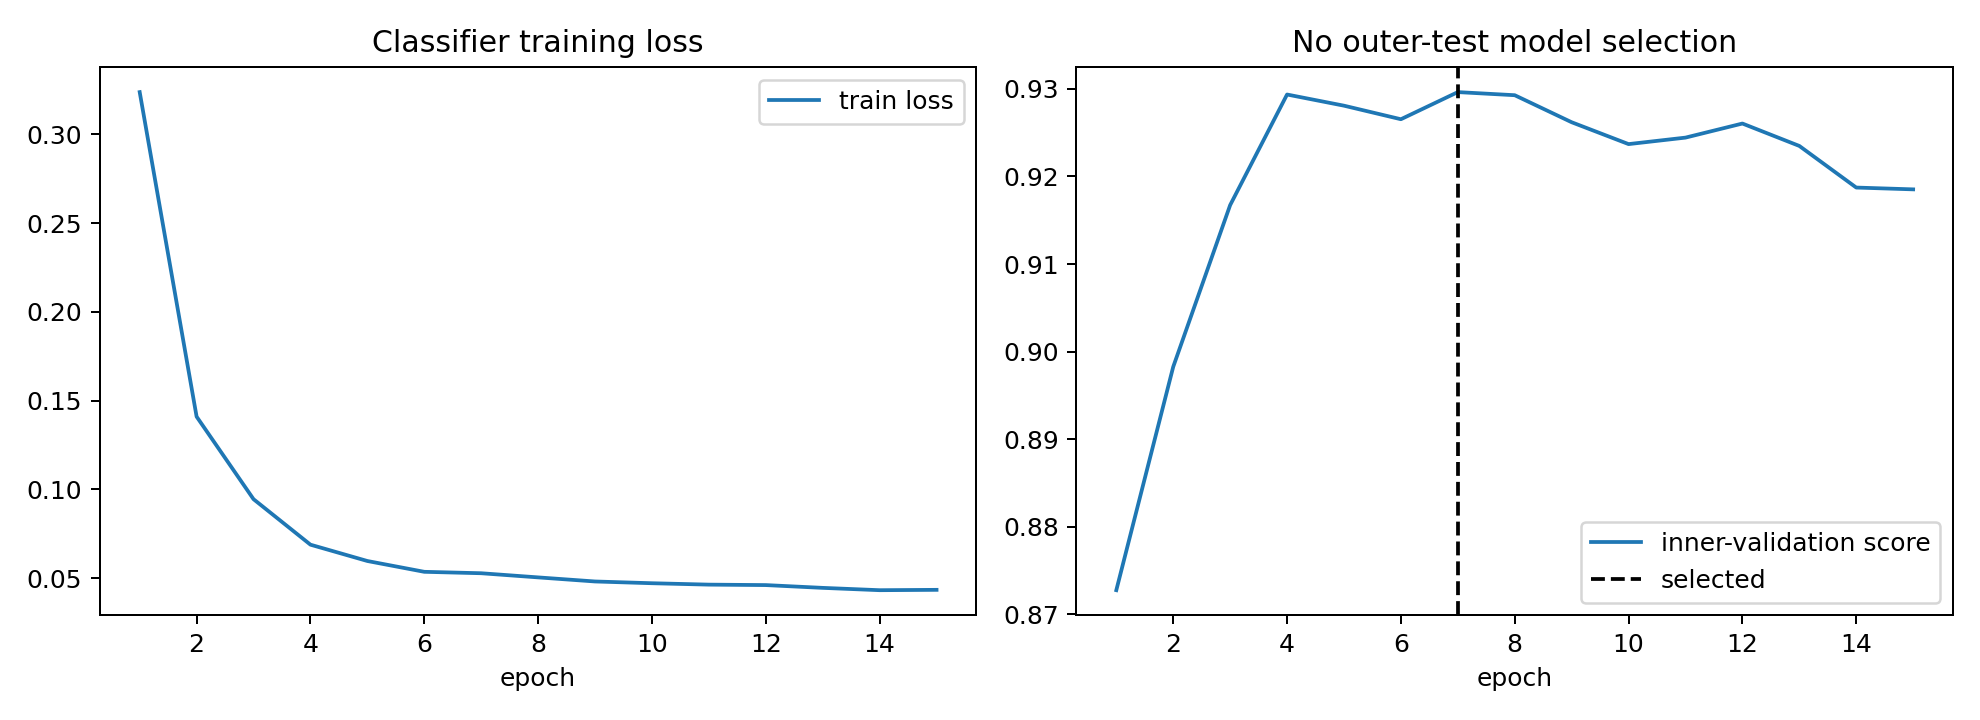

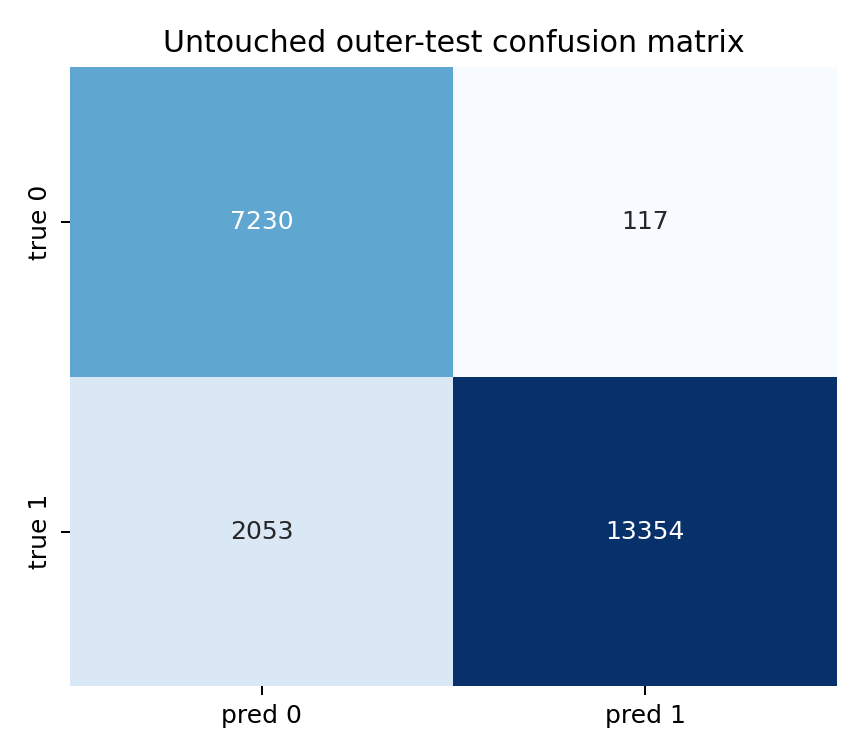

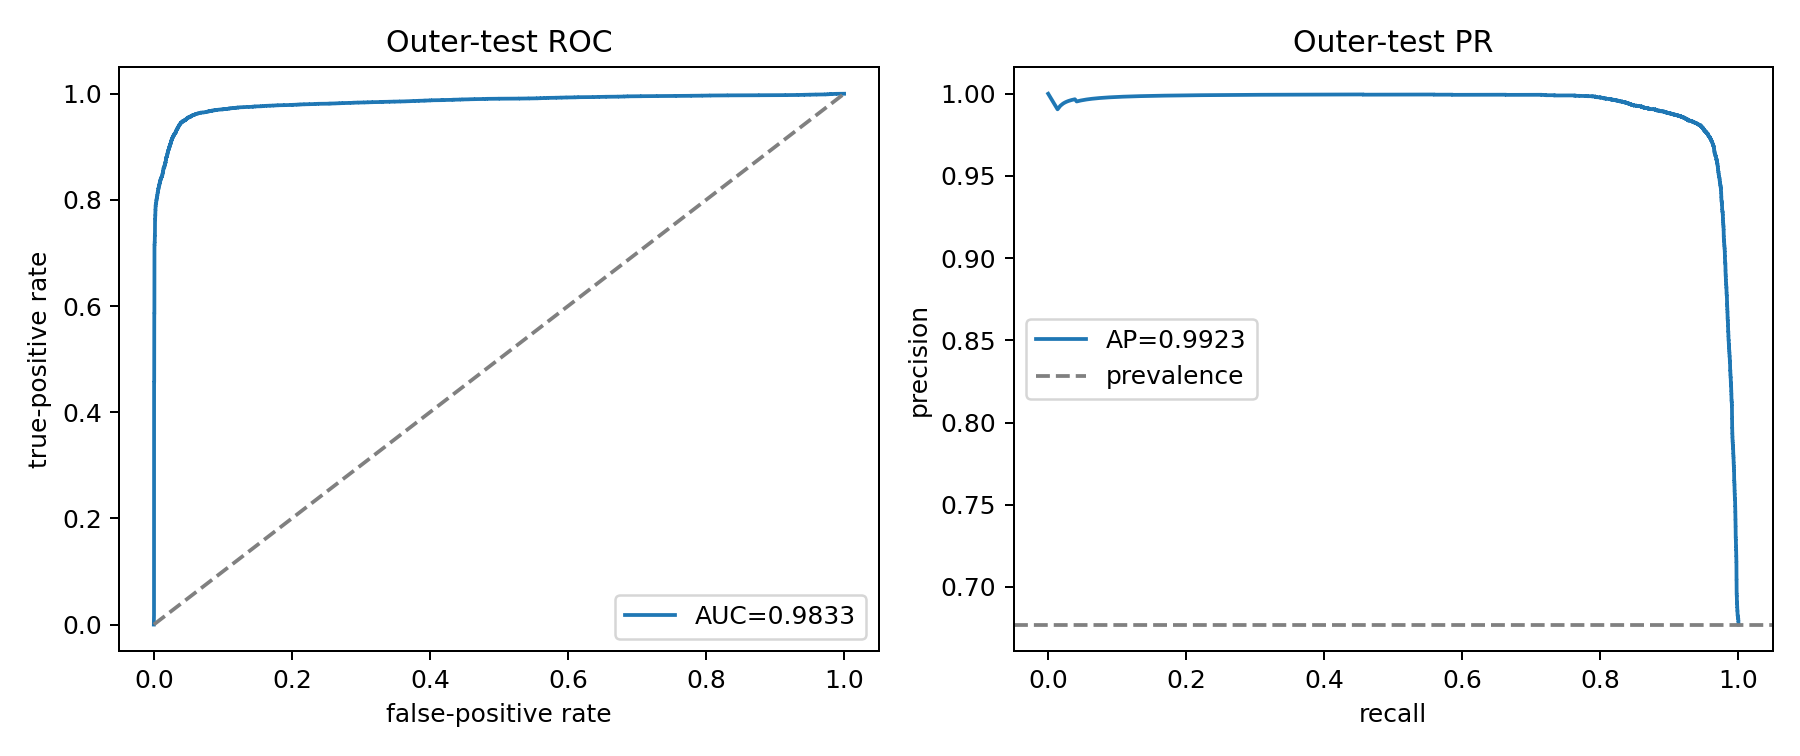

Canonical CFE oracle seed (inner validation only): 55
{'phase': 'classifier_training_and_diagnostics', 'wall_seconds': 34.96302509200001}


In [5]:
_phase_started = time.perf_counter()
seeds = [55]
max_epochs = {"ecg": 35, "heartplus": 60, "mimic": 60}[DATASET]
models, histories, classifier_audits = {}, {}, {}
for seed in seeds:
    classifier_batch_size = 8192 if DATASET == "heartplus" else 1024
    model, history, audit = train_classifier(
        prepared, seed, DEVICE, max_epochs=max_epochs,
        patience=8,
        batch_size=classifier_batch_size,
    )
    models[seed], histories[seed], classifier_audits[seed] = model, history, audit

# Canonical seed is chosen strictly by inner-validation score, before test metrics.
canonical_seed = max(seeds, key=lambda seed: histories[seed].valid_selection_score.max())
oracle = models[canonical_seed]
classifier_rows = []
for seed in seeds:
    metric = classifier_diagnostics(models[seed], prepared, DEVICE, histories[seed],
                                    OUTPUT, prefix=f"classifier_seed{seed}")
    classifier_rows.append({**classifier_audits[seed], **metric,
                            "canonical_for_cfe": seed == canonical_seed})
classifier_table = pd.DataFrame(classifier_rows)
classifier_table.to_csv(OUTPUT / "classifier_metrics_by_seed.csv", index=False)
metric_columns = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc",
    "f2", "pr_auc", "specificity", "negative_predictive_value",
    "false_positive_rate", "false_negative_rate",
    "gmean_sensitivity_specificity", "balanced_accuracy", "mcc",
    "prevalence", "predicted_positive_rate",
    "subject_balanced_f1", "subject_balanced_roc_auc", "subject_balanced_pr_auc"]
    if c in classifier_table]
classifier_summary = pd.DataFrame({
    "metric": metric_columns,
    "mean": [classifier_table[c].mean() for c in metric_columns],
    "std": [classifier_table[c].std(ddof=1) if len(classifier_table) > 1 else 0.0
            for c in metric_columns],
})
classifier_summary.to_csv(OUTPUT / "classifier_metrics_summary.csv", index=False)
display(classifier_table)
display(classifier_summary)
display(Image(filename=str(OUTPUT / f"classifier_seed{canonical_seed}_training_curves.png")))
display(Image(filename=str(OUTPUT / f"classifier_seed{canonical_seed}_confusion_matrix.png")))
display(Image(filename=str(OUTPUT / f"classifier_seed{canonical_seed}_roc_pr_curves.png")))
print("Canonical CFE oracle seed (inner validation only):", canonical_seed)
record_phase("classifier_training_and_diagnostics", _phase_started)

## 3. Three-seed CounterGAN and DP-CounterGAN training

The schedule is frozen before paper execution. DP checkpoints use the final
epoch, never private-validation model selection. Non-private checkpoints may
use inner-validation selection. No outer CFE result is available in this stage.


In [6]:
_phase_started = time.perf_counter()
projector = DomainProjector(prepared)
constraint_table = pd.DataFrame({
    "processed_feature": prepared.feature_names,
    "immutable": projector.immutable_mask,
    "generation_low": projector.low,
    "generation_high": projector.high,
})
constraint_table.to_csv(OUTPUT / "feature_constraint_table.csv", index=False)

GAN_SEEDS = [11]
VARIANTS = [("countergan", None), ("dp_eps16", 16.0),
            ("dp_eps8", 8.0), ("dp_eps4", 4.0), ("dp_eps2", 2.0)]
# One common warm-up/ramp training protocol. The non-DP checkpoint is the
# CounterGAN baseline; all four DP checkpoints use the same unified
# sparse-diverse search contract below.
SCHEDULE = dict(
    epochs=300, batch_size=256, steps_per_epoch=20,
    secure_rng=True,
    warmup_epochs=30, ramp_epochs=180,
    classification_weight_start=8.0,
    classification_weight_end=12.0,
    proximity_weight_start=.04, proximity_weight_end=.20,
    sparsity_weight_start=.01, sparsity_weight_end=.10,
    group_sparsity_weight_start=0.0, group_sparsity_weight_end=.15,
    diversity_weight_start=0.0, diversity_weight_end=.08,
    direction_balance_weighting=True,
)
privacy_rows = []
for gan_seed in GAN_SEEDS:
    for variant, epsilon in VARIANTS:
        generator, history, privacy = train_countergan(
            prepared, oracle, projector, DEVICE,
            OUTPUT / "generators" / f"seed{gan_seed}" / variant,
            seed=gan_seed, epsilon=epsilon, delta=1e-5,
            max_grad_norm=1.0, **SCHEDULE,
        )
        privacy_rows.append({
            "generator_training_seed": gan_seed, "variant": variant,
            "training_protocol": "v55_generator_only_direction_balanced_warmup_ramp",
            **privacy,
        })
        print({"seed": gan_seed, "variant": variant,
               "selected_epoch": privacy["selected_epoch"],
               "history_rows": len(history)})
        del generator
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
privacy_table = pd.DataFrame(privacy_rows)
privacy_table.to_csv(OUTPUT / "privacy_accounting_all_training_seeds.csv", index=False)
dp_only = privacy_table[privacy_table.requested_epsilon.notna()].copy()
release_rows = []
for record in dp_only.itertuples():
    release_rows.append({
        "variant": record.variant,
        "release_scenario": f"single_checkpoint_seed{record.generator_training_seed}",
        "released_checkpoints": 1,
        "basic_composed_epsilon": record.achieved_epsilon_composed,
        "basic_composed_delta": record.composed_delta,
    })
for variant, group in dp_only.groupby("variant"):
    release_rows.append({
        "variant": variant,
        "release_scenario": "joint_release_all_training_seeds",
        "released_checkpoints": int(len(group)),
        "basic_composed_epsilon": float(group.achieved_epsilon_composed.sum()),
        "basic_composed_delta": float(group.composed_delta.sum()),
    })
dp_release_composition = pd.DataFrame(release_rows)
dp_release_composition.to_csv(OUTPUT / "dp_multi_checkpoint_release_composition.csv", index=False)
display(privacy_table)
display(dp_release_composition)
record_phase("generator_training", _phase_started)

if DATASET == "ecg":
    constraint_policy = pd.DataFrame([
        {"policy": "immutable", "features": "age | gender",
         "reason": "demographic factual attributes"},
        {"policy": "nonnegative", "features": "RR/power/variance/energy features",
         "reason": "signal-domain support"},
        {"policy": "derived equality", "features": "var = std^2",
         "reason": "internal ECG consistency"},
        {"policy": "derived equality", "features": "energy = 586 * rms^2",
         "reason": "window-energy consistency"},
        {"policy": "spectral bound", "features": "VLF + LF + VHF <= total_power",
         "reason": "spectral decomposition consistency"},
    ])
else:
    constraint_policy = pd.DataFrame([
        {"policy": "immutable", "features": "AgeCategory | Sex | Race | Stroke | Asthma | SkinCancer | Diabetic | KidneyDisease",
         "reason": "demographic/history attributes are not actionable"},
        {"policy": "ordinal grid", "features": "GenHealth | AgeCategory | Diabetic | Smoking",
         "reason": "valid survey categories"},
        {"policy": "binary grid", "features": "eight binary predictors",
         "reason": "valid survey categories"},
        {"policy": "monotonic", "features": "Former smoking cannot become Never",
         "reason": "history cannot be reversed"},
        {"policy": "raw range", "features": "PhysicalHealth | MentalHealth | SleepTime | BMI",
         "reason": "observed/clinical support"},
    ])
constraint_policy.to_csv(OUTPUT / "dataset_specific_constraint_policy.csv", index=False)
display(constraint_policy)


{'seed': 11, 'variant': 'countergan', 'selected_epoch': 169, 'history_rows': 300}


/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
08/23/2026 08:34:59:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.
08/23/2026 08:34:59:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


{'seed': 11, 'variant': 'dp_eps16', 'selected_epoch': 300, 'history_rows': 300}


08/23/2026 08:42:20:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.
08/23/2026 08:42:20:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


{'seed': 11, 'variant': 'dp_eps8', 'selected_epoch': 300, 'history_rows': 300}


...

{'seed': 11, 'variant': 'dp_eps4', 'selected_epoch': 300, 'history_rows': 300}
{'seed': 11, 'variant': 'dp_eps2', 'selected_epoch': 300, 'history_rows': 300}


,generator_training_seed,variant,training_protocol,requested_epsilon,delta,max_grad_norm,composition,secure_rng,secure_rng_backend,training_rows,...,expected_batch_size_generator,expected_batch_size_discriminator,sample_rate_generator,sample_rate_discriminator,component_delta_generator,component_delta_discriminator,composed_delta,achieved_epsilon_generator,achieved_epsilon_discriminator,achieved_epsilon_composed
0,11,countergan,v55_generator_only_direction_balanced_warmup_ramp,NaN,0.00001,1.0,basic sequential composition: epsilon_G + epsi...,False,pytorch_default_prng,69023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11,dp_eps16,v55_generator_only_direction_balanced_warmup_ramp,16.0,0.00001,1.0,basic sequential composition: epsilon_G + epsi...,True,torchcsprng:/dev/urandom,69023,...,256.0,256.0,0.003717,0.003717,0.000005,0.000005,0.00001,7.999296,7.999296,15.998593
2,11,dp_eps8,v55_generator_only_direction_balanced_warmup_ramp,8.0,0.00001,1.0,basic sequential composition: epsilon_G + epsi...,True,torchcsprng:/dev/urandom,69023,...,256.0,256.0,0.003717,0.003717,0.000005,0.000005,0.00001,3.999408,3.999408,7.998817
3,11,dp_eps4,v55_generator_only_direction_balanced_warmup_ramp,4.0,0.00001,1.0,basic sequential composition: epsilon_G + epsi...,True,torchcsprng:/dev/urandom,69023,...,256.0,256.0,0.003717,0.003717,0.000005,0.000005,0.00001,1.999600,1.999600,3.999201
4,11,dp_eps2,v55_generator_only_direction_balanced_warmup_ramp,2.0,0.00001,1.0,basic sequential composition: epsilon_G + epsi...,True,torchcsprng:/dev/urandom,69023,...,256.0,256.0,0.003717,0.003717,0.000005,0.000005,0.00001,0.999670,0.999670,1.999341


,variant,release_scenario,released_checkpoints,basic_composed_epsilon,basic_composed_delta
0,dp_eps16,single_checkpoint_seed11,1,15.998593,0.00001
1,dp_eps8,single_checkpoint_seed11,1,7.998817,0.00001
2,dp_eps4,single_checkpoint_seed11,1,3.999201,0.00001
3,dp_eps2,single_checkpoint_seed11,1,1.999341,0.00001
4,dp_eps16,joint_release_all_training_seeds,1,15.998593,0.00001
5,dp_eps2,joint_release_all_training_seeds,1,1.999341,0.00001
6,dp_eps4,joint_release_all_training_seeds,1,3.999201,0.00001
7,dp_eps8,joint_release_all_training_seeds,1,7.998817,0.00001


{'phase': 'generator_training', 'wall_seconds': 5104.938552676999}


,policy,features,reason
0,immutable,age | gender,demographic factual attributes
1,nonnegative,RR/power/variance/energy features,signal-domain support
2,derived equality,var = std^2,internal ECG consistency
3,derived equality,energy = 586 * rms^2,window-energy consistency
4,spectral bound,VLF + LF + VHF <= total_power,spectral decomposition consistency


## 4. Immutable training handoff and integrity gate

In [7]:
_phase_started = time.perf_counter()
import shutil

HANDOFF = OUTPUT / "paper_training_handoff"
HANDOFF.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "preprocessor": prepared.preprocessor,
    "feature_names": prepared.feature_names,
    "split": prepared.split,
}, HANDOFF / "preprocessor_and_split.joblib")

for seed, model in models.items():
    torch.save({
        "state_dict": model.state_dict(), "input_dim": prepared.x_train.shape[1],
        "classifier_config": CLASSIFIER_CONFIGS[DATASET],
        "classifier_audit": classifier_audits[seed],
        "canonical_for_cfe": seed == canonical_seed,
    }, HANDOFF / f"classifier_seed{seed}.pt")

for gan_seed in GAN_SEEDS:
    for variant, _ in VARIANTS:
        source_checkpoint = (OUTPUT / "generators" / f"seed{gan_seed}"
                             / variant / "countergan.pt")
        shutil.copy2(source_checkpoint,
                     HANDOFF / f"generator_seed{gan_seed}_{variant}.pt")

shutil.copy2("/kaggle/working/plaintext_cfe_pipeline.py",
             HANDOFF / "plaintext_cfe_pipeline.py")
privacy_table.to_csv(HANDOFF / "privacy_accounting.csv", index=False)
dp_release_composition.to_csv(
    HANDOFF / "dp_multi_checkpoint_release_composition.csv", index=False
)
classifier_table.to_csv(HANDOFF / "classifier_metrics_by_seed.csv", index=False)
dataset_accounting.to_csv(HANDOFF / "dataset_accounting.csv", index=False)
encoding_contract.to_csv(HANDOFF / "feature_encoding_contract.csv", index=False)
constraint_table.to_csv(HANDOFF / "feature_constraint_table.csv", index=False)

required = [
    "preprocessor_and_split.joblib", "plaintext_cfe_pipeline.py",
    "privacy_accounting.csv", "dp_multi_checkpoint_release_composition.csv",
    "classifier_metrics_by_seed.csv",
    "dataset_accounting.csv", "feature_encoding_contract.csv",
    "feature_constraint_table.csv",
] + [f"classifier_seed{seed}.pt" for seed in seeds] + [
    f"generator_seed{gan_seed}_{variant}.pt"
    for gan_seed in GAN_SEEDS for variant, _ in VARIANTS
]
checksums = {name: sha256_file(HANDOFF / name) for name in required}
manifest = {
    "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER", "stage": "paper_train", "dataset": DATASET,
    "gpu": gpu_name, "source_csv_sha256": input_audit["sha256"],
    "source_rows": input_audit["source_csv_rows"],
    "processed_inputs": input_audit["processed_inputs"],
    "classifier_seeds": seeds, "canonical_classifier_seed": canonical_seed,
    "generator_training_seeds": GAN_SEEDS,
    "variants": [name for name, _ in VARIANTS],
    "gan_schedule": SCHEDULE,
    "K": 10, "paper_budgets": [64, 128, 256, 512],
    "paper_queries_per_direction": 100,
    "method_search_seeds": [11],
    "files_sha256": checksums,
}
(HANDOFF / "training_handoff_manifest.json").write_text(
    json.dumps(manifest, indent=2, default=str)
)

dp = privacy_table[privacy_table.requested_epsilon.notna()].copy()
checks = {
    "t4": "T4" in gpu_name,
    "one_classifier_seed": set(classifier_table.seed) == {55},
    "one_generator_training_seed": set(privacy_table.generator_training_seed) == set(GAN_SEEDS),
    "five_generator_checkpoints": len(list(HANDOFF.glob("generator_seed*_*.pt"))) == 5,
    "epsilon_panel_complete": set(privacy_table.variant) == {"countergan", "dp_eps16", "dp_eps8", "dp_eps4", "dp_eps2"},
    "one_canonical_classifier": int(classifier_table.canonical_for_cfe.sum()) == 1,
    "dp_composition_within_requested_epsilon": (
        dp.achieved_epsilon_composed <= dp.requested_epsilon * 1.01
    ).all(),
    "dp_delta_composition_within_requested_delta": (
        dp.composed_delta <= dp.delta * 1.000001
    ).all(),
    "dp_accountant_internals_present": dp[[
        "noise_multiplier_generator", "noise_multiplier_discriminator",
        "sample_rate_generator", "sample_rate_discriminator",
        "actual_generator_optimizer_steps",
        "actual_discriminator_optimizer_steps",
    ]].notna().all().all(),
    "joint_seed_release_composition_reported": (
        dp_release_composition.release_scenario.eq(
            "joint_release_all_training_seeds"
        ).sum() == 4
    ),
    "all_handoff_files_present": all((HANDOFF / name).is_file() for name in required),
    "all_checksums_reproducible": all(
        sha256_file(HANDOFF / name) == digest for name, digest in checksums.items()
    ),
}
acceptance = {
    "accepted": bool(all(checks.values())), "checks": checks,
    "manifest": manifest, "outer_cfe_evaluation_performed": False,
}
(OUTPUT / "paper_train_acceptance.json").write_text(
    json.dumps(acceptance, indent=2, default=str)
)
archive = shutil.make_archive(
    "/kaggle/working/ecg_q1v5_training_handoff", "zip",
    root_dir=HANDOFF,
)
print(json.dumps(acceptance, indent=2, default=str))
print("Frozen handoff:", archive)
if not acceptance["accepted"]:
    raise RuntimeError("Paper training handoff gate failed")
record_phase("training_handoff", _phase_started)

{
  "accepted": true,
  "checks": {
    "t4": true,
    "one_classifier_seed": true,
    "one_generator_training_seed": true,
    "five_generator_checkpoints": true,
    "epsilon_panel_complete": true,
    "one_canonical_classifier": true,
    "dp_composition_within_requested_epsilon": "True",
    "dp_delta_composition_within_requested_delta": "True",
    "dp_accountant_internals_present": "True",
    "joint_seed_release_composition_reported": "True",
    "all_handoff_files_present": true,
    "all_checksums_reproducible": true
  },
  "manifest": {
    "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER",
    "stage": "paper_train",
    "dataset": "ecg",
    "gpu": "Tesla T4",
    "source_csv_sha256": "ffa8482f426ca0fdb6055f745610e88befe7e0cb36889a0bd2678dfe7bca5a9b",
    "source_rows": 113846,
    "processed_inputs": 20,
    "classifier_seeds": [
      55
    ],
    "canonical_classifier_seed": 55,
    "generator_training_seeds": [
      11
    ],
    "variants": [
      "countergan",
 

## 5. Begin frozen in-session evaluation

All model and generator training is now complete. The cells below reload the
just-frozen checkpoints from this notebook's own handoff directory. No
architecture, threshold, CFE objective, population, round cap or feature
constraint is changed after seeing outer-test CFE outcomes.


In [8]:
BENCHMARK_DIR = OUTPUT / "q1_v5_benchmark"
TABLE_DIR = OUTPUT / "q1_v5_tables"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
privacy_accounting = privacy_table.copy()

def load_generators(training_seed):
    result = {}
    for variant in manifest["variants"]:
        payload = torch.load(
            HANDOFF / f"generator_seed{training_seed}_{variant}.pt",
            map_location=DEVICE,
        )
        generator = ResidualGenerator(payload["input_dim"]).to(DEVICE)
        generator.load_state_dict(payload["state_dict"]); generator.eval()
        result[variant] = generator
    return result

print({"handoff": "same notebook, frozen before CFE evaluation",
       "canonical_classifier_seed": canonical_seed,
       "generator_training_seeds": manifest["generator_training_seeds"]})

{'handoff': 'same notebook, frozen before CFE evaluation', 'canonical_classifier_seed': 55, 'generator_training_seeds': [11]}


## 6. Direction-selectable stratified smoke cohort

In [9]:
K_PRIMARY = 10
BUDGETS = [64, 128, 256, 512]
METHOD_SEARCH_SEEDS = [11]
GENERATOR_TRAINING_SEEDS = [11]
PER_DIRECTION = 100
TARGET_DIRECTIONS = "both"
BASE_POPULATION = 64
MARGIN = .10
BASELINE_METHODS = {
    "uniform_random", "genetic_cfe", "dice_gradient_style", "wachter_style",
}
LEARNED_METHODS = {"countergan_one_shot", "proposed_countergan", "countergan_sparse_diverse_no_dp",
    "proposed_dp_eps16_sparse_diverse",
    "proposed_dp_eps8_sparse_diverse",
    "proposed_dp_eps4_sparse_diverse",
    "proposed_dp_eps2_sparse_diverse"}
queries = select_stratified_bidirectional_queries(
    prepared, oracle, DEVICE, per_direction=PER_DIRECTION, seed=707
)
DIRECTION_OPTIONS = {
    "both": {"disease_to_no_disease", "no_disease_to_disease"},
    "disease_to_no_disease": {"disease_to_no_disease"},
    "no_disease_to_disease": {"no_disease_to_disease"},
}
if TARGET_DIRECTIONS not in DIRECTION_OPTIONS:
    raise ValueError(f"Unsupported TARGET_DIRECTIONS={TARGET_DIRECTIONS!r}")
ACTIVE_DIRECTIONS = DIRECTION_OPTIONS[TARGET_DIRECTIONS]
queries = queries[queries.direction.isin(ACTIVE_DIRECTIONS)].copy()
queries.to_csv(OUTPUT / "outer_test_query_manifest_v5.csv", index=False)
display(pd.DataFrame([{
    "target_directions": TARGET_DIRECTIONS,
    "active_directions": ", ".join(sorted(ACTIVE_DIRECTIONS)),
    "factuals": queries.query_id.nunique(),
    "factuals_per_direction": PER_DIRECTION,
    "K_requested_per_factual": K_PRIMARY,
    "initial_tuning_population": BASE_POPULATION,
    "candidate_budgets": str(BUDGETS),
    "maximum_rounds": str([b // BASE_POPULATION for b in BUDGETS]),
    "classifier_seed": 55,
    "generator_training_seed": 11,
    "search_seed": 11,
}]))
cohort = queries.groupby(["direction", "difficulty_stratum"], as_index=False).agg(
    n_factuals=("query_id", "nunique"),
    probability_min=("query_probability", "min"),
    probability_mean=("query_probability", "mean"),
    probability_max=("query_probability", "max"),
    absolute_logit_mean=("absolute_query_logit", "mean"),
)
cohort.to_csv(TABLE_DIR / "01_stratified_outer_cohort.csv", index=False)
display(cohort)


,target_directions,active_directions,factuals,factuals_per_direction,K_requested_per_factual,initial_tuning_population,candidate_budgets,maximum_rounds,classifier_seed,generator_training_seed,search_seed
0,both,"disease_to_no_disease, no_disease_to_disease",200,100,10,64,"[64, 128, 256, 512]","[1, 2, 4, 8]",55,11,11


,direction,difficulty_stratum,n_factuals,probability_min,probability_mean,probability_max,absolute_logit_mean
0,disease_to_no_disease,high_confidence,33,0.999976,0.999994,1.000000,12.956515
1,disease_to_no_disease,medium_confidence,33,0.993076,0.998484,0.999974,7.740555
2,disease_to_no_disease,near_boundary,34,0.514302,0.848040,0.992278,2.562006
3,no_disease_to_disease,high_confidence,33,0.000047,0.000499,0.001423,7.955442
4,no_disease_to_disease,medium_confidence,33,0.001525,0.004436,0.010047,5.579475
5,no_disease_to_disease,near_boundary,34,0.013425,0.097566,0.417452,2.707454


## 7. Frozen MIMIC-compatible DP4-P transfer audit

ECG and Heart+ now use the same DP4-P contract as the accepted MIMIC paper:
group-off=0.06, feature-off=0.03, base fraction=0.50 and MMR=0.0. This is a
transfer audit on correctly classified inner-validation factuals, not a new
outer-test tuning loop. Every base, prune and fill proposal consumes the same
declared classifier-candidate budget as DP4, and missing K slots remain
failures. The contract is frozen before the outer-test cohort.

In [10]:
_phase_started = time.perf_counter()
PRUNE_GROUP_OFF = 0.1
PRUNE_FEATURE_OFF = 0.015
PRUNE_MMR = 0.0
EPS_PANEL = [16, 8, 4, 2]
PRUNE_INNER_SEARCH_SEEDS = [11]
PRUNE_INNER_PER_DIRECTION = 4
PRUNE_INNER_BUDGET = 512
SD_BUDGET = 512
INNER_YIELD_TOLERANCE = .10
V5_PROFILE_GRID = [('balanced', 0.1, 0.015, 0.5, 0.16, 0.5, 0.5), ('sparse', 0.12, 0.025, 0.5, 0.12, 0.72, 1.0), ('diverse', 0.1, 0.015, 0.65, 0.12, 0.55, 3.0), ('sparse_diverse', 0.11, 0.02, 0.55, 0.1, 0.66, 2.0)]
BASE_FRACTION_CANDIDATES = sorted({row[3] for row in V5_PROFILE_GRID})
canonical_generators = load_generators(GENERATOR_TRAINING_SEEDS[0])

# V5.5 deployment releases and queries only the generator.  The GAN
# discriminator remains a training-only component and is never loaded
# by profile tuning, population selection or outer CFE search.
canonical_plausibility_scorers = {}
inner_factuals = calibration_queries(
    prepared, oracle, DEVICE, per_direction=PRUNE_INNER_PER_DIRECTION,
    seed=2708,
)

# Tune search only on inner validation. Proximity is deliberately reported but
# not used as a hard gate: V5 prioritizes sparse, diverse and robust CFE sets.
profile_rows = []
for (profile, group_off, feature_off, base_fraction,
     proximity_weight, sparsity_weight, diversity_weight) in V5_PROFILE_GRID:
    for query_number, (query, desired, direction) in enumerate(inner_factuals):
        config = SearchConfig(
            population=BASE_POPULATION,
            max_rounds=PRUNE_INNER_BUDGET // BASE_POPULATION,
            k=K_PRIMARY, margin=MARGIN,
            proximity_weight=proximity_weight,
            sparsity_weight=sparsity_weight,
            plausibility_weight=0.0,
            set_diversity_weight=diversity_weight,
        )
        run_seed = 5_000_000 + 10_007 * query_number + 101 * 11
        cfes, audit, runtime = search_countergan_validity_group_prune(
            query, desired, canonical_generators["dp_eps4"], oracle,
            projector, config, DEVICE, run_seed,
            group_off_threshold=group_off,
            feature_off_threshold=feature_off,
            base_fraction=base_fraction, stop_when_k=False,
        )
        metrics = cfe_set_metrics(
            cfes, query, desired, oracle, projector, config, DEVICE,
            runtime, audit=audit, robustness_seed=run_seed + 7_000_000,
            robustness_repetitions=6, fidelity_samples=64,
        )
        profile_rows.append({
            "profile": profile, "query_number": query_number,
            "direction": direction, "group_off": group_off,
            "feature_off": feature_off, "base_fraction": base_fraction,
            "proximity_weight": proximity_weight,
            "sparsity_weight": sparsity_weight,
            "diversity_weight": diversity_weight,
            **metrics,
            "group_sparsity": (
                float(projector.group_sparsity(cfes, query).mean())
                if len(cfes) else np.nan
            ),
        })
profile_tuning_raw = pd.DataFrame(profile_rows)
profile_keys = [
    "profile", "group_off", "feature_off", "base_fraction",
    "proximity_weight", "sparsity_weight", "diversity_weight",
]
profile_tuning_summary = profile_tuning_raw.groupby(
    profile_keys,
    as_index=False,
).mean(numeric_only=True)
profile_direction_summary = profile_tuning_raw.groupby(
    profile_keys + ["direction"], as_index=False,
).mean(numeric_only=True)
profile_direction_floor = profile_direction_summary.groupby(
    profile_keys, as_index=False,
).agg(
    worst_direction_yield=("valid_cfe_yield_at_k", "min"),
    best_direction_yield=("valid_cfe_yield_at_k", "max"),
    worst_direction_coverage=("coverage_at_1", "min"),
    worst_direction_robustness=("robust_completeness_at_k", "min"),
)
profile_direction_floor["direction_yield_gap"] = (
    profile_direction_floor.best_direction_yield
    - profile_direction_floor.worst_direction_yield
)
profile_tuning_summary = profile_tuning_summary.merge(
    profile_direction_floor, on=profile_keys, validate="one_to_one"
)
best_inner_yield = float(profile_tuning_summary.valid_cfe_yield_at_k.max())
best_inner_worst_direction = float(
    profile_tuning_summary.worst_direction_yield.max()
)
best_inner_full = float(profile_tuning_summary.full_k_success.max())
best_inner_robust = float(
    profile_tuning_summary.robust_completeness_at_k.max()
)
eligible_profiles = profile_tuning_summary[
    (profile_tuning_summary.valid_cfe_yield_at_k
     >= best_inner_yield - INNER_YIELD_TOLERANCE)
    & (profile_tuning_summary.worst_direction_yield
       >= best_inner_worst_direction - INNER_YIELD_TOLERANCE)
    
    & (profile_tuning_summary.full_k_success >= best_inner_full - .10)
    & (profile_tuning_summary.robust_completeness_at_k
       >= best_inner_robust - .10)
    & (profile_tuning_summary.constraint_validity >= .999)
].copy()
if len(eligible_profiles) == 0:
    # Deterministic fallback retains validity first; it is surfaced in the
    # contract and never chosen from outer-test results.
    eligible_profiles = profile_tuning_summary[
        (profile_tuning_summary.valid_cfe_yield_at_k
         >= best_inner_yield - INNER_YIELD_TOLERANCE)
        & (profile_tuning_summary.worst_direction_yield
           >= best_inner_worst_direction - INNER_YIELD_TOLERANCE)
        
    ].copy()
    V5_SELECTION_FALLBACK = True
else:
    V5_SELECTION_FALLBACK = False
eligible_profiles["sparse_diverse_score"] = (
    .25 * eligible_profiles.sparsity.fillna(0)
    + .15 * eligible_profiles.group_sparsity.fillna(0)
    + .15 * eligible_profiles.diversity.fillna(0)
    + .20 * eligible_profiles.robust_completeness_at_k.fillna(0)
    + .25 * eligible_profiles.worst_direction_yield.fillna(0)
)
selected_profile = eligible_profiles.sort_values(
    ["sparse_diverse_score", "valid_cfe_yield_at_k",
     "generation_time_to_k_or_cap_seconds", "profile"],
    ascending=[False, False, True, True],
).iloc[0]
SD_PROFILE = str(selected_profile.profile)
SD_GROUP_OFF = float(selected_profile.group_off)
SD_FEATURE_OFF = float(selected_profile.feature_off)
PRUNE_BASE_FRACTION = float(selected_profile.base_fraction)
SD_PROXIMITY_WEIGHT = float(selected_profile.proximity_weight)
SD_SPARSITY_WEIGHT = float(selected_profile.sparsity_weight)
SD_MMR = float(selected_profile.diversity_weight)
profile_tuning_raw.to_csv(TABLE_DIR / "00_v5_profile_tuning_raw.csv", index=False)
profile_tuning_summary.to_csv(
    TABLE_DIR / "00_v5_profile_tuning_summary.csv", index=False
)
profile_direction_summary.to_csv(
    TABLE_DIR / "00_v5_profile_tuning_by_direction.csv", index=False
)

# Population/round tuning at a matched counted-candidate budget. Selection is
# inner-validation-only and preserves the total candidate budget. This lets a
# dataset prefer wider batches/fewer rounds (or narrower batches/more rounds)
# without looking at outer-test success.
POPULATION_SENSITIVITY = [16, 32, 64, 128, 256, 512]
POPULATION_SENSITIVITY_BUDGET = 512
population_round_rows = []
for population_value in POPULATION_SENSITIVITY:
    maximum_rounds = POPULATION_SENSITIVITY_BUDGET // population_value
    for query_number, (query, desired, direction) in enumerate(inner_factuals):
        config = SearchConfig(
            population=population_value,
            max_rounds=maximum_rounds,
            k=K_PRIMARY, margin=MARGIN,
            proximity_weight=SD_PROXIMITY_WEIGHT,
            sparsity_weight=SD_SPARSITY_WEIGHT,
            plausibility_weight=0.0,
            set_diversity_weight=SD_MMR,
        )
        run_seed = 5_500_000 + 10_007 * query_number + 101 * 11
        cfes, audit, runtime = search_countergan_validity_group_prune(
            query, desired, canonical_generators["dp_eps4"], oracle,
            projector, config, DEVICE, run_seed,
            group_off_threshold=SD_GROUP_OFF,
            feature_off_threshold=SD_FEATURE_OFF,
            base_fraction=PRUNE_BASE_FRACTION, stop_when_k=False,
        )
        metrics = cfe_set_metrics(
            cfes, query, desired, oracle, projector, config, DEVICE,
            runtime, audit=audit, robustness_seed=run_seed + 7_000_000,
            robustness_repetitions=6, fidelity_samples=64,
        )
        population_round_rows.append({
            "population": population_value,
            "maximum_rounds": maximum_rounds,
            "candidate_budget": POPULATION_SENSITIVITY_BUDGET,
            "query_number": query_number,
            "direction": direction,
            **metrics,
            "group_sparsity": (
                float(projector.group_sparsity(cfes, query).mean())
                if len(cfes) else np.nan
            ),
        })
population_round_raw = pd.DataFrame(population_round_rows)
population_round_summary = population_round_raw.groupby(
    ["population", "maximum_rounds", "candidate_budget"], as_index=False
).mean(numeric_only=True)
POPULATION_YIELD_TOLERANCE = .02
best_population_yield = float(
    population_round_summary.valid_cfe_yield_at_k.max()
)
eligible_populations = population_round_summary[
    population_round_summary.valid_cfe_yield_at_k
    >= best_population_yield - POPULATION_YIELD_TOLERANCE
].copy()
eligible_populations["population_selection_score"] = (
    .35 * eligible_populations.valid_cfe_yield_at_k.fillna(0)
    + .25 * eligible_populations.robust_completeness_at_k.fillna(0)
    + .20 * eligible_populations.sparsity.fillna(0)
    + .10 * eligible_populations.diversity.fillna(0)
    - .10 * eligible_populations.proximity.fillna(1)
)
# Population is prospectively frozen from the completed V5.4 inner
# frontier with an explicit encrypted-round cost.  This V5.5 run reports the
# full sensitivity grid but cannot retune the deployment population on its
# own outer-test results.
PREDECLARED_HE_POPULATION = 64
SD_POPULATION = PREDECLARED_HE_POPULATION
selected_population = population_round_summary.loc[
    population_round_summary.population.astype(int).eq(SD_POPULATION)
].iloc[0]
population_round_summary["yield_noninferior"] = (
    population_round_summary.valid_cfe_yield_at_k
    >= best_population_yield - POPULATION_YIELD_TOLERANCE
)
population_round_summary["population_selection_score"] = (
    .35 * population_round_summary.valid_cfe_yield_at_k.fillna(0)
    + .25 * population_round_summary.robust_completeness_at_k.fillna(0)
    + .20 * population_round_summary.sparsity.fillna(0)
    + .10 * population_round_summary.diversity.fillna(0)
    - .10 * population_round_summary.proximity.fillna(1)
)
population_round_summary["selected_for_outer"] = (
    population_round_summary.population.astype(int).eq(SD_POPULATION)
)
# Downstream inner epsilon audit and the untouched outer evaluation both use
# the population frozen here. The counted budgets remain 64/128/256/512.
BASE_POPULATION = SD_POPULATION
population_round_raw.to_csv(
    TABLE_DIR / "00_population_round_sensitivity_raw.csv", index=False
)
population_round_summary.to_csv(
    TABLE_DIR / "00_population_round_sensitivity_summary.csv", index=False
)

# After the profile is frozen, audit all four epsilon checkpoints under exactly
# the same search contract. Epsilon is not selected using privacy-attack AUC.
unified_inner_rows = []
for epsilon_value in EPS_PANEL:
    generator_key = f"dp_eps{epsilon_value}"
    method_name = f"proposed_dp_eps{epsilon_value}_sparse_diverse"
    for query_number, (query, desired, direction) in enumerate(inner_factuals):
        config = SearchConfig(
            population=BASE_POPULATION,
            max_rounds=PRUNE_INNER_BUDGET // BASE_POPULATION,
            k=K_PRIMARY, margin=MARGIN,
            proximity_weight=SD_PROXIMITY_WEIGHT,
            sparsity_weight=SD_SPARSITY_WEIGHT,
            plausibility_weight=0.0,
            set_diversity_weight=SD_MMR,
        )
        run_seed = 6_000_000 + 10_007 * query_number + 101 * 11
        cfes, audit, runtime = search_countergan_validity_group_prune(
            query, desired, canonical_generators[generator_key], oracle,
            projector, config, DEVICE, run_seed,
            group_off_threshold=SD_GROUP_OFF,
            feature_off_threshold=SD_FEATURE_OFF,
            base_fraction=PRUNE_BASE_FRACTION, stop_when_k=False,
        )
        metrics = cfe_set_metrics(
            cfes, query, desired, oracle, projector, config, DEVICE,
            runtime, audit=audit, robustness_seed=run_seed + 7_000_000,
            robustness_repetitions=6, fidelity_samples=64,
        )
        unified_inner_rows.append({
            "method": method_name, "epsilon": epsilon_value,
            "search_seed": 11, "query_number": query_number,
            "direction": direction, **metrics,
            "group_sparsity": (
                float(projector.group_sparsity(cfes, query).mean())
                if len(cfes) else np.nan
            ),
        })
prune_inner_raw = pd.DataFrame(unified_inner_rows)
prune_inner_summary = prune_inner_raw.groupby(
    "method", as_index=False
).mean(numeric_only=True)
profile_tuning_raw.to_csv(TABLE_DIR / "00_base_fraction_tuning_raw.csv", index=False)
profile_tuning_summary.to_csv(
    TABLE_DIR / "00_base_fraction_tuning_summary.csv", index=False
)
prune_inner_raw.to_csv(TABLE_DIR / "00_unified_inner_raw.csv", index=False)
prune_inner_summary.to_csv(TABLE_DIR / "00_unified_inner_summary.csv", index=False)
unified_contract = {
    "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER",
    "methods": [f"proposed_dp_eps{e}_sparse_diverse" for e in EPS_PANEL],
    "profile": SD_PROFILE,
    "selection_fallback": V5_SELECTION_FALLBACK,
    "selection_scope": "inner validation only",
    "direction_selection_policy": 'macro plus worst-direction noninferiority',
    "outer_test_used_for_selection": False,
    "population_selection_scope": "prospectively frozen from V5.4 inner validation plus HE round cost",
    "population_yield_tolerance": POPULATION_YIELD_TOLERANCE,
    "candidate_budget": SD_BUDGET,
    "K": K_PRIMARY, "population": BASE_POPULATION,
    "maximum_rounds": SD_BUDGET // BASE_POPULATION,
    "group_off_threshold": SD_GROUP_OFF,
    "feature_off_threshold": SD_FEATURE_OFF,
    "base_fraction": PRUNE_BASE_FRACTION,
    "proximity_weight": SD_PROXIMITY_WEIGHT,
    "sparsity_weight": SD_SPARSITY_WEIGHT,
    "mmr_diversity_weight": SD_MMR,
    "proximity_used_as_hard_selection_gate": False,
    "search_plausibility_source": "none; generator-only deployment",
    "raw_training_knn_used_during_dp_search": False,
    "discriminator_released_or_queried_at_inference": False,
    "all_base_prune_fill_candidates_counted": True,
    "full_budget_then_mmr": True,
}
(TABLE_DIR / "00_unified_method_contract.json").write_text(
    json.dumps(unified_contract, indent=2)
)
method_registry = pd.DataFrame([
    ["UR", "uniform_random", "fixed counted forward-score budget", True],
    ["GA", "genetic_cfe", "fixed counted forward-score budget", True],
    ["DG", "dice_gradient_style", "fixed optimization-step proxy", True],
    ["WA", "wachter_style", "fixed optimization-step proxy", True],
    ["G1", "countergan_one_shot", "generator + final counted scoring", True],
    ["CGI", "proposed_countergan", "native early-stop iterative generator baseline", True],
    ["CG-SD", "countergan_sparse_diverse_no_dp", "non-DP generator + identical fixed-cap prune/MMR", True],
    ["DP16", "proposed_dp_eps16_sparse_diverse", "DP generator + counted prune/MMR", True],
    ["DP8", "proposed_dp_eps8_sparse_diverse", "DP generator + counted prune/MMR", True],
    ["DP4", "proposed_dp_eps4_sparse_diverse", "DP generator + counted prune/MMR", True],
    ["DP2", "proposed_dp_eps2_sparse_diverse", "DP generator + counted prune/MMR", True],
], columns=["code", "method", "oracle_access_or_budget", "included_in_primary"])
method_registry["K"] = K_PRIMARY
method_registry["population"] = BASE_POPULATION
method_registry["budgets"] = str(BUDGETS)
method_registry["search_seed"] = 11
method_registry["selected_profile"] = np.where(
    method_registry.code.isin(["DP16", "DP8", "DP4", "DP2"]),
    SD_PROFILE, "not_applicable",
)
method_registry.to_csv(TABLE_DIR / "00_method_registry.csv", index=False)
display(profile_tuning_summary)
display(pd.DataFrame([unified_contract]))
display(prune_inner_summary)
display(population_round_summary)
display(method_registry)
record_phase("v5_inner_profile_selection", _phase_started)


,profile,group_off,feature_off,base_fraction,proximity_weight,sparsity_weight,diversity_weight,query_number,returned,reference_valid_returned,...,candidates_to_k10,candidates_to_k10_or_cap,time_to_k10_seconds,time_to_k10_or_cap_seconds,group_sparsity,worst_direction_yield,best_direction_yield,worst_direction_coverage,worst_direction_robustness,direction_yield_gap
0,balanced,0.10,0.015,0.50,0.16,0.50,0.5,3.5,10.0,10.0,...,88.0,88.0,0.350494,0.350494,0.690972,1.0,1.0,1.0,0.800,0.0
1,diverse,0.10,0.015,0.65,0.12,0.55,3.0,3.5,10.0,10.0,...,96.0,96.0,0.372278,0.372278,0.640972,1.0,1.0,1.0,0.950,0.0
2,sparse,0.12,0.025,0.50,0.12,0.72,1.0,3.5,10.0,10.0,...,88.0,88.0,0.341883,0.341883,0.726389,1.0,1.0,1.0,0.950,0.0
3,sparse_diverse,0.11,0.020,0.55,0.10,0.66,2.0,3.5,10.0,10.0,...,88.0,88.0,0.343489,0.343489,0.695139,1.0,1.0,1.0,0.875,0.0


,protocol,methods,profile,selection_fallback,selection_scope,direction_selection_policy,outer_test_used_for_selection,population_selection_scope,population_yield_tolerance,candidate_budget,...,base_fraction,proximity_weight,sparsity_weight,mmr_diversity_weight,proximity_used_as_hard_selection_gate,search_plausibility_source,raw_training_knn_used_during_dp_search,discriminator_released_or_queried_at_inference,all_base_prune_fill_candidates_counted,full_budget_then_mmr
0,Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER,"[proposed_dp_eps16_sparse_diverse, proposed_dp...",sparse,False,inner validation only,macro plus worst-direction noninferiority,False,prospectively frozen from V5.4 inner validatio...,0.02,512,...,0.5,0.12,0.72,1.0,False,none; generator-only deployment,False,False,True,True


,method,epsilon,search_seed,query_number,returned,reference_valid_returned,returned_validity,conditional_returned_validity,valid_cfe_yield_at_k,completeness_at_k,...,time_to_k5_seconds,time_to_k5_or_cap_seconds,k10_achieved,rounds_to_k10,rounds_to_k10_or_cap,candidates_to_k10,candidates_to_k10_or_cap,time_to_k10_seconds,time_to_k10_or_cap_seconds,group_sparsity
0,proposed_dp_eps16_sparse_diverse,16.0,11.0,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,0.269426,0.269426,1.0,1.375,1.375,88.0,88.0,0.332197,0.332197,0.727083
1,proposed_dp_eps2_sparse_diverse,2.0,11.0,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,0.240900,0.240900,1.0,1.125,1.125,72.0,72.0,0.271415,0.271415,0.748611
2,proposed_dp_eps4_sparse_diverse,4.0,11.0,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,0.257274,0.257274,1.0,1.125,1.125,72.0,72.0,0.257274,0.257274,0.725694
3,proposed_dp_eps8_sparse_diverse,8.0,11.0,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,0.300351,0.300351,1.0,1.500,1.500,96.0,96.0,0.360893,0.360893,0.734028


,population,maximum_rounds,candidate_budget,query_number,returned,reference_valid_returned,returned_validity,conditional_returned_validity,valid_cfe_yield_at_k,completeness_at_k,...,rounds_to_k10,rounds_to_k10_or_cap,candidates_to_k10,candidates_to_k10_or_cap,time_to_k10_seconds,time_to_k10_or_cap_seconds,group_sparsity,yield_noninferior,population_selection_score,selected_for_outer
0,16,32,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,3.000,3.000,48.0,48.0,0.636967,0.636967,0.738889,True,0.699341,False
1,32,16,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,1.750,1.750,56.0,56.0,0.400626,0.400626,0.724306,True,0.713026,False
2,64,8,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,1.250,1.250,80.0,80.0,0.304179,0.304179,0.750000,True,0.712157,True
3,128,4,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,1.125,1.125,144.0,144.0,0.298896,0.298896,0.645833,True,0.702967,False
4,256,2,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,1.125,1.125,288.0,288.0,0.382515,0.382515,0.610417,True,0.688534,False
5,512,1,512,3.5,10.0,10.0,1.0,1.0,1.0,1.0,...,1.000,1.000,512.0,512.0,0.569823,0.569823,0.542361,True,0.660017,False


,code,method,oracle_access_or_budget,included_in_primary,K,population,budgets,search_seed,selected_profile
0,UR,uniform_random,fixed counted forward-score budget,True,10,64,"[64, 128, 256, 512]",11,not_applicable
1,GA,genetic_cfe,fixed counted forward-score budget,True,10,64,"[64, 128, 256, 512]",11,not_applicable
2,DG,dice_gradient_style,fixed optimization-step proxy,True,10,64,"[64, 128, 256, 512]",11,not_applicable
3,WA,wachter_style,fixed optimization-step proxy,True,10,64,"[64, 128, 256, 512]",11,not_applicable
4,G1,countergan_one_shot,generator + final counted scoring,True,10,64,"[64, 128, 256, 512]",11,not_applicable
5,CGI,proposed_countergan,native early-stop iterative generator baseline,True,10,64,"[64, 128, 256, 512]",11,not_applicable
6,CG-SD,countergan_sparse_diverse_no_dp,non-DP generator + identical fixed-cap prune/MMR,True,10,64,"[64, 128, 256, 512]",11,not_applicable
7,DP16,proposed_dp_eps16_sparse_diverse,DP generator + counted prune/MMR,True,10,64,"[64, 128, 256, 512]",11,sparse
8,DP8,proposed_dp_eps8_sparse_diverse,DP generator + counted prune/MMR,True,10,64,"[64, 128, 256, 512]",11,sparse
9,DP4,proposed_dp_eps4_sparse_diverse,DP generator + counted prune/MMR,True,10,64,"[64, 128, 256, 512]",11,sparse


{'phase': 'v5_inner_profile_selection', 'wall_seconds': 310.9189347390002}


## Sparse-diverse inner-validation contract (ecg)

The epsilon panel is calibrated on correctly classified inner-validation
factuals only. Each DP checkpoint uses the same validity-preserving group
restoration, counted candidate budget and MMR selection; only epsilon changes.
Outer-test CFE outcomes are not used for this choice. The local smoke contract
is B=128, proximity weight=0.25, sparsity weight
=0.5, and MMR weight=0.5.

In [11]:
sd_contract = {
    "dataset": DATASET,
    "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER",
    "profile": SD_PROFILE,
    "epsilon_panel": EPS_PANEL,
    "candidate_budget": SD_BUDGET,
    "k": K_PRIMARY,
    "population": BASE_POPULATION,
    "maximum_rounds": SD_BUDGET // BASE_POPULATION,
    "group_off_threshold": SD_GROUP_OFF,
    "feature_off_threshold": SD_FEATURE_OFF,
    "mmr_weight": SD_MMR,
    "proximity_weight": SD_PROXIMITY_WEIGHT,
    "sparsity_weight": SD_SPARSITY_WEIGHT,
    "base_fraction": PRUNE_BASE_FRACTION,
    "selection_rule": 'inner macro and worst-direction noninferiority gates, then utility/sparse/diverse/robust score',
    "selection_fallback": V5_SELECTION_FALLBACK,
    "selection_scope": "inner validation only",
    "population_selection_scope": "prospectively frozen from V5.4 inner validation plus HE round cost",
    "population_yield_tolerance": POPULATION_YIELD_TOLERANCE,
    "outer_test_used_for_selection": False,
    "search_plausibility_source": "none; generator-only deployment",
    "raw_training_knn_used_during_dp_search": False,
    "discriminator_released_or_queried_at_inference": False,
    "pruning_stage": "inside search before counted oracle call",
    "full_budget_then_mmr": True,
}
(TABLE_DIR / "00_sparse_diverse_selected_contract.json").write_text(
    json.dumps(sd_contract, indent=2)
)
display(pd.DataFrame([sd_contract]))


,dataset,protocol,profile,epsilon_panel,candidate_budget,k,population,maximum_rounds,group_off_threshold,feature_off_threshold,...,selection_fallback,selection_scope,population_selection_scope,population_yield_tolerance,outer_test_used_for_selection,search_plausibility_source,raw_training_knn_used_during_dp_search,discriminator_released_or_queried_at_inference,pruning_stage,full_budget_then_mmr
0,ecg,Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER,sparse,"[16, 8, 4, 2]",512,10,64,8,0.12,0.025,...,False,inner validation only,prospectively frozen from V5.4 inner validatio...,0.02,False,none; generator-only deployment,False,False,inside search before counted oracle call,True


## 8. Fixed-budget per-factual evaluation

In [12]:
_phase_started = time.perf_counter()
canonical_generators = load_generators(GENERATOR_TRAINING_SEEDS[0])
detail_parts, round_parts = [], []
baseline_detail, _, baseline_rounds = evaluate_budget_frontier(
    prepared, oracle, projector, canonical_generators, DEVICE, queries,
    budgets=BUDGETS, method_seeds=METHOD_SEARCH_SEEDS,
    output_dir=BENCHMARK_DIR / "baseline",
    base_population=BASE_POPULATION, k=K_PRIMARY, margin=MARGIN,
    include_methods=BASELINE_METHODS, save_cfe_values=False,
    robustness_repetitions=8, checkpoint_every_queries=10,
        prune_group_off_threshold=PRUNE_GROUP_OFF,
        prune_feature_off_threshold=PRUNE_FEATURE_OFF,
        prune_mmr_diversity_weight=PRUNE_MMR,
        sparse_diverse_group_off_threshold=SD_GROUP_OFF,
        sparse_diverse_feature_off_threshold=SD_FEATURE_OFF,
        sparse_diverse_mmr_weight=SD_MMR,
        sparse_diverse_proximity_weight=SD_PROXIMITY_WEIGHT,
        sparse_diverse_sparsity_weight=SD_SPARSITY_WEIGHT,
        sparse_diverse_base_fraction=PRUNE_BASE_FRACTION,
        fidelity_samples=64,
)
detail_parts.append(baseline_detail); round_parts.append(baseline_rounds)

all_generators = {}
for training_seed in GENERATOR_TRAINING_SEEDS:
    generators = (canonical_generators if training_seed == GENERATOR_TRAINING_SEEDS[0]
                  else load_generators(training_seed))
    all_generators.update({f"seed{training_seed}_{name}": generator
                           for name, generator in generators.items()})
    learned_detail, _, learned_rounds = evaluate_budget_frontier(
        prepared, oracle, projector, generators, DEVICE, queries,
        budgets=BUDGETS, method_seeds=METHOD_SEARCH_SEEDS,
        output_dir=BENCHMARK_DIR / f"learned_seed{training_seed}",
        base_population=BASE_POPULATION, k=K_PRIMARY, margin=MARGIN,
        include_methods=LEARNED_METHODS,
        generator_training_seed=training_seed, save_cfe_values=False,
        robustness_repetitions=8, checkpoint_every_queries=10,
        prune_group_off_threshold=PRUNE_GROUP_OFF,
        prune_feature_off_threshold=PRUNE_FEATURE_OFF,
        prune_mmr_diversity_weight=PRUNE_MMR,
        sparse_diverse_group_off_threshold=SD_GROUP_OFF,
        sparse_diverse_feature_off_threshold=SD_FEATURE_OFF,
        sparse_diverse_mmr_weight=SD_MMR,
        sparse_diverse_proximity_weight=SD_PROXIMITY_WEIGHT,
        sparse_diverse_sparsity_weight=SD_SPARSITY_WEIGHT,
        sparse_diverse_base_fraction=PRUNE_BASE_FRACTION,
        fidelity_samples=64,
    )
    detail_parts.append(learned_detail); round_parts.append(learned_rounds)

detail = pd.concat(detail_parts, ignore_index=True)
rounds = pd.concat(round_parts, ignore_index=True)
raw_key = ["query_id", "direction", "method", "method_seed",
           "candidate_budget", "generator_training_seed"]
key_frame = detail[raw_key].copy()
key_frame["generator_training_seed"] = key_frame.generator_training_seed.fillna(-1)
if key_frame.duplicated().any():
    raise AssertionError("Duplicate combined paper benchmark key")
detail.to_csv(BENCHMARK_DIR / "paper_cfe_budget_query_seed_metrics.csv", index=False)
rounds.to_csv(BENCHMARK_DIR / "paper_cfe_budget_round_audit.csv", index=False)
print({"raw_rows": len(detail), "factuals": detail.query_id.nunique(),
       "methods": sorted(detail.method.unique())})
record_phase("fixed_budget_evaluation", _phase_started)

{'raw_rows': 8800, 'factuals': 200, 'methods': ['countergan_one_shot', 'countergan_sparse_diverse_no_dp', 'dice_gradient_style', 'genetic_cfe', 'proposed_countergan', 'proposed_dp_eps16_sparse_diverse', 'proposed_dp_eps2_sparse_diverse', 'proposed_dp_eps4_sparse_diverse', 'proposed_dp_eps8_sparse_diverse', 'uniform_random', 'wachter_style']}
{'phase': 'fixed_budget_evaluation', 'wall_seconds': 7402.976828946999}


## 9. Factual-first aggregation, uncertainty and paired tests

In [13]:
_phase_started = time.perf_counter()
learned = detail[detail.method.isin(LEARNED_METHODS)].copy()
factual, by_direction, by_stratum, macro, ci = aggregate_budget_frontier(
    detail, TABLE_DIR, bootstrap_repetitions=100
)
paired = paired_budget_comparisons(
    factual, TABLE_DIR, reference_method="proposed_dp_eps4_sparse_diverse",
    repetitions=200,
)
by_direction.to_csv(TABLE_DIR / "03_primary_by_direction.csv", index=False)
by_stratum.to_csv(TABLE_DIR / "04_primary_by_difficulty.csv", index=False)
macro.to_csv(TABLE_DIR / "05_equal_direction_macro_frontier.csv", index=False)

seed_metrics = ["valid_cfe_yield_at_k", "coverage_at_1", "full_k_success",
                "robust_completeness_at_k", "robust_full_k_success",
                "proximity", "sparsity", "diversity", "plausibility",
                "generation_time_to_k_or_cap_seconds", "candidate_evaluations"]
generator_seed_stability = learned.groupby(
    ["method", "generator_training_seed", "candidate_budget", "direction"],
    as_index=False,
)[seed_metrics].mean()
search_seed_stability = detail.groupby(
    ["method", "method_seed", "candidate_budget", "direction"],
    as_index=False,
)[seed_metrics].mean()
generator_seed_stability.to_csv(
    TABLE_DIR / "02_generator_training_seed_stability.csv", index=False
)
search_seed_stability.to_csv(
    TABLE_DIR / "02_search_seed_stability.csv", index=False
)

round_link = detail.groupby(
    ["method", "candidate_budget", "direction"], as_index=False
).agg(
    n_query_seed_runs=("query_id", "size"),
    mean_valid_cfe_yield_at_k=("valid_cfe_yield_at_k", "mean"),
    mean_full_k_success=("full_k_success", "mean"),
    mean_robust_yield_at_k=("robust_completeness_at_k", "mean"),
    mean_rounds_to_k10_or_cap=("rounds_to_k10_or_cap", "mean"),
    median_rounds_to_k10_or_cap=("rounds_to_k10_or_cap", "median"),
    mean_candidates_to_k10_or_cap=("candidates_to_k10_or_cap", "mean"),
    mean_time_to_k10_or_cap_seconds=("time_to_k10_or_cap_seconds", "mean"),
)
round_link.to_csv(TABLE_DIR / "06_full_k_round_candidate_time_link.csv", index=False)
failure_accounting = detail.assign(
    outcome=np.select(
        [detail.reference_valid_returned.eq(0),
         detail.reference_valid_returned.lt(K_PRIMARY)],
        ["no_valid_cfe", "partial_lt_k"], default="full_k",
    )
).groupby(["method", "candidate_budget", "direction", "outcome"], as_index=False).size()
failure_accounting.to_csv(TABLE_DIR / "07_failure_accounting.csv", index=False)
selected_direction_table = by_direction[
    by_direction.candidate_budget.eq(SD_BUDGET)
][[
    "method_label", "direction", "n_factuals",
    "valid_cfe_yield_at_k_mean", "full_k_success_mean",
    "robust_completeness_at_k_mean", "proximity_mean", "sparsity_mean",
    "diversity_mean", "plausibility_distance_mean",
    "plausibility_inlier_rate_mean", "target_data_support_mean",
    "local_surrogate_fidelity_mean", "changed_set_dice_mean",
    "generation_time_to_k_or_cap_seconds_mean",
]].sort_values(["direction", "method_label"])
selected_macro_table = macro[
    macro.candidate_budget.eq(SD_BUDGET)
][[
    "method_label", "candidate_budget", "valid_cfe_yield_at_k",
    "full_k_success", "robust_completeness_at_k", "proximity",
    "sparsity", "diversity", "plausibility_distance",
    "plausibility_inlier_rate", "target_data_support",
    "local_surrogate_fidelity", "changed_set_dice",
    "generation_time_to_k_or_cap_seconds",
]].sort_values("method_label")
selected_direction_table.to_csv(
    TABLE_DIR / "03_selected_budget_by_direction_readable.csv", index=False
)
selected_macro_table.to_csv(
    TABLE_DIR / "05_selected_budget_macro_readable.csv", index=False
)
display(selected_direction_table)
display(selected_macro_table)

display(macro.sort_values(["candidate_budget", "method"]))
display(by_direction)
display(by_stratum)
display(paired)
display(generator_seed_stability)
record_phase("aggregation_and_statistics", _phase_started)

,method_label,direction,n_factuals,valid_cfe_yield_at_k_mean,full_k_success_mean,robust_completeness_at_k_mean,proximity_mean,sparsity_mean,diversity_mean,plausibility_distance_mean,plausibility_inlier_rate_mean,target_data_support_mean,local_surrogate_fidelity_mean,changed_set_dice_mean,generation_time_to_k_or_cap_seconds_mean
30,Budget-matched genetic CFE,disease_to_no_disease,100.0,1.000,1.00,0.906,0.072502,0.425833,0.079030,0.634447,0.032000,0.0280,0.873333,0.922503,0.411835
38,CounterGAN + iterative black-box search,disease_to_no_disease,100.0,1.000,1.00,0.929,0.103968,0.176222,0.048646,0.467484,0.246000,0.1654,0.861515,0.966449,0.064809
14,CounterGAN non-DP + identical counted sparse-d...,disease_to_no_disease,100.0,1.000,1.00,0.824,0.064547,0.798000,0.062409,0.618817,0.063000,0.0818,0.860303,0.915358,1.992861
6,CounterGAN one-shot,disease_to_no_disease,100.0,0.944,0.84,0.853,0.094687,0.224961,0.031507,0.438320,0.261865,0.1642,0.863875,0.960855,0.054419
22,Custom DiCE-style gradient,disease_to_no_disease,100.0,0.104,0.00,0.103,0.076076,0.041667,0.001379,0.537128,0.100000,0.0150,0.925769,0.995599,0.110407
86,Custom Wachter-style gradient,disease_to_no_disease,100.0,0.103,0.00,0.102,0.076243,0.036667,0.000855,0.536437,0.100000,0.0150,0.923846,0.997210,0.101129
62,DP-CounterGAN epsilon=4 + full-budget sparse-d...,disease_to_no_disease,100.0,1.000,1.00,0.833,0.072359,0.776056,0.067734,0.670413,0.081000,0.1548,0.867273,0.922175,2.012131
46,Unified DP-CounterGAN epsilon=16 + counted spa...,disease_to_no_disease,100.0,1.000,1.00,0.815,0.070736,0.768944,0.073401,0.661078,0.066000,0.1206,0.858485,0.924489,2.008356
54,Unified DP-CounterGAN epsilon=2 + counted spar...,disease_to_no_disease,100.0,1.000,1.00,0.864,0.078855,0.764444,0.076050,0.690730,0.064000,0.1988,0.861818,0.925769,2.025045
70,Unified DP-CounterGAN epsilon=8 + counted spar...,disease_to_no_disease,100.0,1.000,1.00,0.816,0.068219,0.766278,0.070870,0.661598,0.056000,0.1068,0.859697,0.924154,2.008085


,method_label,candidate_budget,valid_cfe_yield_at_k,full_k_success,robust_completeness_at_k,proximity,sparsity,diversity,plausibility_distance,plausibility_inlier_rate,target_data_support,local_surrogate_fidelity,changed_set_dice,generation_time_to_k_or_cap_seconds
15,Budget-matched genetic CFE,512,1.0000,1.00,0.9010,0.074501,0.414806,0.080631,0.630582,0.021000,0.3973,0.873788,0.923790,0.408836
19,CounterGAN + iterative black-box search,512,1.0000,1.00,0.9610,0.111018,0.171250,0.044649,0.458341,0.139500,0.5811,0.864394,0.968858,0.057871
7,CounterGAN non-DP + identical counted sparse-d...,512,1.0000,1.00,0.8160,0.070397,0.773528,0.068946,0.626228,0.038500,0.5137,0.847121,0.919978,2.008068
3,CounterGAN one-shot,512,0.9720,0.92,0.9195,0.102645,0.226953,0.034240,0.438405,0.151433,0.5804,0.864665,0.962370,0.052939
11,Custom DiCE-style gradient,512,0.1020,0.00,0.1015,0.072508,0.047778,0.000690,0.530803,0.055000,0.3255,0.925385,0.994300,0.109888
43,Custom Wachter-style gradient,512,0.1015,0.00,0.1010,0.072819,0.042778,0.000427,0.530961,0.055000,0.3235,0.925385,0.995151,0.100950
31,DP-CounterGAN epsilon=4 + full-budget sparse-d...,512,1.0000,1.00,0.7845,0.069847,0.768417,0.070875,0.634886,0.051000,0.5098,0.851212,0.919959,2.020698
23,Unified DP-CounterGAN epsilon=16 + counted spa...,512,1.0000,1.00,0.7725,0.067811,0.767667,0.072961,0.632887,0.040000,0.4958,0.847273,0.918885,2.013697
27,Unified DP-CounterGAN epsilon=2 + counted spar...,512,1.0000,1.00,0.8155,0.069415,0.764528,0.074304,0.629042,0.043000,0.5206,0.843182,0.921374,2.037794
35,Unified DP-CounterGAN epsilon=8 + counted spar...,512,1.0000,1.00,0.7585,0.062608,0.778444,0.066648,0.607860,0.044000,0.4872,0.843939,0.914973,2.011712


,method,method_label,candidate_budget,valid_cfe_yield_at_k,coverage_at_1,full_k_success,robust_completeness_at_k,robust_full_k_success,proximity,sparsity,...,plausibility_inlier_rate,target_data_support,local_surrogate_fidelity,fidelity,changed_set_dice,constraint_validity,mean_target_logit_margin,generation_time_to_k_or_cap_seconds,candidate_evaluations,rounds_used
0,countergan_one_shot,CounterGAN one-shot,64,0.8900,1.000,0.700,0.8520,0.620,0.109057,0.165837,...,0.155552,0.585314,0.860424,0.860424,0.969668,1.0,6.476329,0.045409,64.00,1.000
4,countergan_sparse_diverse_no_dp,CounterGAN non-DP + identical counted sparse-d...,64,0.7680,0.940,0.610,0.6095,0.095,0.077061,0.620610,...,0.116466,0.546053,0.831446,0.831446,0.957908,1.0,3.397697,0.238759,64.00,1.000
8,dice_gradient_style,Custom DiCE-style gradient,64,0.0305,0.305,0.000,0.0110,0.000,0.021635,0.835394,...,0.263441,0.348387,0.836414,0.836414,0.440772,1.0,1.195014,0.050377,64.00,1.000
12,genetic_cfe,Budget-matched genetic CFE,64,0.8950,0.990,0.755,0.7520,0.160,0.087663,0.161103,...,0.018136,0.374248,0.847485,0.847485,0.966906,1.0,4.794874,0.044996,64.00,1.000
16,proposed_countergan,CounterGAN + iterative black-box search,64,0.8900,1.000,0.700,0.8520,0.620,0.109057,0.165837,...,0.155552,0.585314,0.860424,0.860424,0.969668,1.0,6.476329,0.045511,64.00,1.000
20,proposed_dp_eps16_sparse_diverse,Unified DP-CounterGAN epsilon=16 + counted spa...,64,0.8440,0.955,0.705,0.6565,0.175,0.079067,0.582454,...,0.051620,0.557762,0.831500,0.831500,0.958392,1.0,4.115076,0.238655,64.00,1.000
24,proposed_dp_eps2_sparse_diverse,Unified DP-CounterGAN epsilon=2 + counted spar...,64,0.9830,1.000,0.960,0.8210,0.315,0.090069,0.552387,...,0.059167,0.602567,0.843881,0.843881,0.965232,1.0,5.510828,0.242288,64.00,1.000
28,proposed_dp_eps4_sparse_diverse,DP-CounterGAN epsilon=4 + full-budget sparse-d...,64,0.9560,0.990,0.880,0.7615,0.230,0.085443,0.585611,...,0.053258,0.557643,0.829618,0.829618,0.958389,1.0,4.349541,0.240800,64.00,1.000
32,proposed_dp_eps8_sparse_diverse,Unified DP-CounterGAN epsilon=8 + counted spar...,64,0.8715,0.970,0.760,0.6750,0.160,0.075863,0.602409,...,0.037910,0.537355,0.834906,0.834906,0.955518,1.0,3.729008,0.239079,64.00,1.000
36,uniform_random,Uniform constrained random,64,0.8950,0.990,0.755,0.7520,0.160,0.087663,0.161103,...,0.018136,0.374248,0.847485,0.847485,0.966906,1.0,4.794874,0.045858,64.00,1.000


,method,method_label,candidate_budget,direction,n_factuals,valid_cfe_yield_at_k_mean,valid_cfe_yield_at_k_std,valid_cfe_yield_at_k_median,valid_cfe_yield_at_k_q25,valid_cfe_yield_at_k_q75,...,candidate_evaluations_mean,candidate_evaluations_std,candidate_evaluations_median,candidate_evaluations_q25,candidate_evaluations_q75,rounds_used_mean,rounds_used_std,rounds_used_median,rounds_used_q25,rounds_used_q75
0,countergan_one_shot,CounterGAN one-shot,64,disease_to_no_disease,100.0,0.805,2.536103e-01,1.0,0.6,1.0,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
1,countergan_one_shot,CounterGAN one-shot,64,no_disease_to_disease,100.0,0.975,7.436601e-02,1.0,1.0,1.0,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
2,countergan_one_shot,CounterGAN one-shot,128,disease_to_no_disease,100.0,0.864,2.285307e-01,1.0,0.7,1.0,...,128.0,0.0,128.0,128.0,128.0,1.0,0.0,1.0,1.0,1.0
3,countergan_one_shot,CounterGAN one-shot,128,no_disease_to_disease,100.0,0.988,5.179603e-02,1.0,1.0,1.0,...,128.0,0.0,128.0,128.0,128.0,1.0,0.0,1.0,1.0,1.0
4,countergan_one_shot,CounterGAN one-shot,256,disease_to_no_disease,100.0,0.925,1.725478e-01,1.0,1.0,1.0,...,256.0,0.0,256.0,256.0,256.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,wachter_style,Custom Wachter-style gradient,128,no_disease_to_disease,100.0,0.090,3.015113e-02,0.1,0.1,0.1,...,128.0,0.0,128.0,128.0,128.0,1.0,0.0,1.0,1.0,1.0
84,wachter_style,Custom Wachter-style gradient,256,disease_to_no_disease,100.0,0.102,2.453610e-02,0.1,0.1,0.1,...,256.0,0.0,256.0,256.0,256.0,1.0,0.0,1.0,1.0,1.0
85,wachter_style,Custom Wachter-style gradient,256,no_disease_to_disease,100.0,0.100,1.952678e-16,0.1,0.1,0.1,...,256.0,0.0,256.0,256.0,256.0,1.0,0.0,1.0,1.0,1.0
86,wachter_style,Custom Wachter-style gradient,512,disease_to_no_disease,100.0,0.103,1.714466e-02,0.1,0.1,0.1,...,512.0,0.0,512.0,512.0,512.0,1.0,0.0,1.0,1.0,1.0


,method,method_label,candidate_budget,direction,difficulty_stratum,n_factuals,valid_cfe_yield_at_k_mean,valid_cfe_yield_at_k_std,valid_cfe_yield_at_k_median,valid_cfe_yield_at_k_q25,...,candidate_evaluations_mean,candidate_evaluations_std,candidate_evaluations_median,candidate_evaluations_q25,candidate_evaluations_q75,rounds_used_mean,rounds_used_std,rounds_used_median,rounds_used_q25,rounds_used_q75
0,countergan_one_shot,CounterGAN one-shot,64,disease_to_no_disease,high_confidence,33.0,0.706061,2.783202e-01,0.8,0.500,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
1,countergan_one_shot,CounterGAN one-shot,64,disease_to_no_disease,medium_confidence,33.0,0.793939,2.680245e-01,1.0,0.600,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
2,countergan_one_shot,CounterGAN one-shot,64,disease_to_no_disease,near_boundary,34.0,0.911765,1.628621e-01,1.0,0.825,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
3,countergan_one_shot,CounterGAN one-shot,64,no_disease_to_disease,high_confidence,33.0,0.975758,7.084447e-02,1.0,1.000,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
4,countergan_one_shot,CounterGAN one-shot,64,no_disease_to_disease,medium_confidence,33.0,0.969697,8.833476e-02,1.0,1.000,...,64.0,0.0,64.0,64.0,64.0,1.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,wachter_style,Custom Wachter-style gradient,512,disease_to_no_disease,medium_confidence,33.0,0.100000,4.227888e-17,0.1,0.100,...,512.0,0.0,512.0,512.0,512.0,1.0,0.0,1.0,1.0,1.0
260,wachter_style,Custom Wachter-style gradient,512,disease_to_no_disease,near_boundary,34.0,0.108824,2.879022e-02,0.1,0.100,...,512.0,0.0,512.0,512.0,512.0,1.0,0.0,1.0,1.0,1.0
261,wachter_style,Custom Wachter-style gradient,512,no_disease_to_disease,high_confidence,33.0,0.100000,4.227888e-17,0.1,0.100,...,512.0,0.0,512.0,512.0,512.0,1.0,0.0,1.0,1.0,1.0
262,wachter_style,Custom Wachter-style gradient,512,no_disease_to_disease,medium_confidence,33.0,0.100000,4.227888e-17,0.1,0.100,...,512.0,0.0,512.0,512.0,512.0,1.0,0.0,1.0,1.0,1.0


,candidate_budget,reference_method,comparator_method,metric,n_paired_factuals,mean_delta_proposed_minus_comparator,paired_bootstrap_ci95_low,paired_bootstrap_ci95_high,wilcoxon_p_raw,higher_is_better,wilcoxon_p_holm
0,64,proposed_dp_eps4_sparse_diverse,countergan_one_shot,valid_cfe_yield_at_k,200,0.066000,0.036487,0.093500,3.078436e-05,True,7.973149e-03
1,64,proposed_dp_eps4_sparse_diverse,countergan_one_shot,full_k_success,200,0.180000,0.109875,0.245250,1.504008e-06,True,4.301464e-04
2,64,proposed_dp_eps4_sparse_diverse,countergan_one_shot,robust_completeness_at_k,200,-0.090500,-0.135013,-0.051912,2.807333e-05,True,7.327139e-03
3,64,proposed_dp_eps4_sparse_diverse,countergan_one_shot,proximity,198,-0.023538,-0.028019,-0.018656,4.208533e-16,False,1.481404e-13
4,64,proposed_dp_eps4_sparse_diverse,countergan_one_shot,sparsity,198,0.419798,0.399967,0.437017,3.053705e-34,True,1.295412e-31
...,...,...,...,...,...,...,...,...,...,...,...
475,512,proposed_dp_eps4_sparse_diverse,wachter_style,plausibility_distance,200,0.103926,0.087657,0.126692,4.340593e-17,False,1.549592e-14
476,512,proposed_dp_eps4_sparse_diverse,wachter_style,plausibility_inlier_rate,200,-0.004000,-0.031537,0.026013,2.936864e-01,True,1.000000e+00
477,512,proposed_dp_eps4_sparse_diverse,wachter_style,target_data_support,200,0.186300,0.147293,0.225805,9.313478e-15,True,3.194523e-12
478,512,proposed_dp_eps4_sparse_diverse,wachter_style,local_surrogate_fidelity,200,-0.074172,-0.086723,-0.064720,3.900804e-22,True,1.439397e-19


,method,generator_training_seed,candidate_budget,direction,valid_cfe_yield_at_k,coverage_at_1,full_k_success,robust_completeness_at_k,robust_full_k_success,proximity,sparsity,diversity,plausibility,generation_time_to_k_or_cap_seconds,candidate_evaluations
0,countergan_one_shot,11.0,64,disease_to_no_disease,0.805,1.00,0.52,0.731,0.38,0.100490,0.168013,0.031114,0.438881,0.045652,64.00
1,countergan_one_shot,11.0,64,no_disease_to_disease,0.975,1.00,0.88,0.973,0.86,0.117623,0.163661,0.038091,0.445893,0.045167,64.00
2,countergan_one_shot,11.0,128,disease_to_no_disease,0.864,1.00,0.66,0.794,0.49,0.098425,0.190966,0.031817,0.438371,0.047012,128.00
3,countergan_one_shot,11.0,128,no_disease_to_disease,0.988,1.00,0.93,0.984,0.90,0.115583,0.185358,0.038529,0.442761,0.046277,128.00
4,countergan_one_shot,11.0,256,disease_to_no_disease,0.925,1.00,0.78,0.840,0.54,0.096977,0.206177,0.031445,0.438180,0.049606,256.00
5,countergan_one_shot,11.0,256,no_disease_to_disease,0.998,1.00,0.98,0.993,0.95,0.113007,0.208148,0.037017,0.441485,0.047902,256.00
6,countergan_one_shot,11.0,512,disease_to_no_disease,0.944,1.00,0.84,0.853,0.58,0.094687,0.224961,0.031507,0.438320,0.054419,512.00
7,countergan_one_shot,11.0,512,no_disease_to_disease,1.000,1.00,1.00,0.986,0.92,0.110604,0.228944,0.036973,0.438489,0.051459,512.00
8,countergan_sparse_diverse_no_dp,11.0,64,disease_to_no_disease,0.568,0.88,0.38,0.456,0.14,0.069837,0.647420,0.031907,0.472285,0.231780,64.00
9,countergan_sparse_diverse_no_dp,11.0,64,no_disease_to_disease,0.968,1.00,0.84,0.763,0.05,0.084285,0.593799,0.043691,0.488151,0.245738,64.00


{'phase': 'aggregation_and_statistics', 'wall_seconds': 84.64187941599994}


## 10. Official/native baseline panel

Official DiCE random/genetic and native 16x350-step Wachter-style are evaluated
on up to two deterministic probability-spread factuals per active direction and two seeds.
This is a native-configuration panel, not a fixed-B comparison. No-CF and
timeout remain zero-yield rows; implementation errors invalidate the run.


In [14]:
_phase_started = time.perf_counter()
dice_explainers, dice_features_to_vary, dice_permitted_range = build_official_dice_explainers(
    prepared, oracle, projector, DEVICE, reference_size=5000
)
native_queries = representative_query_subset(queries, per_direction=2)
native_path = TABLE_DIR / "08_official_native_baseline_raw.csv"
native_rows = []
native_config = SearchConfig(population=32, max_rounds=16, k=K_PRIMARY, margin=MARGIN)
for record in native_queries.itertuples(index=False):
    query = prepared.x_test[int(record.local_test_index)]
    desired = int(record.desired_class)
    for baseline_seed in METHOD_SEARCH_SEEDS:
        for method in ["official_dice_random", "official_dice_genetic"]:
            run_seed = (8_000_000 + 100_000 * baseline_seed
                        + 1000 * int(record.query_id) + sum(map(ord, method)))
            cfes, outcome = official_dice_generate(
                method, query, desired, prepared, oracle, projector, DEVICE,
                dice_explainers[method], dice_features_to_vary,
                dice_permitted_range, k=K_PRIMARY, seed=run_seed,
                timeout_seconds=20, random_sample_size=10000,
                genetic_maxiterations=300,
            )
            metrics = cfe_set_metrics(
                cfes, query, desired, oracle, projector, native_config, DEVICE,
                outcome["runtime_seconds"], audit=None,
                robustness_seed=run_seed + 7_000_000,
                robustness_repetitions=16,
            )
            native_rows.append({
                "query_id": int(record.query_id), "direction": record.direction,
                "difficulty_stratum": record.difficulty_stratum,
                "baseline_seed": baseline_seed, "method": method,
                "implementation": "official dice-ml==0.12",
                **metrics, **outcome,
            })
        run_seed = 9_000_000 + 100_000 * baseline_seed + 1000 * int(record.query_id)
        cfes, audit, runtime = search_gradient_budget(
            query, desired, oracle, projector, native_config, DEVICE, run_seed,
            candidate_budget=16 * 351, diversity_weight=0.,
        )
        metrics = cfe_set_metrics(
            cfes, query, desired, oracle, projector, native_config, DEVICE,
            runtime, audit=audit, robustness_seed=run_seed + 7_000_000,
            robustness_repetitions=16,
        )
        native_rows.append({
            "query_id": int(record.query_id), "direction": record.direction,
            "difficulty_stratum": record.difficulty_stratum,
            "baseline_seed": baseline_seed,
            "method": "wachter_style_native_350_steps",
            "implementation": "custom native configuration; not official package",
            "algorithm_status": "ok" if len(cfes) else "no_cf",
            "implementation_error": "", "native_iterations": 350,
            **metrics,
        })
        pd.DataFrame(native_rows).to_csv(native_path, index=False)
native = pd.DataFrame(native_rows)
native_summary = native.groupby(["method", "direction"], as_index=False).agg(
    n_factual_seed_rows=("query_id", "size"),
    n_factuals=("query_id", "nunique"),
    valid_cfe_yield_at_k=("valid_cfe_yield_at_k", "mean"),
    coverage_at_1=("coverage_at_1", "mean"),
    full_k_success=("full_k_success", "mean"),
    robust_yield_at_k=("robust_completeness_at_k", "mean"),
    proximity=("proximity", "mean"), sparsity=("sparsity", "mean"),
    diversity=("diversity", "mean"), runtime_seconds=("runtime_seconds", "mean"),
)
native_outcomes = native.groupby(
    ["method", "direction", "algorithm_status"], as_index=False
).size()
native_summary.to_csv(TABLE_DIR / "08_official_native_baseline_summary.csv", index=False)
native_outcomes.to_csv(TABLE_DIR / "08_official_native_baseline_outcomes.csv", index=False)
display(native_summary)
display(native_outcomes)
record_phase("official_native_panel", _phase_started)

100%|██████████| 1/1 [00:03<00:00,  3.07s/it]


,method,direction,n_factual_seed_rows,n_factuals,valid_cfe_yield_at_k,coverage_at_1,full_k_success,robust_yield_at_k,proximity,sparsity,diversity,runtime_seconds
0,official_dice_genetic,disease_to_no_disease,2,2,0.70,1.0,0.5,0.65,0.302791,0.018056,0.193308,4.412988
1,official_dice_genetic,no_disease_to_disease,2,2,0.40,1.0,0.0,0.40,0.387032,0.055556,0.066423,3.456068
2,official_dice_random,disease_to_no_disease,2,2,0.30,1.0,0.0,0.15,0.044832,0.826389,0.041942,1.749374
3,official_dice_random,no_disease_to_disease,2,2,0.25,1.0,0.0,0.15,0.042173,0.847222,0.026252,1.746283
4,wachter_style_native_350_steps,disease_to_no_disease,2,2,0.10,1.0,0.0,0.10,0.065107,0.305556,0.000000,0.691398
5,wachter_style_native_350_steps,no_disease_to_disease,2,2,0.10,1.0,0.0,0.10,0.052220,0.305556,0.000000,0.716170


,method,direction,algorithm_status,size
0,official_dice_genetic,disease_to_no_disease,ok,2
1,official_dice_genetic,no_disease_to_disease,ok,2
2,official_dice_random,disease_to_no_disease,ok,2
3,official_dice_random,no_disease_to_disease,ok,2
4,wachter_style_native_350_steps,disease_to_no_disease,ok,2
5,wachter_style_native_350_steps,no_disease_to_disease,ok,2


{'phase': 'official_native_panel', 'wall_seconds': 28.203456396000547}


## 11. Frozen release set, qualitative grid and privacy diagnostics

In [15]:
_phase_started = time.perf_counter()
# Recompute the selected B, search seed 11 and GAN seed 11 to persist
# auditable CFE vectors. These rows are not added to the primary metric table.
release_base_detail, release_base_cfes, _ = evaluate_budget_frontier(
    prepared, oracle, projector, canonical_generators, DEVICE, queries,
    budgets=[SD_BUDGET], method_seeds=[11], output_dir=OUTPUT / "release_baselines",
    base_population=BASE_POPULATION, k=K_PRIMARY, margin=MARGIN,
    include_methods=BASELINE_METHODS, save_cfe_values=True,
    robustness_repetitions=8, checkpoint_every_queries=10,
        prune_group_off_threshold=PRUNE_GROUP_OFF,
        prune_feature_off_threshold=PRUNE_FEATURE_OFF,
        prune_mmr_diversity_weight=PRUNE_MMR,
        sparse_diverse_group_off_threshold=SD_GROUP_OFF,
        sparse_diverse_feature_off_threshold=SD_FEATURE_OFF,
        sparse_diverse_mmr_weight=SD_MMR,
        sparse_diverse_proximity_weight=SD_PROXIMITY_WEIGHT,
        sparse_diverse_sparsity_weight=SD_SPARSITY_WEIGHT,
        sparse_diverse_base_fraction=PRUNE_BASE_FRACTION,
        fidelity_samples=64,
)
release_learned_detail, release_learned_cfes, _ = evaluate_budget_frontier(
    prepared, oracle, projector, canonical_generators, DEVICE, queries,
    budgets=[SD_BUDGET], method_seeds=[11], output_dir=OUTPUT / "release_learned",
    base_population=BASE_POPULATION, k=K_PRIMARY, margin=MARGIN,
    include_methods=LEARNED_METHODS, generator_training_seed=11,
    save_cfe_values=True,
    robustness_repetitions=8, checkpoint_every_queries=10,
        prune_group_off_threshold=PRUNE_GROUP_OFF,
        prune_feature_off_threshold=PRUNE_FEATURE_OFF,
        prune_mmr_diversity_weight=PRUNE_MMR,
        sparse_diverse_group_off_threshold=SD_GROUP_OFF,
        sparse_diverse_feature_off_threshold=SD_FEATURE_OFF,
        sparse_diverse_mmr_weight=SD_MMR,
        sparse_diverse_proximity_weight=SD_PROXIMITY_WEIGHT,
        sparse_diverse_sparsity_weight=SD_SPARSITY_WEIGHT,
        sparse_diverse_base_fraction=PRUNE_BASE_FRACTION,
        fidelity_samples=64,
)
release_cfes = pd.concat([release_base_cfes, release_learned_cfes], ignore_index=True)
release_cfes.to_csv(OUTPUT / "frozen_release_cfe_values.csv", index=False)
linkage = explanation_linkage_attack(
    prepared, oracle, release_cfes, DEVICE, OUTPUT / "privacy_attacks",
    expected_pairs=[
        (method, direction)
        for method in sorted(BASELINE_METHODS | LEARNED_METHODS)
        for direction in sorted(ACTIVE_DIRECTIONS)
    ],
)
qualitative_long, qualitative_grid = qualitative_counterfactual_grid(
    queries, release_cfes, representatives_per_direction=5
)
linkage.to_csv(TABLE_DIR / "09_explanation_linkage_attack.csv", index=False)
qualitative_long.to_csv(TABLE_DIR / "10_qualitative_grid_long.csv", index=False)
qualitative_grid.to_csv(TABLE_DIR / "10_qualitative_grid_compact.csv", index=False)

privacy_attacks = privacy_attack_audit(
    prepared, oracle, projector, all_generators, DEVICE,
    sample_size=1000, output_dir=OUTPUT / "privacy_attacks",
)
privacy_accounting.to_csv(TABLE_DIR / "11_dp_accounting_all_training_seeds.csv", index=False)
privacy_attacks.to_csv(TABLE_DIR / "11_generator_privacy_attacks.csv", index=False)
display(linkage)
display(qualitative_grid)
display(privacy_attacks)
record_phase("release_linkage_and_privacy", _phase_started)

,method,direction,released_cfes,release_available,one_anonymity_rate,one_diversity_rate,one_map_linkage_rate,small_map_1_to_4_rate,no_auxiliary_match_rate,median_auxiliary_match_count_when_matched
0,countergan_one_shot,disease_to_no_disease,944,True,0.007415,0.033898,0.030720,0.278602,0.021186,11.0
1,countergan_one_shot,no_disease_to_disease,1000,True,0.003000,0.250000,0.005000,0.037000,0.006000,81.0
2,countergan_sparse_diverse_no_dp,disease_to_no_disease,1000,True,0.006000,0.035000,0.110000,0.346000,0.096000,8.0
3,countergan_sparse_diverse_no_dp,no_disease_to_disease,1000,True,0.008000,0.174000,0.043000,0.073000,0.144000,88.0
4,dice_gradient_style,disease_to_no_disease,104,True,0.086538,0.365385,0.028846,0.211538,0.105769,26.0
5,dice_gradient_style,no_disease_to_disease,100,True,0.130000,0.530000,0.240000,0.260000,0.110000,28.0
6,genetic_cfe,disease_to_no_disease,1000,True,0.010000,0.031000,0.147000,0.346000,0.071000,7.0
7,genetic_cfe,no_disease_to_disease,1000,True,0.004000,0.035000,0.079000,0.131000,0.160000,38.0
8,proposed_countergan,disease_to_no_disease,1000,True,0.011000,0.036000,0.040000,0.288000,0.024000,11.0
9,proposed_countergan,no_disease_to_disease,1000,True,0.007000,0.287000,0.014000,0.049000,0.012000,89.0


method_label,query_id,direction,representative_quantile,Budget-matched genetic CFE,CounterGAN one-shot,DP4 + full-budget sparse-diverse MMR,DiCE-style gradient,Original factual,Proposed DP-CounterGAN eps<=16,Proposed DP-CounterGAN eps<=2,Proposed DP-CounterGAN eps<=8,Proposed iterative CounterGAN,Uniform constrained random,Wachter-style
0,18,disease_to_no_disease,0.101010,p=0.000; energy: 5.854->5.464 | hjorth_comp: 5...,p=0.000; energy: 5.854->4.053 | hjorth_comp: 5...,p=0.469; peak_freq: 6.669->3.334 | post_rr: 0....,p=0.000; energy: 5.854->5.88 | hjorth_comp: 5....,p=0.800; none,p=0.006; peak_freq: 6.669->3.334 | pre_rr: 0.2...,p=0.468; peak_freq: 6.669->3.334 | post_rr: 0....,p=0.019; pre_rr: 0.2733->0.4707,p=0.000; energy: 5.854->4.09 | hjorth_comp: 5....,p=0.001; energy: 5.854->5.498 | hjorth_comp: 5...,p=0.000; energy: 5.854->5.255 | hjorth_comp: 5...
1,32,disease_to_no_disease,0.303030,p=0.001; energy: 79.02->61.59 | hjorth_comp: 1...,p=0.028; energy: 79.02->9.939 | hjorth_comp: 1...,p=0.142; peak_freq: 3.334->6.669 | power_vhf: ...,p=0.000; energy: 79.02->100.3 | hjorth_comp: 1...,p=0.991; none,p=0.356; mad: 0.08815->0.0447 | peak_freq: 3.3...,p=0.299; mad: 0.08815->0.03218 | peak_freq: 3....,p=0.319; hjorth_mob: 0.06038->0.1053 | peak_fr...,p=0.001; energy: 79.02->9.786 | hjorth_comp: 1...,p=0.021; energy: 79.02->52.45 | hjorth_comp: 1...,p=0.000; energy: 79.02->100.2 | hjorth_comp: 1...
2,47,disease_to_no_disease,0.505051,p=0.114; energy: 19.7->34.74 | hjorth_comp: 2....,p=0.000; energy: 19.7->10.4 | hjorth_comp: 2.7...,p=0.470; hjorth_comp: 2.726->5.78 | peak_freq:...,p=0.000; energy: 19.7->11.28 | hjorth_comp: 2....,p=1.000; none,p=0.378; hjorth_comp: 2.726->5.998 | peak_freq...,p=0.268; hjorth_comp: 2.726->6.312 | peak_freq...,p=0.140; peak_freq: 10->3.334 | pre_rr: 0.2805...,p=0.002; energy: 19.7->8.891 | hjorth_comp: 2....,p=0.317; energy: 19.7->22.84 | hjorth_comp: 2....,p=0.000; energy: 19.7->11.14 | hjorth_comp: 2....
3,75,disease_to_no_disease,0.696970,p=0.291; energy: 35.12->39.82 | hjorth_comp: 3...,p=0.095; energy: 35.12->32.99 | hjorth_comp: 3...,p=0.038; power_lf: 0.004162->0.0001629,p=0.000; energy: 35.12->14.23 | hjorth_comp: 3...,p=1.000; none,p=0.000; peak_freq: 3.334->1.667 | power_lf: 0...,p=0.180; hjorth_comp: 3.658->5.381 | post_rr: ...,p=0.367; hjorth_comp: 3.658->5.466 | pre_rr: 0...,p=0.019; energy: 35.12->25.66 | hjorth_comp: 3...,p=0.215; energy: 35.12->39.32 | hjorth_comp: 3...,p=0.000; energy: 35.12->14.2 | hjorth_comp: 3....
4,97,disease_to_no_disease,0.898990,p=0.083; energy: 3.385->3.247 | hjorth_comp: 1...,p=0.395; energy: 3.385->2.001 | hjorth_comp: 1...,p=0.002; p2p: 0.318->0.455 | peak_freq: 5.002-...,p=0.000; energy: 3.385->5.252 | hjorth_comp: 1...,p=1.000; none,p=0.006; peak_freq: 5.002->10 | post_rr: 1.577...,p=0.062; p2p: 0.318->0.45 | post_rr: 1.577->0....,p=0.387; iqr: 0.101->0.03 | peak_freq: 5.002->...,p=0.288; energy: 3.385->2.215 | hjorth_comp: 1...,p=0.458; energy: 3.385->3.181 | hjorth_comp: 1...,p=0.000; energy: 3.385->5.252 | hjorth_comp: 1...
5,108,no_disease_to_disease,0.696970,p=1.000; energy: 9.805->8.996 | hjorth_comp: 3...,p=0.999; energy: 9.805->10.63 | hjorth_comp: 3...,p=1.000; peak_freq: 3.334->1.667 | power_lf: 0...,p=1.000; energy: 9.805->8.142 | hjorth_comp: 3...,p=0.016; none,p=0.736; hjorth_mob: 0.2813->0.1069 | peak_fre...,p=0.554; peak_freq: 3.334->5.002 | pre_rr: 0.8...,p=0.693; pre_rr: 0.8536->0.5517,p=0.999; energy: 9.805->10.63 | hjorth_comp: 3...,p=0.734; energy: 9.805->5.436 | hjorth_comp: 3...,p=1.000; energy: 9.805->7.962 | hjorth_comp: 3...
6,115,no_disease_to_disease,0.898990,p=0.986; energy: 18.86->20.78 | hjorth_comp: 8...,p=1.000; energy: 18.86->34.52 | hjorth_comp: 8...,p=0.882; power_vhf: 0.004478->0.001749,p=1.000; energy: 18.86->15.31 | hjorth_comp: 8...,p=0.092; none,p=0.895; hjorth_comp: 8.33->5.581,p=0.535; p2p: 1.019->0.6,p=0.534; pre_rr: 0.4637->0.3245,p=1.000; energy: 18.86->42.81 | hjorth_comp: 8...,p=0.993; energy: 18.86->13

,variant,attack_definition,attack_rows_per_group,mia_auc,mia_advantage,exact_match_leakage,dcr_mean,nndr_mean,attribute_inversion_feature,attribute_inversion_normalized_mae
0,seed11_countergan,loss-threshold MIA; orientation chosen on atta...,1000,0.615595,0.231190,0.0,0.082341,0.955194,post_rr,0.136899
1,seed11_dp_eps16,loss-threshold MIA; orientation chosen on atta...,1000,0.599592,0.199184,0.0,0.079827,0.962140,post_rr,0.136003
2,seed11_dp_eps8,loss-threshold MIA; orientation chosen on atta...,1000,0.575777,0.151554,0.0,0.080967,0.958961,post_rr,0.168552
3,seed11_dp_eps4,loss-threshold MIA; orientation chosen on atta...,1000,0.538997,0.077994,0.0,0.090882,0.961688,post_rr,0.145645
4,seed11_dp_eps2,loss-threshold MIA; orientation chosen on atta...,1000,0.532853,0.065706,0.0,0.089218,0.952637,post_rr,0.163742


{'phase': 'release_linkage_and_privacy', 'wall_seconds': 3488.9252379709997}


## 11.1 Calibrated generator-security evaluation

In [16]:
%%writefile /kaggle/working/generator_privacy_attack_v2.py
#!/usr/bin/env python3
"""Calibrated, repeated privacy attacks for frozen conditional CFE generators.

This program evaluates attack strength; it never tunes or retrains a released
generator.  Calibration members/nonmembers use outer-development train/valid
rows, while final attack evaluation uses disjoint train/outer-test rows.  The
outer-test attack labels never select score orientation or thresholds.
"""

from __future__ import annotations

import argparse
import json
import math
import os
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import NearestNeighbors


SCRIPT_DIR = Path(__file__).resolve().parent
ROOT = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(SCRIPT_DIR))
sys.path.insert(0, str(ROOT / "experiments/cloud"))
import plaintext_cfe_pipeline as pipe  # noqa: E402


GENERATOR_FILES = {
    "countergan": "generator_seed11_countergan.pt",
    "dp_eps16": "generator_seed11_dp_eps16.pt",
    "dp_eps8": "generator_seed11_dp_eps8.pt",
    "dp_eps4": "generator_seed11_dp_eps4.pt",
    "dp_eps2": "generator_seed11_dp_eps2.pt",
}
SENSITIVE_FEATURE = {
    "ecg": "total_power",
    "heartplus": "Diabetic",
    "mimic": "Creatinine_Mean",
}


@dataclass(frozen=True)
class AttackContract:
    calibration_rows_per_group: int = 1000
    evaluation_rows_per_group: int = 1000
    latent_draws: int = 16
    attack_seeds: tuple[int, ...] = (
        101, 202, 303, 404, 505, 606, 707, 808, 909, 1010,
    )
    low_fpr_levels: tuple[float, ...] = (.001, .01, .05)
    reference_rows: int = 20_000


def _load_frozen(dataset: str, raw_csv: Path, handoff: Path):
    manifest = json.loads((handoff / "training_handoff_manifest.json").read_text())
    if manifest["dataset"] != dataset:
        raise RuntimeError("handoff dataset mismatch")
    payload = joblib.load(handoff / "preprocessor_and_split.joblib")
    raw = pipe.load_dataset(dataset, raw_csv)
    split, pre = payload["split"], payload["preprocessor"]
    y = raw.frame[raw.target_col].to_numpy(np.int8)
    prepared = pipe.PreparedData(
        raw=raw, split=split, preprocessor=pre,
        x_train=pre.transform(raw.frame.iloc[split.train_idx]),
        y_train=y[split.train_idx],
        x_valid=pre.transform(raw.frame.iloc[split.valid_idx]),
        y_valid=y[split.valid_idx],
        x_test=pre.transform(raw.frame.iloc[split.test_idx]),
        y_test=y[split.test_idx],
        feature_names=list(payload["feature_names"]),
    )
    canonical_seed = int(manifest["canonical_classifier_seed"])
    classifier_checkpoint = torch.load(
        handoff / f"classifier_seed{canonical_seed}.pt",
        map_location="cpu", weights_only=False,
    )
    cfg = classifier_checkpoint["classifier_config"]
    oracle = pipe.HEPolynomialMLP(
        classifier_checkpoint["input_dim"], cfg["h1"], cfg["h2"],
        cfg["activation_kind"], cfg["alpha"], cfg["dropout"],
    )
    oracle.load_state_dict(classifier_checkpoint["state_dict"])
    generators, discriminators = {}, {}
    for variant, filename in GENERATOR_FILES.items():
        checkpoint = torch.load(handoff / filename, map_location="cpu", weights_only=False)
        generator = pipe.ResidualGenerator(checkpoint["input_dim"])
        generator.load_state_dict(checkpoint["state_dict"])
        generators[variant] = generator
        if "discriminator_state_dict" not in checkpoint:
            raise RuntimeError(
                f"{filename} predates V5.2 and has no released discriminator"
            )
        discriminator = pipe.PlausibilityDiscriminator(checkpoint["input_dim"])
        discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
        discriminators[variant] = discriminator
    return (prepared, oracle, generators, discriminators,
            pipe.DomainProjector(prepared), manifest)


def _matched_indices(member_y: np.ndarray, nonmember_y: np.ndarray, number: int,
                     rng: np.random.Generator,
                     excluded_member: set[int] | None = None):
    excluded_member = excluded_member or set()
    member_available = {
        label: np.asarray([
            index for index in np.where(member_y == label)[0]
            if int(index) not in excluded_member
        ], dtype=int)
        for label in (0, 1)
    }
    nonmember_available = {
        label: np.where(nonmember_y == label)[0] for label in (0, 1)
    }
    prevalence = .5 * (float(member_y.mean()) + float(nonmember_y.mean()))
    desired_one = int(round(number * prevalence))
    low_one = max(0, number - min(
        len(member_available[0]), len(nonmember_available[0]),
    ))
    high_one = min(
        number, len(member_available[1]), len(nonmember_available[1]),
    )
    one = int(np.clip(desired_one, low_one, high_one))
    counts = {0: number - one, 1: one}
    if any(counts[label] > min(
        len(member_available[label]), len(nonmember_available[label]),
    ) for label in (0, 1)):
        raise RuntimeError("insufficient matched attack rows")
    member = np.concatenate([
        rng.choice(member_available[label], counts[label], replace=False)
        for label in (0, 1)
    ])
    nonmember = np.concatenate([
        rng.choice(nonmember_available[label], counts[label], replace=False)
        for label in (0, 1)
    ])
    rng.shuffle(member); rng.shuffle(nonmember)
    return member, nonmember, counts


def _objectives(generator: torch.nn.Module, oracle: torch.nn.Module,
                projector: pipe.DomainProjector, x: np.ndarray, y: np.ndarray,
                device: str, seed: int, draws: int, batch_size: int = 8192):
    generator.eval(); oracle.eval()
    rng = np.random.default_rng(seed)
    repeated_x = np.repeat(np.asarray(x, np.float32), draws, axis=0)
    repeated_y = np.repeat(np.asarray(y, np.int8), draws)
    generated_parts = []
    latent_dim = generator.latent_dim
    with torch.no_grad():
        for start in range(0, len(repeated_x), batch_size):
            xb_np = repeated_x[start:start + batch_size]
            yb_np = repeated_y[start:start + batch_size]
            xb = torch.as_tensor(xb_np, dtype=torch.float32, device=device)
            desired = torch.as_tensor(1 - yb_np, dtype=torch.float32, device=device)
            z = torch.as_tensor(
                rng.normal(size=(len(xb_np), latent_dim)),
                dtype=torch.float32, device=device,
            )
            generated_parts.append(generator(xb, desired, z).cpu().numpy())
    generated = projector.project(np.vstack(generated_parts), repeated_x)
    logits = pipe.logits_numpy(oracle, generated, device)
    desired = 1 - repeated_y
    target_penalty = np.where(
        desired == 1, np.maximum(0., .10 - logits),
        np.maximum(0., .10 + logits),
    )
    objective = (
        projector.distance(generated, repeated_x) + target_penalty
    ).reshape(len(x), draws)
    cube = generated.reshape(len(x), draws, generated.shape[1])
    best_index = np.argmin(objective, axis=1)
    best = cube[np.arange(len(x)), best_index]
    return {
        "single": objective[:, 0],
        "minimum": objective.min(axis=1),
        "mean": objective.mean(axis=1),
        "best_candidate": best,
    }


def _discriminator_scores(discriminator: torch.nn.Module, x: np.ndarray,
                          device: str, batch_size: int = 8192) -> np.ndarray:
    """LOGAN-style released-discriminator membership score on factual rows."""
    discriminator.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            values = torch.as_tensor(
                np.asarray(x[start:start + batch_size], np.float32),
                dtype=torch.float32, device=device,
            )
            parts.append(discriminator(values).cpu().numpy())
    return np.concatenate(parts).astype(np.float64)


def _threshold_metrics(cal_member_score: np.ndarray,
                       cal_nonmember_score: np.ndarray,
                       eval_member_score: np.ndarray,
                       eval_nonmember_score: np.ndarray,
                       fpr_levels: tuple[float, ...]):
    cal_labels = np.r_[np.ones(len(cal_member_score)),
                       np.zeros(len(cal_nonmember_score))]
    cal_score = np.r_[cal_member_score, cal_nonmember_score]
    raw_cal_auc = float(roc_auc_score(cal_labels, cal_score))
    orientation = 1 if raw_cal_auc >= .5 else -1
    cal_score *= orientation
    fpr_cal, tpr_cal, threshold_cal = roc_curve(cal_labels, cal_score)
    finite = np.isfinite(threshold_cal)
    youden = tpr_cal - fpr_cal
    youden[~finite] = -np.inf
    selected = int(np.argmax(youden))
    threshold = float(threshold_cal[selected])

    eval_labels = np.r_[np.ones(len(eval_member_score)),
                        np.zeros(len(eval_nonmember_score))]
    eval_score = orientation * np.r_[eval_member_score, eval_nonmember_score]
    prediction = (eval_score >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(eval_labels, prediction, labels=[0, 1]).ravel()
    eval_auc = float(roc_auc_score(eval_labels, eval_score))
    fpr_eval, tpr_eval, _ = roc_curve(eval_labels, eval_score)
    result = {
        "calibration_raw_auc": raw_cal_auc,
        "orientation_selected_on_calibration": int(orientation),
        "calibration_threshold": threshold,
        "evaluation_auc": eval_auc,
        "evaluation_accuracy": float(accuracy_score(eval_labels, prediction)),
        "evaluation_balanced_accuracy": float(
            balanced_accuracy_score(eval_labels, prediction)
        ),
        "evaluation_tpr_at_calibrated_threshold": float(tp / max(tp + fn, 1)),
        "evaluation_fpr_at_calibrated_threshold": float(fp / max(fp + tn, 1)),
    }
    result["evaluation_membership_advantage"] = (
        result["evaluation_tpr_at_calibrated_threshold"]
        - result["evaluation_fpr_at_calibrated_threshold"]
    )
    for level in fpr_levels:
        permitted = tpr_eval[fpr_eval <= level + 1e-12]
        result[f"tpr_at_fpr_{level:g}"] = (
            float(permitted.max()) if len(permitted) else 0.0
        )
    return result


def _gaussian_llr(member: np.ndarray, nonmember: np.ndarray,
                  values: np.ndarray) -> np.ndarray:
    def logpdf(reference: np.ndarray):
        mean = float(np.mean(reference))
        sd = max(float(np.std(reference, ddof=1)), 1e-6)
        return -np.log(sd) - .5 * ((values - mean) / sd) ** 2
    return logpdf(member) - logpdf(nonmember)


def _distance_audit(candidate: np.ndarray, projector: pipe.DomainProjector,
                    train_reference: np.ndarray, holdout_reference: np.ndarray):
    normalized_candidate = candidate / projector.scale
    train_nn = NearestNeighbors(n_neighbors=2).fit(
        train_reference / projector.scale
    )
    holdout_nn = NearestNeighbors(n_neighbors=1).fit(
        holdout_reference / projector.scale
    )
    train_distance, _ = train_nn.kneighbors(normalized_candidate)
    holdout_distance, _ = holdout_nn.kneighbors(normalized_candidate)
    dcr = train_distance[:, 0] / math.sqrt(candidate.shape[1])
    holdout_dcr = holdout_distance[:, 0] / math.sqrt(candidate.shape[1])
    nndr = train_distance[:, 0] / np.maximum(train_distance[:, 1], 1e-12)
    return {
        "exact_match_rate": float(np.mean(dcr <= 1e-6)),
        "near_duplicate_rate_0_001": float(np.mean(dcr <= .001)),
        "near_duplicate_rate_0_01": float(np.mean(dcr <= .01)),
        "dcr_mean": float(np.mean(dcr)),
        "dcr_median": float(np.median(dcr)),
        "dcr_p01": float(np.quantile(dcr, .01)),
        "dcr_p05": float(np.quantile(dcr, .05)),
        "nndr_mean": float(np.mean(nndr)),
        "nndr_median": float(np.median(nndr)),
        "train_to_holdout_dcr_ratio_median": float(np.median(
            dcr / np.maximum(holdout_dcr, 1e-12)
        )),
    }


def _attribute_attack(feature_names: list[str], sensitive: str,
                      cal_candidate: np.ndarray, cal_factual: np.ndarray,
                      eval_candidate: np.ndarray, eval_factual: np.ndarray):
    index = feature_names.index(sensitive)
    keep = [i for i in range(len(feature_names)) if i != index]
    y_cal = cal_factual[:, index]
    y_eval = eval_factual[:, index]
    unique = np.unique(np.round(y_cal, 6))
    if len(unique) <= 10:
        cal_label = np.abs(y_cal[:, None] - unique[None, :]).argmin(axis=1)
        eval_label = np.abs(y_eval[:, None] - unique[None, :]).argmin(axis=1)
        model = LogisticRegression(
            max_iter=1000, class_weight="balanced", solver="lbfgs",
        ).fit(cal_candidate[:, keep], cal_label)
        prediction = model.predict(eval_candidate[:, keep])
        majority = np.full_like(eval_label, np.bincount(cal_label).argmax())
        return {
            "sensitive_feature": sensitive,
            "attribute_kind": "categorical_or_ordinal",
            "attack_metric": "balanced_accuracy",
            "attack_value": float(balanced_accuracy_score(eval_label, prediction)),
            "trivial_baseline_value": float(
                balanced_accuracy_score(eval_label, majority)
            ),
        }
    model = Ridge(alpha=1.0).fit(cal_candidate[:, keep], y_cal)
    prediction = model.predict(eval_candidate[:, keep])
    baseline = np.full_like(y_eval, np.median(y_cal))
    scale = max(float(np.ptp(y_cal)), .10)
    return {
        "sensitive_feature": sensitive,
        "attribute_kind": "continuous",
        "attack_metric": "normalized_mae",
        "attack_value": float(mean_absolute_error(y_eval, prediction) / scale),
        "trivial_baseline_value": float(
            mean_absolute_error(y_eval, baseline) / scale
        ),
    }


def _seed_summary(frame: pd.DataFrame, group_columns: list[str],
                  metric_columns: list[str], bootstrap_seed: int):
    rng = np.random.default_rng(bootstrap_seed)
    rows = []
    for keys, group in frame.groupby(group_columns):
        keys = keys if isinstance(keys, tuple) else (keys,)
        base = dict(zip(group_columns, keys))
        for metric in metric_columns:
            values = pd.to_numeric(group[metric], errors="coerce").dropna().to_numpy()
            if not len(values):
                continue
            samples = rng.choice(values, size=(5000, len(values)), replace=True).mean(axis=1)
            rows.append({
                **base, "metric": metric, "mean": float(values.mean()),
                "sd": float(values.std(ddof=1)) if len(values) > 1 else 0.,
                "ci95_low": float(np.quantile(samples, .025)),
                "ci95_high": float(np.quantile(samples, .975)),
                "attack_seeds": int(len(values)),
            })
    return pd.DataFrame(rows)


def run(dataset: str, raw_csv: Path, handoff: Path, output: Path,
        device: str, contract: AttackContract):
    output.mkdir(parents=True, exist_ok=True)
    prepared, oracle, generators, discriminators, projector, manifest = _load_frozen(
        dataset, raw_csv, handoff
    )
    oracle.to(device).eval()
    generators = {name: model.to(device).eval() for name, model in generators.items()}
    discriminators = {
        name: model.to(device).eval() for name, model in discriminators.items()
    }
    reference_rng = np.random.default_rng(88001)
    train_reference = prepared.x_train[reference_rng.choice(
        len(prepared.x_train), min(contract.reference_rows, len(prepared.x_train)),
        replace=False,
    )]
    holdout_reference = prepared.x_valid[reference_rng.choice(
        len(prepared.x_valid), min(contract.reference_rows, len(prepared.x_valid)),
        replace=False,
    )]
    attack_rows, distance_rows, attribute_rows, sample_rows = [], [], [], []

    for attack_seed in contract.attack_seeds:
        rng = np.random.default_rng(attack_seed)
        cal_member_ix, cal_nonmember_ix, cal_counts = _matched_indices(
            prepared.y_train, prepared.y_valid,
            contract.calibration_rows_per_group, rng,
        )
        eval_member_ix, eval_nonmember_ix, eval_counts = _matched_indices(
            prepared.y_train, prepared.y_test,
            contract.evaluation_rows_per_group, rng,
            excluded_member=set(map(int, cal_member_ix)),
        )
        sets = {
            "cal_member": (prepared.x_train[cal_member_ix], prepared.y_train[cal_member_ix]),
            "cal_nonmember": (prepared.x_valid[cal_nonmember_ix], prepared.y_valid[cal_nonmember_ix]),
            "eval_member": (prepared.x_train[eval_member_ix], prepared.y_train[eval_member_ix]),
            "eval_nonmember": (prepared.x_test[eval_nonmember_ix], prepared.y_test[eval_nonmember_ix]),
        }
        sample_rows.extend([
            {"attack_seed": attack_seed, "stage": "calibration", "membership": name,
             "rows": contract.calibration_rows_per_group, "class_0": cal_counts[0],
             "class_1": cal_counts[1]}
            for name in ("member", "nonmember")
        ] + [
            {"attack_seed": attack_seed, "stage": "evaluation", "membership": name,
             "rows": contract.evaluation_rows_per_group, "class_0": eval_counts[0],
             "class_1": eval_counts[1]}
            for name in ("member", "nonmember")
        ])

        for variant, generator in generators.items():
            scored = {}
            for set_number, (set_name, (x, y)) in enumerate(sets.items()):
                scored[set_name] = _objectives(
                    generator, oracle, projector, x, y, device,
                    # Common random numbers pair epsilon checkpoints and reduce
                    # Monte-Carlo noise without using evaluation labels.
                    seed=attack_seed * 1009 + set_number,
                    draws=contract.latent_draws,
                )
            score_types = {
                "single_draw_loss_threshold": "single",
                "multi_draw_reconstruction": "minimum",
                "multi_draw_mean_objective": "mean",
            }
            multi_draw_auc = np.nan
            for attack_name, score_key in score_types.items():
                metric = _threshold_metrics(
                    -scored["cal_member"][score_key],
                    -scored["cal_nonmember"][score_key],
                    -scored["eval_member"][score_key],
                    -scored["eval_nonmember"][score_key],
                    contract.low_fpr_levels,
                )
                attack_rows.append({
                    "dataset": dataset, "variant": variant,
                    "attack": attack_name, "attack_seed": attack_seed,
                    "calibration_rows_per_group": contract.calibration_rows_per_group,
                    "evaluation_rows_per_group": contract.evaluation_rows_per_group,
                    "latent_draws": contract.latent_draws, **metric,
                })
                if attack_name == "multi_draw_reconstruction":
                    multi_draw_auc = metric["evaluation_auc"]

            cal_member_score = -scored["cal_member"]["minimum"]
            cal_nonmember_score = -scored["cal_nonmember"]["minimum"]
            cal_llr = _gaussian_llr(
                cal_member_score, cal_nonmember_score,
                np.r_[cal_member_score, cal_nonmember_score],
            )
            eval_member_score = -scored["eval_member"]["minimum"]
            eval_nonmember_score = -scored["eval_nonmember"]["minimum"]
            eval_llr = _gaussian_llr(
                cal_member_score, cal_nonmember_score,
                np.r_[eval_member_score, eval_nonmember_score],
            )
            metric = _threshold_metrics(
                cal_llr[:len(cal_member_score)], cal_llr[len(cal_member_score):],
                eval_llr[:len(eval_member_score)], eval_llr[len(eval_member_score):],
                contract.low_fpr_levels,
            )
            attack_rows.append({
                "dataset": dataset, "variant": variant,
                "attack": "calibrated_gaussian_reconstruction_likelihood",
                "attack_seed": attack_seed,
                "calibration_rows_per_group": contract.calibration_rows_per_group,
                "evaluation_rows_per_group": contract.evaluation_rows_per_group,
                "latent_draws": contract.latent_draws, **metric,
            })

            discriminator_score = {
                name: _discriminator_scores(
                    discriminators[variant], values[0], device,
                )
                for name, values in sets.items()
            }
            metric = _threshold_metrics(
                discriminator_score["cal_member"],
                discriminator_score["cal_nonmember"],
                discriminator_score["eval_member"],
                discriminator_score["eval_nonmember"],
                contract.low_fpr_levels,
            )
            attack_rows.append({
                "dataset": dataset, "variant": variant,
                "attack": "released_discriminator_score",
                "attack_seed": attack_seed,
                "calibration_rows_per_group": contract.calibration_rows_per_group,
                "evaluation_rows_per_group": contract.evaluation_rows_per_group,
                "latent_draws": 0, **metric,
            })

            distance_rows.append({
                "dataset": dataset, "variant": variant,
                "attack_seed": attack_seed,
                **_distance_audit(
                    scored["eval_nonmember"]["best_candidate"], projector,
                    train_reference, holdout_reference,
                ),
            })
            attribute_rows.append({
                "dataset": dataset, "variant": variant,
                "attack_seed": attack_seed,
                **_attribute_attack(
                    prepared.feature_names, SENSITIVE_FEATURE[dataset],
                    scored["cal_member"]["best_candidate"],
                    sets["cal_member"][0],
                    scored["eval_nonmember"]["best_candidate"],
                    sets["eval_nonmember"][0],
                ),
            })
            print({
                "dataset": dataset, "variant": variant, "seed": attack_seed,
                "multi_draw_auc": round(float(multi_draw_auc), 4),
            }, flush=True)

    attack = pd.DataFrame(attack_rows)
    distance = pd.DataFrame(distance_rows)
    attribute = pd.DataFrame(attribute_rows)
    samples = pd.DataFrame(sample_rows)
    attack_metrics = [
        "evaluation_auc", "evaluation_accuracy", "evaluation_balanced_accuracy",
        "evaluation_membership_advantage", "evaluation_tpr_at_calibrated_threshold",
        "evaluation_fpr_at_calibrated_threshold",
        *[f"tpr_at_fpr_{level:g}" for level in contract.low_fpr_levels],
    ]
    attack_summary = _seed_summary(
        attack, ["dataset", "variant", "attack"], attack_metrics, 424242,
    )
    distance_summary = _seed_summary(
        distance, ["dataset", "variant"],
        [column for column in distance.columns if column not in {
            "dataset", "variant", "attack_seed",
        }], 434343,
    )
    attribute_summary = _seed_summary(
        attribute, ["dataset", "variant", "attribute_kind", "attack_metric"],
        ["attack_value", "trivial_baseline_value"], 444444,
    )
    attack.to_csv(output / "mia_v2_by_attack_seed.csv", index=False)
    attack_summary.to_csv(output / "mia_v2_summary.csv", index=False)
    distance.to_csv(output / "memorization_distance_by_seed.csv", index=False)
    distance_summary.to_csv(output / "memorization_distance_summary.csv", index=False)
    attribute.to_csv(output / "attribute_inference_by_seed.csv", index=False)
    attribute_summary.to_csv(output / "attribute_inference_summary.csv", index=False)
    samples.to_csv(output / "attack_sample_accounting.csv", index=False)
    privacy = pd.read_csv(handoff / "privacy_accounting.csv")
    privacy.to_csv(output / "frozen_privacy_accounting.csv", index=False)
    full_paper_contract = (
        contract.calibration_rows_per_group >= 1000
        and contract.evaluation_rows_per_group >= 1000
        and contract.latent_draws >= 16
        and len(contract.attack_seeds) >= 10
    )
    report = {
        "protocol": "GENERATOR_PRIVACY_ATTACK_V2",
        "dataset": dataset,
        "paper_numbers": bool(full_paper_contract),
        "outer_test_used_for_attack_evaluation_only": True,
        "generator_training_seed_count": len(manifest["generator_training_seeds"]),
        "generator_training_seeds": manifest["generator_training_seeds"],
        "contract": asdict(contract),
        "score_orientation_selection": "calibration only",
        "threshold_selection": "calibration Youden J only",
        "evaluation_labels_used_for_attack_selection": False,
        "dp_scope": ("record-level conditional GAN training; only the generator "
                     "is deployed, while generator and discriminator optimizer "
                     "steps remain conservatively covered by basic composed "
                     "accounting; oracle and preprocessing are public auxiliary"),
        "mia_common_random_numbers_across_variants": True,
        "deployment_release": "generator_only",
        "released_discriminator_primary_attack_surface": False,
        "discriminator_release_ablation_included": True,
        "attribute_inference_scope": (
            "query-attribute leakage through conditional CFE outputs; this is "
            "not evidence about training membership and is not guaranteed by DP-SGD"
        ),
        "secure_rng_limitation": bool(not privacy["secure_rng"].fillna(False).all()),
        "patient_level_dp": False,
        "formal_dp_is_primary": True,
        "empirical_attack_interpretation": "attack-specific evidence; never a universal privacy proof",
        "all_expected_rows": len(attack) == (
            len(contract.attack_seeds) * len(GENERATOR_FILES) * 5
        ),
    }
    (output / "privacy_attack_v2_contract.json").write_text(
        json.dumps(report, indent=2) + "\n", encoding="utf-8",
    )
    print(attack_summary.to_string(index=False))
    print(json.dumps(report, indent=2))


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset", choices=["ecg", "heartplus", "mimic"], required=True)
    parser.add_argument("--raw-csv", type=Path, required=True)
    parser.add_argument("--handoff", type=Path, required=True)
    parser.add_argument("--output", type=Path, required=True)
    parser.add_argument("--device", default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--calibration-rows", type=int, default=1000)
    parser.add_argument("--evaluation-rows", type=int, default=1000)
    parser.add_argument("--latent-draws", type=int, default=16)
    parser.add_argument("--attack-seeds", type=int, nargs="+", default=list(AttackContract().attack_seeds))
    args = parser.parse_args()
    contract = AttackContract(
        calibration_rows_per_group=args.calibration_rows,
        evaluation_rows_per_group=args.evaluation_rows,
        latent_draws=args.latent_draws,
        attack_seeds=tuple(args.attack_seeds),
    )
    run(args.dataset, args.raw_csv, args.handoff, args.output, args.device, contract)


if __name__ == "__main__":
    main()


Writing /kaggle/working/generator_privacy_attack_v2.py


In [17]:
_phase_started = time.perf_counter()
from generator_privacy_attack_v2 import AttackContract, run as run_privacy_v2
SECURITY_V2_DIR = OUTPUT / "generator_privacy_attack_v2"
security_v2_contract = AttackContract()
run_privacy_v2(
    DATASET, Path(data_path), HANDOFF, SECURITY_V2_DIR,
    DEVICE, security_v2_contract,
)
mia_v2_raw = pd.read_csv(SECURITY_V2_DIR / "mia_v2_by_attack_seed.csv")
mia_v2_summary = pd.read_csv(SECURITY_V2_DIR / "mia_v2_summary.csv")
memorization_v2 = pd.read_csv(
    SECURITY_V2_DIR / "memorization_distance_summary.csv"
)
attribute_v2 = pd.read_csv(
    SECURITY_V2_DIR / "attribute_inference_summary.csv"
)
formal_dp_v2 = pd.read_csv(SECURITY_V2_DIR / "frozen_privacy_accounting.csv")
security_v2_report = json.loads(
    (SECURITY_V2_DIR / "privacy_attack_v2_contract.json").read_text()
)
mia_auc = mia_v2_summary[mia_v2_summary.metric.eq("evaluation_auc")].copy()
generator_only_mia_auc = mia_auc[
    ~mia_auc.attack.eq("released_discriminator_score")
].copy()
strongest_mia_v2 = (
    generator_only_mia_auc.sort_values(
        ["variant", "mean"], ascending=[True, False]
    ).groupby("variant", as_index=False).head(1).reset_index(drop=True)
)
discriminator_release_ablation = mia_auc[
    mia_auc.attack.eq("released_discriminator_score")
].reset_index(drop=True)
display(strongest_mia_v2)
display(discriminator_release_ablation)
display(memorization_v2)
display(attribute_v2)
print(json.dumps(security_v2_report, indent=2))
record_phase("generator_privacy_attack_v2", _phase_started)


{'dataset': 'ecg', 'variant': 'countergan', 'seed': 101, 'multi_draw_auc': 0.3624}
{'dataset': 'ecg', 'variant': 'dp_eps16', 'seed': 101, 'multi_draw_auc': 0.3824}
{'dataset': 'ecg', 'variant': 'dp_eps8', 'seed': 101, 'multi_draw_auc': 0.3789}
{'dataset': 'ecg', 'variant': 'dp_eps4', 'seed': 101, 'multi_draw_auc': 0.454}
{'dataset': 'ecg', 'variant': 'dp_eps2', 'seed': 101, 'multi_draw_auc': 0.4355}
{'dataset': 'ecg', 'variant': 'countergan', 'seed': 202, 'multi_draw_auc': 0.3632}
{'dataset': 'ecg', 'variant': 'dp_eps16', 'seed': 202, 'multi_draw_auc': 0.3707}
{'dataset': 'ecg', 'variant': 'dp_eps8', 'seed': 202, 'multi_draw_auc': 0.3721}
{'dataset': 'ecg', 'variant': 'dp_eps4', 'seed': 202, 'multi_draw_auc': 0.4471}
{'dataset': 'ecg', 'variant': 'dp_eps2', 'seed': 202, 'multi_draw_auc': 0.4454}
{'dataset': 'ecg', 'variant': 'countergan', 'seed': 303, 'multi_draw_auc': 0.3541}
{'dataset': 'ecg', 'variant': 'dp_eps16', 'seed': 303, 'multi_draw_auc': 0.3745}
{'dataset': 'ecg', 'variant':

,dataset,variant,attack,metric,mean,sd,ci95_low,ci95_high,attack_seeds
0,ecg,countergan,calibrated_gaussian_reconstruction_likelihood,evaluation_auc,0.515517,0.014190,0.506859,0.523735,10
1,ecg,dp_eps16,multi_draw_mean_objective,evaluation_auc,0.447546,0.012853,0.440134,0.455114,10
2,ecg,dp_eps2,calibrated_gaussian_reconstruction_likelihood,evaluation_auc,0.605445,0.018425,0.594223,0.615466,10
3,ecg,dp_eps4,multi_draw_mean_objective,evaluation_auc,0.501564,0.013914,0.493485,0.509502,10
4,ecg,dp_eps8,multi_draw_mean_objective,evaluation_auc,0.453847,0.010333,0.448205,0.460229,10


,dataset,variant,attack,metric,mean,sd,ci95_low,ci95_high,attack_seeds
0,ecg,countergan,released_discriminator_score,evaluation_auc,0.723417,0.011103,0.717026,0.730288,10
1,ecg,dp_eps16,released_discriminator_score,evaluation_auc,0.721799,0.007158,0.717565,0.726128,10
2,ecg,dp_eps2,released_discriminator_score,evaluation_auc,0.759303,0.007053,0.754978,0.763215,10
3,ecg,dp_eps4,released_discriminator_score,evaluation_auc,0.742699,0.006527,0.738813,0.746274,10
4,ecg,dp_eps8,released_discriminator_score,evaluation_auc,0.742762,0.007811,0.737997,0.747220,10


,dataset,variant,metric,mean,sd,ci95_low,ci95_high,attack_seeds
0,ecg,countergan,exact_match_rate,0.000000,0.000000,0.000000,0.000000,10
1,ecg,countergan,near_duplicate_rate_0_001,0.000000,0.000000,0.000000,0.000000,10
2,ecg,countergan,near_duplicate_rate_0_01,0.000000,0.000000,0.000000,0.000000,10
3,ecg,countergan,dcr_mean,0.078282,0.000460,0.078021,0.078558,10
4,ecg,countergan,dcr_median,0.077321,0.000638,0.076950,0.077679,10
5,ecg,countergan,dcr_p01,0.044865,0.000880,0.044377,0.045410,10
6,ecg,countergan,dcr_p05,0.050941,0.000737,0.050564,0.051430,10
7,ecg,countergan,nndr_mean,0.945407,0.001837,0.944223,0.946327,10
8,ecg,countergan,nndr_median,0.965717,0.001535,0.964809,0.966551,10
9,ecg,countergan,train_to_holdout_dcr_ratio_median,0.570784,0.015025,0.561380,0.578687,10


,dataset,variant,attribute_kind,attack_metric,metric,mean,sd,ci95_low,ci95_high,attack_seeds
0,ecg,countergan,continuous,normalized_mae,attack_value,0.063281,0.002963,0.061506,0.064973,10
1,ecg,countergan,continuous,normalized_mae,trivial_baseline_value,0.102233,0.004674,0.099405,0.104813,10
2,ecg,dp_eps16,continuous,normalized_mae,attack_value,0.065686,0.002136,0.064495,0.067031,10
3,ecg,dp_eps16,continuous,normalized_mae,trivial_baseline_value,0.102233,0.004674,0.099460,0.104898,10
4,ecg,dp_eps2,continuous,normalized_mae,attack_value,0.064899,0.001631,0.063941,0.065844,10
5,ecg,dp_eps2,continuous,normalized_mae,trivial_baseline_value,0.102233,0.004674,0.099442,0.104961,10
6,ecg,dp_eps4,continuous,normalized_mae,attack_value,0.062456,0.002094,0.061336,0.063810,10
7,ecg,dp_eps4,continuous,normalized_mae,trivial_baseline_value,0.102233,0.004674,0.099453,0.104939,10
8,ecg,dp_eps8,continuous,normalized_mae,attack_value,0.073208,0.002158,0.071984,0.074463,10
9,ecg,dp_eps8,continuous,normalized_mae,trivial_baseline_value,0.102233,0.004674,0.099478,0.104971,10


{
  "protocol": "GENERATOR_PRIVACY_ATTACK_V2",
  "dataset": "ecg",
  "paper_numbers": true,
  "outer_test_used_for_attack_evaluation_only": true,
  "generator_training_seed_count": 1,
  "generator_training_seeds": [
    11
  ],
  "contract": {
    "calibration_rows_per_group": 1000,
    "evaluation_rows_per_group": 1000,
    "latent_draws": 16,
    "attack_seeds": [
      101,
      202,
      303,
      404,
      505,
      606,
      707,
      808,
      909,
      1010
    ],
    "low_fpr_levels": [
      0.001,
      0.01,
      0.05
    ],
    "reference_rows": 20000
  },
  "score_orientation_selection": "calibration only",
  "threshold_selection": "calibration Youden J only",
  "evaluation_labels_used_for_attack_selection": false,
  "dp_scope": "record-level conditional GAN training; only the generator is deployed, while generator and discriminator optimizer steps remain conservatively covered by basic composed accounting; oracle and preprocessing are public auxiliary",
  "mia_

## 12. Plaintext manuscript tables matching `Bổ sung.md`

This cell prints and saves every plaintext table family needed by the
supplement. Ciphertext/HE fields are deliberately absent and must be populated
only by the later TenSEAL notebook. Large raw evidence remains in CSV; displayed
tables are compact, factual-first summaries.

In [18]:
MANUSCRIPT_DIR = OUTPUT / "plaintext_manuscript_tables"
MANUSCRIPT_DIR.mkdir(parents=True, exist_ok=True)

def save_show(number, title, frame):
    frame = frame.copy()
    path = MANUSCRIPT_DIR / f"{number}_{title}.csv"
    frame.to_csv(path, index=False)
    print(f"\n[{number}] {title} — {len(frame)} rows")
    display(frame)
    return path

save_show("01_1", "dataset_accounting", dataset_accounting)
save_show("01_2", "feature_encoding_contract", encoding_contract)
save_show("02", "mlp_metrics_all_seeds", classifier_table)
save_show("03_1", "method_registry", method_registry)
baseline_fairness_contract = method_registry[[
    "code", "method", "oracle_access_or_budget", "included_in_primary",
    "K", "population", "budgets", "search_seed", "selected_profile",
]].copy()
baseline_fairness_contract["directions"] = "both; reported separately"
baseline_fairness_contract["missing_K_slots"] = "failures"
save_show("03_1a", "baseline_fairness_contract", baseline_fairness_contract)

success_columns = [
    "method", "method_label", "candidate_budget",
    "valid_cfe_yield_at_k", "coverage_at_1", "full_k_success",
    "robust_completeness_at_k", "robust_full_k_success",
    "constraint_validity",
]
quality_columns = [
    "method", "method_label", "candidate_budget",
    "mean_target_logit_margin", "proximity", "sparsity", "group_sparsity",
    "diversity", "plausibility", "plausibility_distance", "plausibility_inlier_rate", "target_data_support", "local_surrogate_fidelity", "fidelity", "changed_set_dice",
]
frontier_macro = detail.groupby(
    ["method", "method_label", "candidate_budget", "direction"], as_index=False
)[[column for column in set(success_columns + quality_columns)
  if column not in {"method", "method_label", "candidate_budget", "direction"}]].mean()
frontier_macro = frontier_macro.groupby(
    ["method", "method_label", "candidate_budget"], as_index=False
).mean(numeric_only=True)
save_show("03_2", "main_success_robustness_frontier",
          frontier_macro[success_columns])
save_show("03_3", "cfe_quality_frontier",
          frontier_macro[quality_columns])

def wilson(successes, total, z=1.959963984540054):
    if total <= 0:
        return (np.nan, np.nan)
    p = successes / total
    denominator = 1 + z*z/total
    center = (p + z*z/(2*total)) / denominator
    half = z * np.sqrt(p*(1-p)/total + z*z/(4*total*total)) / denominator
    return center-half, center+half

acceptance_rows = []
for keys, group in rounds.groupby(
    ["method", "direction", "candidate_budget"], dropna=False
):
    valid_n = int(group.margin_valid_candidates.sum())
    scored_n = int(group.candidates.sum())
    low, high = wilson(valid_n, scored_n)
    acceptance_rows.append({
        "method": keys[0], "direction": keys[1],
        "candidate_budget": int(keys[2]),
        "valid_candidates_n": valid_n, "scored_candidates_N": scored_n,
        "acceptance": valid_n / scored_n if scored_n else np.nan,
        "wilson_95_low": low, "wilson_95_high": high,
    })
candidate_acceptance = pd.DataFrame(acceptance_rows)
effort = detail.groupby(
    ["method", "direction", "candidate_budget"], as_index=False
).agg(
    n_query_seed_runs=("query_id", "size"),
    time_to_k_or_cap=("generation_time_to_k_or_cap_seconds", "mean"),
    rounds_to_k_or_cap=("rounds_to_k10_or_cap", "mean"),
    candidates_to_k_or_cap=("candidates_to_k10_or_cap", "mean"),
)
effort = effort.merge(
    candidate_acceptance,
    on=["method", "direction", "candidate_budget"], how="left",
)
save_show("03_4", "search_effort_and_candidate_acceptance", effort)
save_show("03_5", "official_native_summary", native_summary)
save_show("03_6", "paired_holm_comparisons", paired)

privacy_utility = frontier_macro[
    frontier_macro.method.isin([
        "proposed_countergan", "proposed_dp_eps8", "proposed_dp_eps4",
        "proposed_dp_eps4_prune", "proposed_dp_eps16_sparse_diverse",
        "proposed_dp_eps8_sparse_diverse",
        "proposed_dp_eps4_sparse_diverse",
        "proposed_dp_eps2_sparse_diverse",
    ])
][[
    "method", "candidate_budget", "valid_cfe_yield_at_k", "coverage_at_1",
    "full_k_success", "proximity", "sparsity", "group_sparsity", "plausibility",
]]
save_show("04_1", "privacy_utility", privacy_utility)
save_show("04_2", "dp_accounting_per_training_seed", privacy_accounting)
save_show("04_3", "dp_multi_checkpoint_release_composition",
          dp_release_composition)
save_show("06_0", "legacy_privacy_diagnostic", privacy_attacks)
save_show("06_1", "mia_v2_by_attack_seed", mia_v2_raw)
save_show("06_2", "mia_v2_summary", mia_v2_summary)
save_show("06_3", "strongest_generator_only_mia_v2", strongest_mia_v2)
save_show("06_3b", "discriminator_release_mia_ablation", discriminator_release_ablation)
save_show("06_4", "memorization_distance_v2", memorization_v2)
save_show("06_5", "attribute_inference_v2", attribute_v2)
save_show("06_6", "formal_dp_for_security_v2", formal_dp_v2)

ablation = frontier_macro[
    frontier_macro.method.isin([
        "countergan_one_shot", "proposed_countergan", "proposed_dp_eps8",
        "proposed_dp_eps4", "proposed_dp_eps4_prune", "proposed_dp_eps16_sparse_diverse",
        "proposed_dp_eps8_sparse_diverse",
        "proposed_dp_eps4_sparse_diverse",
        "proposed_dp_eps2_sparse_diverse",
    ])
]
save_show("07", "implemented_ablation_frontier", ablation)
save_show("08_1", "unified_inner_contract_audit", prune_inner_summary)

k_rows = []
for k_value in [1, 3, 5, 10]:
    achieved = f"k{k_value}_achieved"
    rounds_cap = f"rounds_to_k{k_value}_or_cap"
    time_cap = f"time_to_k{k_value}_or_cap_seconds"
    candidates_cap = f"candidates_to_k{k_value}_or_cap"
    temp = detail.groupby(
        ["method", "direction", "candidate_budget"], as_index=False
    ).agg(
        success_rate=(achieved, "mean"),
        rounds_to_k_or_cap=(rounds_cap, "mean"),
        time_to_k_or_cap=(time_cap, "mean"),
        candidates_to_k_or_cap=(candidates_cap, "mean"),
    )
    temp["K"] = k_value
    k_rows.append(temp)
save_show("08_2", "k_round_candidate_time_linkage",
          pd.concat(k_rows, ignore_index=True))
save_show("09", "explanation_linkage_attack", linkage)
save_show("10_1", "qualitative_grid_long", qualitative_long)
save_show("10_2", "qualitative_grid_compact", qualitative_grid)
save_show("11_1", "generator_training_seed_stability", generator_seed_stability)
save_show("11_2", "search_seed_stability", search_seed_stability)


metric_dictionary = pd.DataFrame([
    ["MLP", "Accuracy", "higher", "correct predictions / all test rows"],
    ["MLP", "F1", "higher", "harmonic mean of precision and recall"],
    ["MLP", "F2", "higher", "recall-weighted F score"],
    ["MLP", "ROC-AUC", "higher", "ranking discrimination across thresholds"],
    ["MLP", "PR-AUC", "higher", "precision-recall area for imbalance"],
    ["CFE", "Valid-CFE yield", "higher", "valid feasible returned / requested K; missing slots fail"],
    ["CFE", "Coverage@1", "higher", "fraction of factuals with at least one valid CFE"],
    ["CFE", "Full-K success", "higher", "fraction of factuals returning all requested K"],
    ["CFE", "Robust completeness", "higher", "valid-CFE yield retained under perturbation"],
    ["CFE", "Proximity", "lower", "normalized factual-to-CFE distance"],
    ["CFE", "Feature sparsity", "higher", "fraction of processed features unchanged"],
    ["CFE", "Group sparsity", "higher", "fraction of semantic feature groups unchanged"],
    ["CFE", "Diversity", "higher", "within-factual separation among returned CFEs"],
    ["CFE", "Plausibility distance", "lower", "distance from real development-data support"],
    ["CFE", "Plausibility inlier rate", "higher", "fraction accepted as inliers by the fitted detector"],
    ["CFE", "Target data support", "higher", "support near real rows of the desired class"],
    ["CFE", "Changed-set Dice", "higher", "stability/overlap of changed feature sets"],
    ["Privacy", "MIA AUC", "target 0.5", "membership-inference ranking AUC"],
    ["Privacy", "MIA advantage", "lower", "TPR minus FPR at the calibration-selected threshold"],
    ["Privacy", "DCR / NNDR", "higher", "distance-to-closest-record diagnostics"],
    ["Search", "Time/rounds/candidates to K-or-cap", "lower", "failures retained at the declared cap"],
], columns=["group", "metric", "preferred_direction", "definition"])
# Not every inherited dataset notebook materialized the same class-balance
# variable. Reconstruct one common table directly from the prepared split so
# the supplement cell is dataset-independent and auditable.
class_balance = pd.DataFrame([
    {
        "split": split_name,
        "rows": int(len(labels)),
        "class_0": int(np.sum(np.asarray(labels) == 0)),
        "class_1": int(np.sum(np.asarray(labels) == 1)),
        "positive_prevalence": float(np.mean(labels)),
        "sum_check": int(np.sum(np.asarray(labels) == 0)
                         + np.sum(np.asarray(labels) == 1)),
    }
    for split_name, labels in [
        ("outer_development_train", prepared.y_train),
        ("inner_validation", prepared.y_valid),
        ("outer_test", prepared.y_test),
    ]
])
plaintext_threat_model = pd.DataFrame([
    ["DP-CounterGAN", "released generator/checkpoint observer; discriminator training-only",
     "influence of one training record under the reported accountant",
     "not end-to-end DP for the frozen MLP or preprocessing"],
    ["Generator attacks", "MIA, exact match, DCR/NNDR and attribute inversion",
     "empirical evidence under the declared attack protocol",
     "not a universal privacy proof"],
    ["Explanation linkage", "auxiliary-table linkage simulation",
     "risk of linking released CFE explanations",
     "not a real-patient re-identification rate"],
], columns=["component", "adversary_or_goal", "measured_or_protected", "limitation"])
reproducibility_contract = pd.DataFrame([
    ["dataset", DATASET],
    ["source_path", str(prepared.raw.source_path)],
    ["source_sha256", sha256_file(Path(prepared.raw.source_path))],
    ["classifier_seeds", str(seeds)],
    ["canonical_classifier_seed", canonical_seed],
    ["generator_training_seeds", str(GAN_SEEDS)],
    ["method_search_seeds", str(METHOD_SEARCH_SEEDS)],
    ["target_directions", TARGET_DIRECTIONS],
    ["active_directions", ", ".join(sorted(ACTIVE_DIRECTIONS))],
    ["requested_K", K_PRIMARY],
    ["candidate_budgets", str(BUDGETS)],
    ["missing_K_slots", "counted as failures"],
    ["outer_test_used_for_selection", False],
    ["result_scope", "plaintext only"],
], columns=["item", "value"])
save_show("00_0a", "metric_dictionary", metric_dictionary)
save_show("00_0b", "plaintext_threat_model", plaintext_threat_model)
save_show("00_1", "supplement_direction_selector", pd.DataFrame([{
    "target_directions": TARGET_DIRECTIONS,
    "active_directions": ", ".join(sorted(ACTIVE_DIRECTIONS)),
    "factuals": queries.query_id.nunique(), "K": K_PRIMARY,
    "budgets": str(BUDGETS), "search_seeds": str(METHOD_SEARCH_SEEDS),
}]))
save_show("01_3", "class_balance_by_split", class_balance)
save_show("03_2a", "main_metrics_by_direction", by_direction)
save_show("03_3a", "metrics_by_difficulty_and_direction", by_stratum)
save_show("03_7", "failure_accounting", failure_accounting)
save_show("08_0a", "v5_profile_tuning_summary", profile_tuning_summary)
save_show("08_0b", "v5_profile_tuning_raw", profile_tuning_raw)
save_show("08_0b2", "v5_profile_tuning_by_direction", profile_direction_summary)
save_show("08_0c", "selected_search_contract", pd.DataFrame([sd_contract]))
save_show("08_0d", "population_round_sensitivity", population_round_summary)
save_show("12", "reproducibility_contract", reproducibility_contract)
table_coverage = pd.DataFrame([
    ["Metric definitions and plaintext threat model", "00_0a and 00_0b", True],
    ["Dataset and feature encoding", "01_1, 01_2, 01_3", True],
    ["MLP metrics, confusion matrix and training curves", "02 plus PNG/history artifacts", True],
    ["Method registry and fixed-budget baseline panel", "03_1 through 03_6", True],
    ["Direction-specific CFE metrics", "03_2a and 03_3a", True],
    ["Failure and missing-K accounting", "03_7", True],
    ["DP privacy-utility and accounting", "04_1 through 04_3", True],
    ["Generator privacy attacks", "06_0 through 06_6", True],
    ["Ablation, inner selection, and population/round sensitivity", "07 and 08_0a through 08_1", True],
    ["K, rounds, candidates and time", "08_2", True],
    ["Explanation-Linkage Attack", "09", True],
    ["Qualitative counterfactual grid", "10_1 and 10_2", True],
    ["Training/search seed stability", "11_1 and 11_2", True],
    ["Reproducibility and provenance", "12", True],
], columns=["Bổ sung.md table family", "plaintext evidence", "present_in_plaintext"])
save_show("00_2", "supplement_table_coverage_manifest", table_coverage)

plaintext_table_manifest = pd.DataFrame([
    {"file": path.name, "sha256": sha256_file(path)}
    for path in sorted(MANUSCRIPT_DIR.glob("*.csv"))
])
plaintext_table_manifest.to_csv(
    MANUSCRIPT_DIR / "plaintext_table_manifest.csv", index=False
)
print({"plaintext_tables": len(plaintext_table_manifest),
       "scope": "plaintext_only",
       "ciphertext_tables_in_this_notebook": 0})


[01_1] dataset_accounting — 1 rows


,dataset,source_csv_rows,usable_model_rows,dropped_rows,class_0,class_1,class_count_sum,counts_match_usable_rows,raw_predictors,processed_he_inputs,split_kind
0,ecg,113846,113846,0,37153,76693,113846,True,20,20,subject-disjoint



[01_2] feature_encoding_contract — 20 rows


,raw_predictor,encoding,processed_inputs,input_count
0,age,quantile scalar,age,1
1,gender,one-hot drop-first; reference=F; levels=2,gender_M,1
2,pre_rr,quantile scalar,pre_rr,1
3,post_rr,quantile scalar,post_rr,1
4,power_lf,quantile scalar,power_lf,1
5,power_vlf,quantile scalar,power_vlf,1
6,var,quantile scalar,var,1
7,std,quantile scalar,std,1
8,hjorth_comp,quantile scalar,hjorth_comp,1
9,peak_freq,quantile scalar,peak_freq,1



[02] mlp_metrics_all_seeds — 1 rows


...


[12] reproducibility_contract — 14 rows


,item,value
0,dataset,ecg
1,source_path,/kaggle/input/datasets/lamhuy8904/heart-ecg/ec...
2,source_sha256,ffa8482f426ca0fdb6055f745610e88befe7e0cb36889a...
3,classifier_seeds,[55]
4,canonical_classifier_seed,55
5,generator_training_seeds,[11]
6,method_search_seeds,[11]
7,target_directions,both
8,active_directions,"disease_to_no_disease, no_disease_to_disease"
9,requested_K,10



[00_2] supplement_table_coverage_manifest — 14 rows


,Bổ sung.md table family,plaintext evidence,present_in_plaintext
0,Metric definitions and plaintext threat model,00_0a and 00_0b,True
1,Dataset and feature encoding,"01_1, 01_2, 01_3",True
2,"MLP metrics, confusion matrix and training curves",02 plus PNG/history artifacts,True
3,Method registry and fixed-budget baseline panel,03_1 through 03_6,True
4,Direction-specific CFE metrics,03_2a and 03_3a,True
5,Failure and missing-K accounting,03_7,True
6,DP privacy-utility and accounting,04_1 through 04_3,True
7,Generator privacy attacks,06_0 through 06_6,True
8,"Ablation, inner selection, and population/roun...",07 and 08_0a through 08_1,True
9,"K, rounds, candidates and time",08_2,True


{'plaintext_tables': 43, 'scope': 'plaintext_only', 'ciphertext_tables_in_this_notebook': 0}


## 12.1 Plaintext visualizations

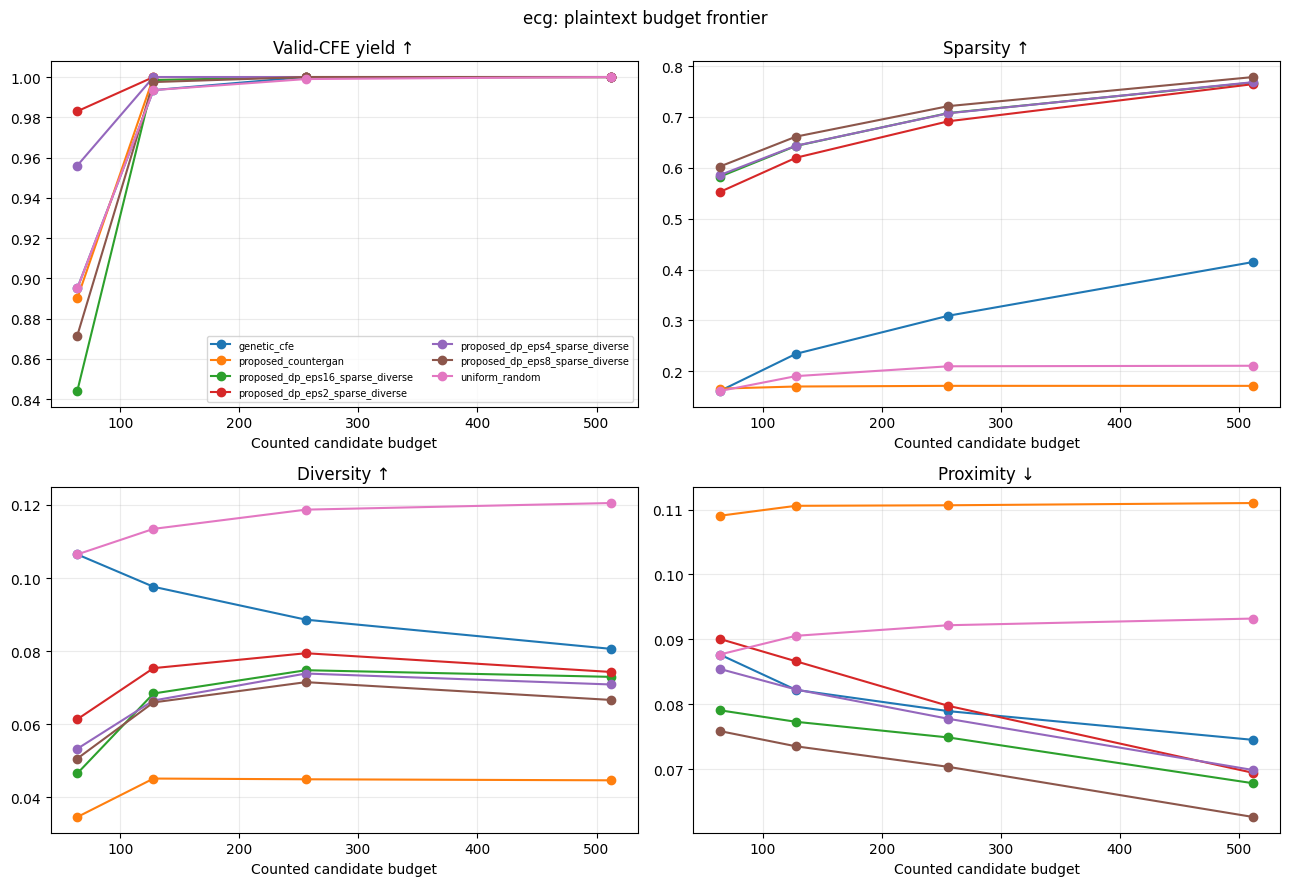

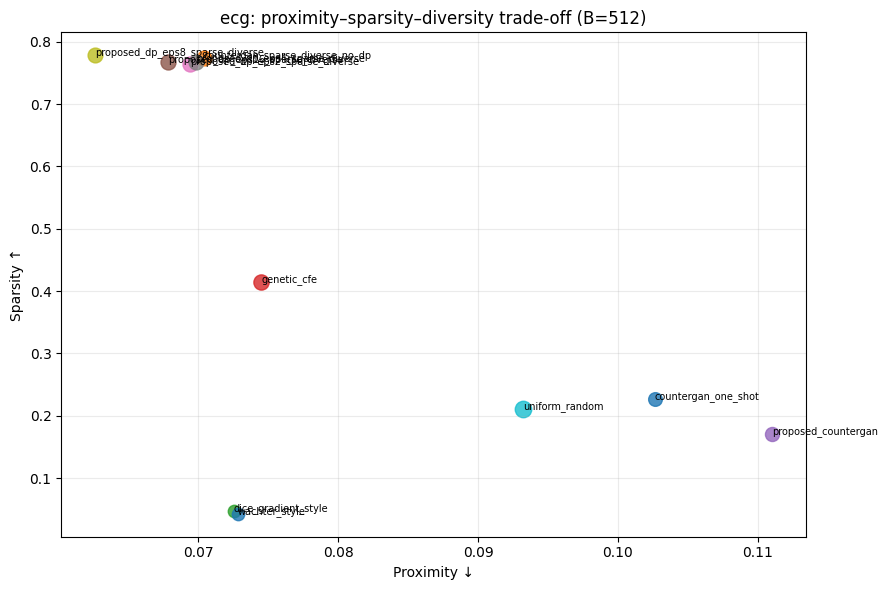

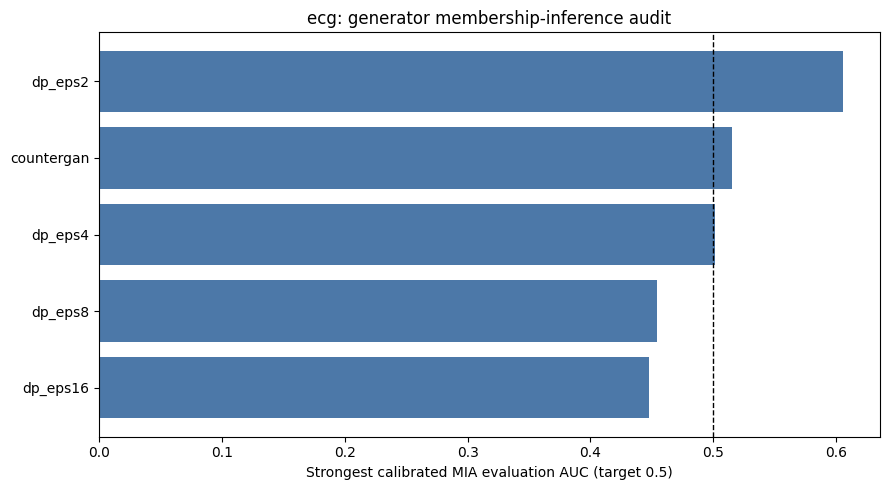

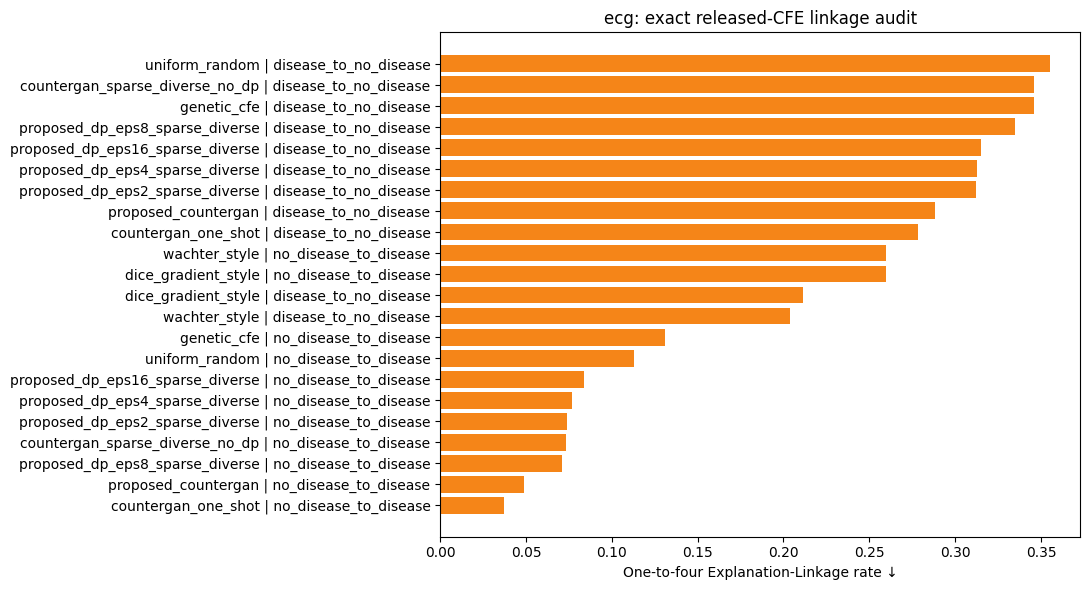

{'phase': 'plaintext_visualizations', 'wall_seconds': 2.4247079380002106}


In [19]:
_phase_started = time.perf_counter()
import matplotlib.pyplot as plt

FIGURE_DIR = OUTPUT / "plaintext_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

selected_frontier = frontier_macro[
    frontier_macro.method.isin([
        "uniform_random", "genetic_cfe", "proposed_countergan",
        "proposed_dp_eps16_sparse_diverse",
        "proposed_dp_eps8_sparse_diverse",
        "proposed_dp_eps4_sparse_diverse",
        "proposed_dp_eps2_sparse_diverse",
    ])
].copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for method, group in selected_frontier.groupby("method"):
    ordered = group.sort_values("candidate_budget")
    axes[0, 0].plot(ordered.candidate_budget, ordered.valid_cfe_yield_at_k,
                    marker="o", label=method)
    axes[0, 1].plot(ordered.candidate_budget, ordered.sparsity,
                    marker="o", label=method)
    axes[1, 0].plot(ordered.candidate_budget, ordered.diversity,
                    marker="o", label=method)
    axes[1, 1].plot(ordered.candidate_budget, ordered.proximity,
                    marker="o", label=method)
axes[0, 0].set_title("Valid-CFE yield ↑")
axes[0, 1].set_title("Sparsity ↑")
axes[1, 0].set_title("Diversity ↑")
axes[1, 1].set_title("Proximity ↓")
for ax in axes.flat:
    ax.set_xlabel("Counted candidate budget")
    ax.grid(alpha=.25)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle(f"{DATASET}: plaintext budget frontier")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_budget_frontier.png", dpi=180)
plt.show(); plt.close(fig)

selected_budget_rows = frontier_macro[
    frontier_macro.candidate_budget.eq(SD_BUDGET)
].copy()
pareto_plot_rows = selected_budget_rows[
    np.isfinite(pd.to_numeric(selected_budget_rows.proximity, errors="coerce"))
    & np.isfinite(pd.to_numeric(selected_budget_rows.sparsity, errors="coerce"))
    & np.isfinite(pd.to_numeric(selected_budget_rows.diversity, errors="coerce"))
].copy()
fig, ax = plt.subplots(figsize=(9, 6))
if len(pareto_plot_rows):
    for _, row in pareto_plot_rows.iterrows():
        ax.scatter(row.proximity, row.sparsity,
                   s=80 + 500 * max(float(row.diversity), 0), alpha=.8)
        ax.annotate(row.method, (row.proximity, row.sparsity), fontsize=7)
else:
    ax.text(.5, .5, "No finite quality rows at selected budget",
            ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Proximity ↓")
ax.set_ylabel("Sparsity ↑")
ax.set_title(f"{DATASET}: proximity–sparsity–diversity trade-off (B={SD_BUDGET})")
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_pareto_tradeoff.png", dpi=180)
plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 5))
plot_mia = strongest_mia_v2.sort_values("mean")
ax.barh(plot_mia.variant, plot_mia["mean"], color="#4C78A8")
ax.axvline(.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Strongest calibrated MIA evaluation AUC (target 0.5)")
ax.set_title(f"{DATASET}: generator membership-inference audit")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_mia_auc.png", dpi=180)
plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 6))
link_plot = linkage.copy()
link_plot = link_plot[
    np.isfinite(pd.to_numeric(link_plot.small_map_1_to_4_rate, errors="coerce"))
].copy()
link_plot["method_direction"] = (
    link_plot.method.astype(str) + " | " + link_plot.direction.astype(str)
)
link_plot = link_plot.sort_values("small_map_1_to_4_rate").tail(24)
if len(link_plot):
    ax.barh(link_plot.method_direction, link_plot.small_map_1_to_4_rate,
            color="#F58518")
else:
    ax.text(.5, .5, "No released CFEs for linkage estimation",
            ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("One-to-four Explanation-Linkage rate ↓")
ax.set_title(f"{DATASET}: exact released-CFE linkage audit")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_explanation_linkage.png", dpi=180)
plt.show(); plt.close(fig)
record_phase("plaintext_visualizations", _phase_started)


## 13. Paper acceptance gate and archive

In [20]:
_phase_started = time.perf_counter()
EXPECTED_METHODS = BASELINE_METHODS | LEARNED_METHODS
EXPECTED_DP_METHODS = {
    "proposed_dp_eps16_sparse_diverse",
    "proposed_dp_eps8_sparse_diverse",
    "proposed_dp_eps4_sparse_diverse",
    "proposed_dp_eps2_sparse_diverse",
}
expected_rows = (
    len(queries) * len(BUDGETS) * len(METHOD_SEARCH_SEEDS)
    * (len(BASELINE_METHODS)
       + len(LEARNED_METHODS) * len(GENERATOR_TRAINING_SEEDS))
)
learned = detail[detail.method.isin(LEARNED_METHODS)]
baselines = detail[detail.method.isin(BASELINE_METHODS)]
native_official = native[native.method.str.startswith("official_dice")]
checks = {
    "t4": "T4" in gpu_name,
    "training_handoff_verified": True,
    "expected_direction_filtered_factuals": (
        queries.query_id.nunique()
        == PER_DIRECTION * len(ACTIVE_DIRECTIONS)
    ),
    "requested_factuals_per_active_direction": (
        set(queries.direction) == ACTIVE_DIRECTIONS
        and queries.groupby("direction").size().eq(PER_DIRECTION).all()
    ),
    "three_difficulty_strata_per_active_direction": (
        queries.groupby("direction").difficulty_stratum.nunique().eq(3).all()
    ),
    "expected_raw_rows": len(detail) == expected_rows,
    "combined_raw_key_unique": not key_frame.duplicated().any(),
    "all_methods_present": set(detail.method) == EXPECTED_METHODS,
    "method_registry_matches_benchmark": (
        set(method_registry.method) == EXPECTED_METHODS
        and not method_registry.method.duplicated().any()
    ),
    "unified_epsilon_panel_present": EXPECTED_DP_METHODS.issubset(
        set(detail.method)
    ),
    "legacy_proposed_rows_absent": not set(detail.method).intersection({
        "proposed_dp_eps4", "proposed_dp_eps8",
        "proposed_dp_eps4_prune", "proposed_dp_eps4_snap",
    }),
    "unified_inner_epsilon_panel_complete": set(prune_inner_raw.method)
        == EXPECTED_DP_METHODS,
    "search_contract_selected_without_outer_test": not sd_contract[
        "outer_test_used_for_selection"
    ],
    "inner_budget_matches_frozen_operating_budget": (
        PRUNE_INNER_BUDGET == SD_BUDGET == 512
    ),
    "selected_profile_from_predeclared_grid": (
        SD_PROFILE in {row[0] for row in V5_PROFILE_GRID}
    ),
    "valid_inner_profile_selected": (
        PRUNE_BASE_FRACTION in BASE_FRACTION_CANDIDATES
        and selected_profile.valid_cfe_yield_at_k
            >= best_inner_yield - INNER_YIELD_TOLERANCE
        and selected_profile.worst_direction_yield
            >= best_inner_worst_direction - INNER_YIELD_TOLERANCE
    ),
    "sparse_diverse_contract_complete": (
        SD_MMR >= 0 and SD_PROXIMITY_WEIGHT > 0
        and SD_SPARSITY_WEIGHT > 0
    ),
    "matched_budget_population_round_sensitivity": (
        set(population_round_summary.population.astype(int)) == {256, 32, 64, 128, 512, 16}
        and population_round_summary.candidate_budget.eq(512).all()
    ),
    "valid_inner_population_selected": (
        int(population_round_summary.selected_for_outer.sum()) == 1
        and int(population_round_summary.loc[
            population_round_summary.selected_for_outer, "population"
        ].iloc[0]) == BASE_POPULATION
        and int(BASE_POPULATION) == 64
    ),
    "plaintext_manuscript_tables_present": (
        len(list(MANUSCRIPT_DIR.glob("*.csv"))) >= 18
    ),
    "class_balance_reconciles": (
        len(class_balance) == 3
        and class_balance.rows.gt(0).all()
        and class_balance["sum_check"].eq(class_balance.rows).all()
    ),
    "paired_comparison_table_nonempty": (
        len(paired) > 0
        and set(paired.reference_method)
        == {"proposed_dp_eps4_sparse_diverse"}
    ),
    "one_search_seed": set(detail.method_seed.astype(int)) == {11},
    "one_generator_training_seed": set(
        learned.generator_training_seed.dropna().astype(int)
    ) == set(GENERATOR_TRAINING_SEEDS),
    "baseline_has_no_generator_seed": (
        baselines.generator_training_seed.isna().all()
    ),
    "candidate_cap_never_exceeded": (
        detail.candidate_evaluations.le(detail.candidate_budget).all()
    ),
    "missing_slots_are_failures": np.allclose(
        detail.valid_cfe_yield_at_k,
        detail.reference_valid_returned / K_PRIMARY,
    ),
    "failure_accounting_exported_without_case_deletion": (
        len(failure_accounting) > 0
        and detail.query_id.nunique() == queries.query_id.nunique()
    ),
    "frontier_saturation_explicitly_reported": (
        "full_k_success" in macro.columns
        and macro.full_k_success.between(0, 1).all()
    ),
    "official_native_rows_complete": (
        len(native) == len(native_queries) * len(METHOD_SEARCH_SEEDS) * 3
    ),
    "official_dice_no_implementation_errors": not (
        native_official.algorithm_status.eq("implementation_error").any()
    ),
    "release_set_nonempty": len(release_cfes) > 0,
    "linkage_all_method_direction_pairs_explicit": (
        len(linkage) == len(BASELINE_METHODS | LEARNED_METHODS) * len(ACTIVE_DIRECTIONS)
        and set(zip(linkage.method, linkage.direction)) == {
            (method, direction)
            for method in (BASELINE_METHODS | LEARNED_METHODS)
            for direction in ACTIVE_DIRECTIONS
        }
        and linkage.loc[linkage.released_cfes.eq(0), "release_available"].eq(False).all()
    ),
    "representative_qualitative_grid_complete": (
        TARGET_DIRECTIONS != "both" or len(qualitative_grid) == 10
    ),
    "secure_rng_all_dp_checkpoints": (
        privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(), "secure_rng"
        ].eq(True).all()
        and privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "secure_rng_backend"
        ].eq("torchcsprng:/dev/urandom").all()
    ),
    "step_aware_privacy_budget_calibration": (
        privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "privacy_calibration_mode"
        ].eq("exact_planned_optimizer_steps").all()
        and privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "actual_generator_optimizer_steps"
        ].eq(privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "planned_optimizer_steps_generator"
        ]).all()
        and (privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "achieved_epsilon_composed"
        ] <= privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "requested_epsilon"
        ] + .01).all()
        and (privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "achieved_epsilon_composed"
        ] >= .95 * privacy_accounting.loc[
            privacy_accounting.requested_epsilon.notna(),
            "requested_epsilon"
        ]).all()
    ),
    "generator_only_search_contract": (
        detail.search_plausibility_source.eq("none_generator_only").all()
        and not sd_contract["discriminator_released_or_queried_at_inference"]
    ),
    "common_base_seed_and_paired_robustness_contract": (
        {"run_seed", "robustness_seed"}.issubset(detail.columns)
        and detail.groupby(
            ["query_id", "method_seed", "candidate_budget"]
        ).run_seed.nunique().eq(1).all()
        and detail.groupby(
            ["query_id", "method_seed", "candidate_budget"]
        ).robustness_seed.nunique().eq(1).all()
    ),
    "fixed_cap_methods_consume_full_budget": (
        detail.loc[
            detail.method.isin({
                "uniform_random", "genetic_cfe",
                "countergan_sparse_diverse_no_dp",
                "proposed_dp_eps16_sparse_diverse",
                "proposed_dp_eps8_sparse_diverse",
                "proposed_dp_eps4_sparse_diverse",
                "proposed_dp_eps2_sparse_diverse",
            }), "candidate_evaluations"
        ].eq(detail.loc[
            detail.method.isin({
                "uniform_random", "genetic_cfe",
                "countergan_sparse_diverse_no_dp",
                "proposed_dp_eps16_sparse_diverse",
                "proposed_dp_eps8_sparse_diverse",
                "proposed_dp_eps4_sparse_diverse",
                "proposed_dp_eps2_sparse_diverse",
            }), "candidate_budget"
        ]).all()
    ),
    "privacy_all_five_generators": (
        len(privacy_attacks) == 5
        and set(privacy_attacks.variant) == set(all_generators)
    ),
    "mia_v2_contract_complete": (
        len(mia_v2_raw) == 250
        and mia_v2_raw.variant.nunique() == 5
        and mia_v2_raw.attack.nunique() == 5
        and mia_v2_raw.attack_seed.nunique() == 10
        and security_v2_report["paper_numbers"] is True
        and not security_v2_report["evaluation_labels_used_for_attack_selection"]
        and security_v2_report["deployment_release"] == "generator_only"
        and not security_v2_report[
            "released_discriminator_primary_attack_surface"
        ]
        and security_v2_report[
            "discriminator_release_ablation_included"
        ]
    ),
}
checks["query_group_id_present"] = "query_group_id" in queries.columns
checks["group_clustered_ci_present"] = (
    TABLE_DIR / "query_group_clustered_bootstrap_ci.csv"
).is_file()
if DATASET == "mimic":
    # The supplied derived MIMIC table contains no patient identifier, so a
    # patient-disjoint audit cannot honestly be manufactured.  Accept only
    # when that limitation is explicit and the declared row-stratified split
    # is reproduced in both the prepared data and manuscript accounting.
    checks["no_patient_id_split_limitation_documented"] = (
        prepared.raw.groups is None
        and prepared.raw.split_kind == "stratified-row-no-patient-id"
        and set(dataset_accounting.split_kind)
        == {"stratified-row-no-patient-id"}
        and not (OUTPUT / "split_group_disjoint_audit.csv").is_file()
    )
else:
    checks["split_group_disjoint_audit_present"] = (
        OUTPUT / "split_group_disjoint_audit.csv"
    ).is_file()
if DATASET == "heartplus":
    checks["one_factual_per_exact_feature_group"] = (
        queries.query_group_id.nunique() == len(queries)
    )
elif DATASET == "ecg":
    checks["multiple_held_out_subjects_per_direction"] = queries.groupby(
        "direction"
    ).query_group_id.nunique().ge(2).all()

acceptance = {
    "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER",
    "stage": RUN_MODE, "dataset": DATASET,
    "gpu": gpu_name, "accepted": bool(all(checks.values())),
    "checks": checks, "paper_numbers": True,
    "K": K_PRIMARY, "budgets": BUDGETS,
    "queries_per_direction": PER_DIRECTION,
    "target_directions": TARGET_DIRECTIONS,
    "method_search_seeds": METHOD_SEARCH_SEEDS,
    "generator_training_seeds": GENERATOR_TRAINING_SEEDS,
    "raw_rows": len(detail), "native_rows": len(native),
    "metric_semantics": {
        "primary": "valid_and_feasible_returned / K; missing slots fail",
        "conditional_returned_validity": "archive integrity only",
    },
}
(OUTPUT / "v55_paper_acceptance.json").write_text(
    json.dumps(acceptance, indent=2, default=str)
)
record_phase("acceptance_pre_archive", _phase_started)
pd.DataFrame(PHASE_TIMINGS + [{
    "phase": "notebook_total_before_archive",
    "wall_seconds": float(time.perf_counter() - NOTEBOOK_STARTED),
}]).to_csv(OUTPUT / "phase_wall_times.csv", index=False)
archive = shutil.make_archive(
    "/kaggle/working/ecg_q1v55_generator_only_paper_artifacts",
    "zip", root_dir=OUTPUT,
)
print(json.dumps(acceptance, indent=2, default=str))
print("Archive:", archive)
if not acceptance["accepted"]:
    failed_checks = [name for name, passed in checks.items() if not bool(passed)]
    raise RuntimeError(
        f"{DATASET} Q1-V5.5 plaintext smoke gate failed: {failed_checks}"
    )

{'phase': 'acceptance_pre_archive', 'wall_seconds': 0.027252710999164265}
{
  "protocol": "Q1_V55_GENERATOR_ONLY_ONE_SEED_PAPER",
  "stage": "paper",
  "dataset": "ecg",
  "gpu": "Tesla T4",
  "accepted": true,
  "checks": {
    "t4": true,
    "training_handoff_verified": true,
    "expected_direction_filtered_factuals": true,
    "requested_factuals_per_active_direction": "True",
    "three_difficulty_strata_per_active_direction": "True",
    "expected_raw_rows": true,
    "combined_raw_key_unique": true,
    "all_methods_present": true,
    "method_registry_matches_benchmark": true,
    "unified_epsilon_panel_present": true,
    "legacy_proposed_rows_absent": true,
    "unified_inner_epsilon_panel_complete": true,
    "search_contract_selected_without_outer_test": true,
    "inner_budget_matches_frozen_operating_budget": true,
    "selected_profile_from_predeclared_grid": true,
    "valid_inner_profile_selected": "True",
    "sparse_diverse_contract_complete": true,
    "matched_bud